<span style="color:steelblue; text-align: left">

# Customer Segmentation and Next Best Action
</span>

**Data Scientist**: Enio Rubens

A portfolio project using the **Online Retail II** dataset [Chen, 2012]. The analysis transforms transactional data into customer segments using RFM and K-Means, common practices in data mining applied to retail and CRM [Chen, Sain and Guo, 2012; Jain, 2010], and adds a predictive and prescriptive layer of **Next Best Action** driven by repurchase probability, incentive simulation and expected profit, aligned with the prescriptive analytics framework [Bertsimas and Kallus, 2019].

<span style="color:steelblue; text-align: left">

## Introduction
</span>

Not all customers hold the same value for the business. Some buy frequently, others concentrate high value in few purchases, and part of the customer base goes long periods without buying. This heterogeneity is one of the foundations of market segmentation and analytical CRM [Wedel and Kamakura, 2000; Rust and Verhoef, 2005].

Segmentation helps identify groups with similar patterns and enables transforming transactional data into marketing, retention and CRM actions [Wedel and Kamakura, 2000]. This project uses RFM, a behavioral representation widely used to relate purchase history, customer value and relationship decisions [Fader, Hardie and Lee, 2005; Chen, Sain and Guo, 2012]:

- **Recency:** time since last purchase.
- **Frequency:** purchase frequency.
- **Monetary:** amount spent by the customer.

<span style="color:steelblue; text-align: left">

## Business Objective
</span>

The objective is to create an actionable view of the customer base: identify high-value groups, loyal customers, occasional buyers, at-risk customers and low-priority profiles. The final output should support investment prioritization, campaigns and customer relationship management, connecting descriptive analysis to operational decisions, as advocated in personalized CRM and prescriptive analytics approaches [Rust and Verhoef, 2005; Bertsimas and Kallus, 2019].


In [38]:
from io import StringIO
from pathlib import Path
from typing import Any
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns
#from matplotlib.ticker import MaxNLocator, NullFormatter, FuncFormatters

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "axes.edgecolor": "#CBD2D9",
    "axes.labelcolor": "#323F4B",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "font.size": 11,
    "grid.color": "#E4E7EB",
    "grid.linewidth": 0.8,
})

%config InlineBackend.figure_format = 'retina'

def set_corporate_theme():
    """
    Corporate plotting theme inspired by editorial / financial charts,
    preserving strong readability.
    """
    sns.set_theme(style="ticks")

    plt.rcParams['figure.dpi'] = 96
    plt.rcParams['figure.figsize'] = (13.33, 6.5)

    # Titles
    plt.rcParams['figure.titlesize'] = 22
    plt.rcParams['figure.titleweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlepad'] = 20

    # Axis labels
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.labelweight'] = 'bold'

    # Axes / grid
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.grid'] = True
    plt.rcParams['axes.grid.axis'] = 'y'
    plt.rcParams['grid.alpha'] = 0.45
    plt.rcParams['grid.linewidth'] = 1.0
    plt.rcParams['ytick.left'] = False

    # Legend
    plt.rcParams['legend.title_fontsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.frameon'] = True
    plt.rcParams['legend.framealpha'] = 1
    plt.rcParams['legend.fancybox'] = True
    plt.rcParams['legend.facecolor'] = 'white'
    plt.rcParams['legend.edgecolor'] = 'gray'
    plt.rcParams['legend.borderpad'] = 0.6

    # Lines / markers
    plt.rcParams['lines.linewidth'] = 3
    plt.rcParams['lines.markersize'] = 10

    # Pandas display
    pd.set_option('display.max_rows', 3000)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 2000)
    pd.options.display.max_colwidth = 1000
    
    
set_corporate_theme()
    
# ── Configuration parameters ──────────────────────────────────────────────
# Edit only this cell to re-run the notebook with different scenarios.
DATA_PATH = Path("./dataset/online_retail_II.csv")
RANDOM_STATE = 42
__author__ = "Enio Rubens"

# FIX P4: operational parameters centralized to facilitate re-execution.
PREDICTION_HORIZON_DAYS = 90   # target window for future repurchase
HOLDOUT_FRACTION = 0.15        # fraction reserved as independent hold-out
N_CLUSTERS = 6                 # number of RFM segments

BUDGET_TOTAL = 10_000.00       # total available budget for incentives ($)

# ── Advanced increments ────────────────────────────────────────────────────
MARGIN_RATE    = 0.35    # I1: estimated gross margin over revenue
UNIFORM_UPLIFT = 0.07    # I2: uplift for the uniform campaign scenario (Scenario B)
UNIFORM_COST   = 5.00    # I2: cost of uniform incentive ($)
NOISE_LEVELS   = [-0.15, -0.10, -0.05, 0.00, +0.05, +0.10, +0.15]  # I3: perturbations
BUDGET_CURVE_POINTS = 50 # I5: granularity of the budget curve sweep
EXPORT_PATH = Path("./crm_next_best_action.csv")  # CRM export path


def fmt(value: Any, decimals: int = 0) -> str:
    """Formats numbers in Brazilian standard for tables and labels."""
    if pd.isna(value):
        return ""
    text = f"{value:,.{decimals}f}"
    return text.replace(",", "X").replace(".", ",").replace("X", ".")


def compact(value: float) -> str:
    """Compacts large numbers for chart labels."""
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{fmt(value / 1_000_000, 1)} mi"
    if abs(value) >= 1_000:
        return f"{fmt(value / 1_000, 1)} mil"
    return fmt(value, 0 if abs(value) >= 10 else 1)


<span style="color:steelblue; text-align: left">

## Configuration
</span>

All operational parameters are centralized in the cell above.
To re-run the notebook with a different scenario — new period, different
budget or number of segments — edit only that cell and run
`Kernel → Restart & Run All`.


<span style="color:steelblue; text-align: left">

## Data Loading
</span>

The dataset is loaded with `pandas` from the **Online Retail II** dataset, made available by the UCI Machine Learning Repository [Chen, 2012]. The initial inspection displays a sample, structure, descriptive statistics, dimensions and percentage of missing values, a step consistent with best practices for data preparation and initial diagnostics [Kuhn and Johnson, 2013].


In [39]:
raw_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {fmt(raw_df.shape[0])} rows and {fmt(raw_df.shape[1])} columns")
display(raw_df.head())


Dimensions: 1.067.371 rows and 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


<span style="color:steelblue; text-align: left">

## Initial Data Understanding
</span>

This step checks data types, numeric and categorical variables, as well as quality issues such as missing values in `Customer ID` and `Description`. This diagnosis is important because modeling and cleaning decisions depend on the semantics of the variables, the presence of missing values and the consistency of the records [Kuhn and Johnson, 2013].


In [40]:
buffer = StringIO()
raw_df.info(buf=buffer)
display(Markdown("```text\n" + buffer.getvalue() + "\n```"))

display(raw_df.describe(include="all").T)

missing = raw_df.isna().mean().mul(100).sort_values(ascending=False).reset_index().round(2)
missing.columns = ["Column", "Missing percentage"]
display(missing)


```text
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

```

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.00,NaN,NaN,NaN,9.94,172.71,-80995.00,1.00,3.00,10.00,80995.00
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.00,NaN,NaN,NaN,4.65,123.55,-53594.36,1.25,2.10,4.15,38970.00
Customer ID,824364.00,NaN,NaN,NaN,15324.64,1697.46,12346.00,13975.00,15255.00,16797.00,18287.00
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Column,Missing percentage
0,Customer ID,22.77
1,Description,0.41
2,StockCode,0.00
3,Invoice,0.00
4,Quantity,0.00
5,InvoiceDate,0.00
6,Price,0.00
7,Country,0.00


<span style="color:steelblue; text-align: left">

## Data Cleaning and Treatment

</span>

The cleaning removes records that do not represent valid purchases for segmentation, preserving the coherence between the unit of analysis, the customer, and the observed purchase behavior [Kuhn and Johnson, 2013; Chen, Sain and Guo, 2012]:

- Rows without `Customer ID`, as they cannot be attributed to a customer.
- Invalid dates after conversion of `InvoiceDate`.
- Cancellations with `Invoice` starting with `C`, as per the dataset documentation [Chen, 2012].
- Quantities and prices less than or equal to zero, associated with returns, adjustments or transactions without revenue.
- Null descriptions, to maintain consistency in product analyses.

The column `Revenue = Quantity * Price` is also created, and `Customer ID` is converted to text without a decimal. This engineering keeps the focus on observable behavioral measures, consistent with customer segmentation models based on transactions [Fader, Hardie and Lee, 2005].


In [41]:
clean_df = raw_df.copy()
steps = []


def log_step(name, before, after):
    steps.append({
        "Step": name,
        "Before": before,
        "After": after,
        "Removed": before - after,
        "% removed": round((before - after) / before * 100, 2) if before else 0,
    })


before = len(clean_df)
clean_df = clean_df.dropna(subset=["Customer ID"]).copy()
log_step("Remove missing Customer ID", before, len(clean_df))

before = len(clean_df)
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"], errors="coerce")
clean_df = clean_df.dropna(subset=["InvoiceDate"]).copy()
log_step("Convert InvoiceDate", before, len(clean_df))

before = len(clean_df)
mask = ~clean_df["Invoice"].astype(str).str.startswith("C", na=False)
clean_df = clean_df.loc[mask].copy()
log_step("Remove cancellations", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.loc[clean_df["Quantity"] > 0].copy()
log_step("Remove Quantity <= 0", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.loc[clean_df["Price"] > 0].copy()
log_step("Remove Price <= 0", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.dropna(subset=["Description"]).copy()
log_step("Remove missing Description", before, len(clean_df))

clean_df["Customer ID"] = clean_df["Customer ID"].astype("Int64").astype(str)
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["Price"]
clean_df = clean_df.reset_index(drop=True)

display(pd.DataFrame(steps))
print(f"Clean dataset: {fmt(clean_df.shape[0])} rows and {fmt(clean_df.shape[1])} columns")
print(f"Unique customers: {fmt(clean_df['Customer ID'].nunique())}")
print(f"Total revenue: {fmt(clean_df['Revenue'].sum(), 2)}")
display(clean_df.head())


,Step,Before,After,Removed,% removed
0,Remove missing Customer ID,1067371,824364,243007,22.77
1,Convert InvoiceDate,824364,824364,0,0.00
2,Remove cancellations,824364,805620,18744,2.27
3,Remove Quantity <= 0,805620,805620,0,0.00
4,Remove Price <= 0,805620,805549,71,0.01
5,Remove missing Description,805549,805549,0,0.00


Clean dataset: 805.549 rows and 9 columns
Unique customers: 5.878
Total revenue: 17.743.429,18


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


<span style="color:steelblue; text-align: left">

## RFM Feature Engineering

</span>

The reference date is the last date in the dataset plus one day. The final table has one row per customer with `Recency`, `Frequency`, `Monetary`, `AverageTicket`, `QuantityTotal`, `UniqueProducts` and `CountryMode`. The RFM triad summarizes recency, intensity and purchase value, classic dimensions for customer base analysis and CLV [Fader, Hardie and Lee, 2005; Chen, Sain and Guo, 2012].


In [42]:
def mode_or_unknown(series: pd.Series) -> str:
    """Returns the mode of a series or 'Unknown' when no value is present."""
    mode = series.dropna().mode()
    return str(mode.iloc[0]) if not mode.empty else "Unknown"


snapshot_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference date: {snapshot_date:%Y-%m-%d}")

rfm = clean_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

# FIX: AverageTicket protected against division by zero.
rfm["AverageTicket"] = np.where(
    rfm["Frequency"] > 0,
    rfm["Monetary"] / rfm["Frequency"],
    0.0,
)
rfm = rfm[[
    "Customer ID", "Recency", "Frequency", "Monetary", "AverageTicket",
    "QuantityTotal", "UniqueProducts", "CountryMode",
]]

print(f"RFM table: {fmt(rfm.shape[0])} customers")
display(rfm.head())
display(rfm.describe().T)


Reference date: 2011-12-10
RFM table: 5.878 customers


,Customer ID,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts,CountryMode
0,12346,326,12,77556.46,6463.04,74285,27,United Kingdom
1,12347,2,8,5633.32,704.16,3286,126,Iceland
2,12348,75,5,2019.40,403.88,2714,25,Finland
3,12349,19,4,4428.69,1107.17,1624,138,Italy
4,12350,310,1,334.40,334.40,197,17,Norway


,count,mean,std,min,25%,50%,75%,max
Recency,5878.00,201.33,209.34,1.00,26.00,96.00,380.00,739.00
Frequency,5878.00,6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,5878.00,3018.62,14737.73,2.95,348.76,898.91,2307.09,608821.65
AverageTicket,5878.00,391.73,1215.07,2.95,181.65,285.07,420.57,84236.25
QuantityTotal,5878.00,1821.40,8963.01,1.00,190.00,491.50,1376.00,367193.00
UniqueProducts,5878.00,81.99,116.48,1.00,19.00,45.00,103.00,2550.00


<span style="color:steelblue; text-align: left">

## RFM Exploratory Analysis
</span>

RFM variables tend to be skewed. The exploratory analysis uses statistics and charts to reveal distribution, concentration and possible extreme values before modeling, following the EDA tradition proposed by Tukey [Tukey, 1977]. For visual readability, some histograms use a limit at the 99th percentile only in the chart, without changing the data used in clustering.


In [43]:
PALETTE = [
    "#005F73",
    "#0A9396",
    "#94D2BD",
    "#EE9B00",
    "#CA6702",
    "#9B2226",
]


def add_titles(ax, title, subtitle=None):
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=22)
    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="#52606D",
        )


def set_compact_axis(ax, axis="x"):
    formatter = mticker.FuncFormatter(lambda value, _: compact(value))
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


def hist(series, title, subtitle, xlabel, color, bins=30, q=None):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if q is not None:
        values = values.clip(upper=values.quantile(q))

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.hist(values, bins=bins, color=color, alpha=0.88, edgecolor="white")
    add_titles(ax, title, subtitle)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Customers")
    ax.grid(axis="y", alpha=0.8)
    set_compact_axis(ax, "x")
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def barh(df, label, value, title, subtitle, color="#005F73", color_col=None, cmap=None):
    data = df.reset_index(drop=True)
    colors = color
    if color_col and cmap:
        colors = data[color_col].map(cmap).fillna(color)

    fig_height = max(4.2, 0.42 * len(data) + 1.4)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))
    ax.barh(data[label].astype(str), data[value], color=colors, alpha=0.9)
    add_titles(ax, title, subtitle)
    ax.set_xlabel(value)
    ax.grid(axis="x", alpha=0.8)
    set_compact_axis(ax, "x")

    for idx, val in enumerate(data[value]):
        ax.text(val, idx, f" {compact(val)}", va="center", fontsize=10, color="#323F4B")

    plt.tight_layout()
    plt.show()


def lineplot(df, x, y, title, subtitle, color, zero=False):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(df[x], df[y], marker="o", linewidth=2.4, color=color)
    add_titles(ax, title, subtitle)
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel(y)
    if zero:
        ax.set_ylim(bottom=0)
    ax.grid(alpha=0.8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def scatter(df, x, y, title, subtitle, cmap, logx=False, logy=False):
    fig, ax = plt.subplots(figsize=(10.8, 5.6))

    for cluster in sorted(df["Cluster"].unique()):
        group = df.loc[df["Cluster"] == cluster]
        segment = group["SegmentName"].iloc[0]
        ax.scatter(
            group[x],
            group[y],
            s=22,
            alpha=0.55,
            color=cmap[cluster],
            label=f"C{cluster} - {segment}",
        )

    add_titles(ax, title, subtitle)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.grid(alpha=0.7)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    set_compact_axis(ax, "x")
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def boxplot(df, group, value, title, subtitle, cmap):
    groups = sorted(df[group].unique())
    values = [df.loc[df[group] == cluster, value] for cluster in groups]

    fig, ax = plt.subplots(figsize=(9.8, 5.0))
    boxplot_kwargs = {
        "patch_artist": True,
        "showfliers": False,
    }
    try:
        box = ax.boxplot(
            values,
            tick_labels=[f"C{cluster}" for cluster in groups],
            **boxplot_kwargs,
        )
    except TypeError:
        box = ax.boxplot(
            values,
            labels=[f"C{cluster}" for cluster in groups],
            **boxplot_kwargs,
        )

    for patch, cluster in zip(box["boxes"], groups):
        patch.set_facecolor(cmap[cluster])
        patch.set_alpha(0.72)
        patch.set_edgecolor(cmap[cluster])

    for median in box["medians"]:
        median.set_color("white")
        median.set_linewidth(2)

    add_titles(ax, title, subtitle)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(value)
    ax.grid(axis="y", alpha=0.8)
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


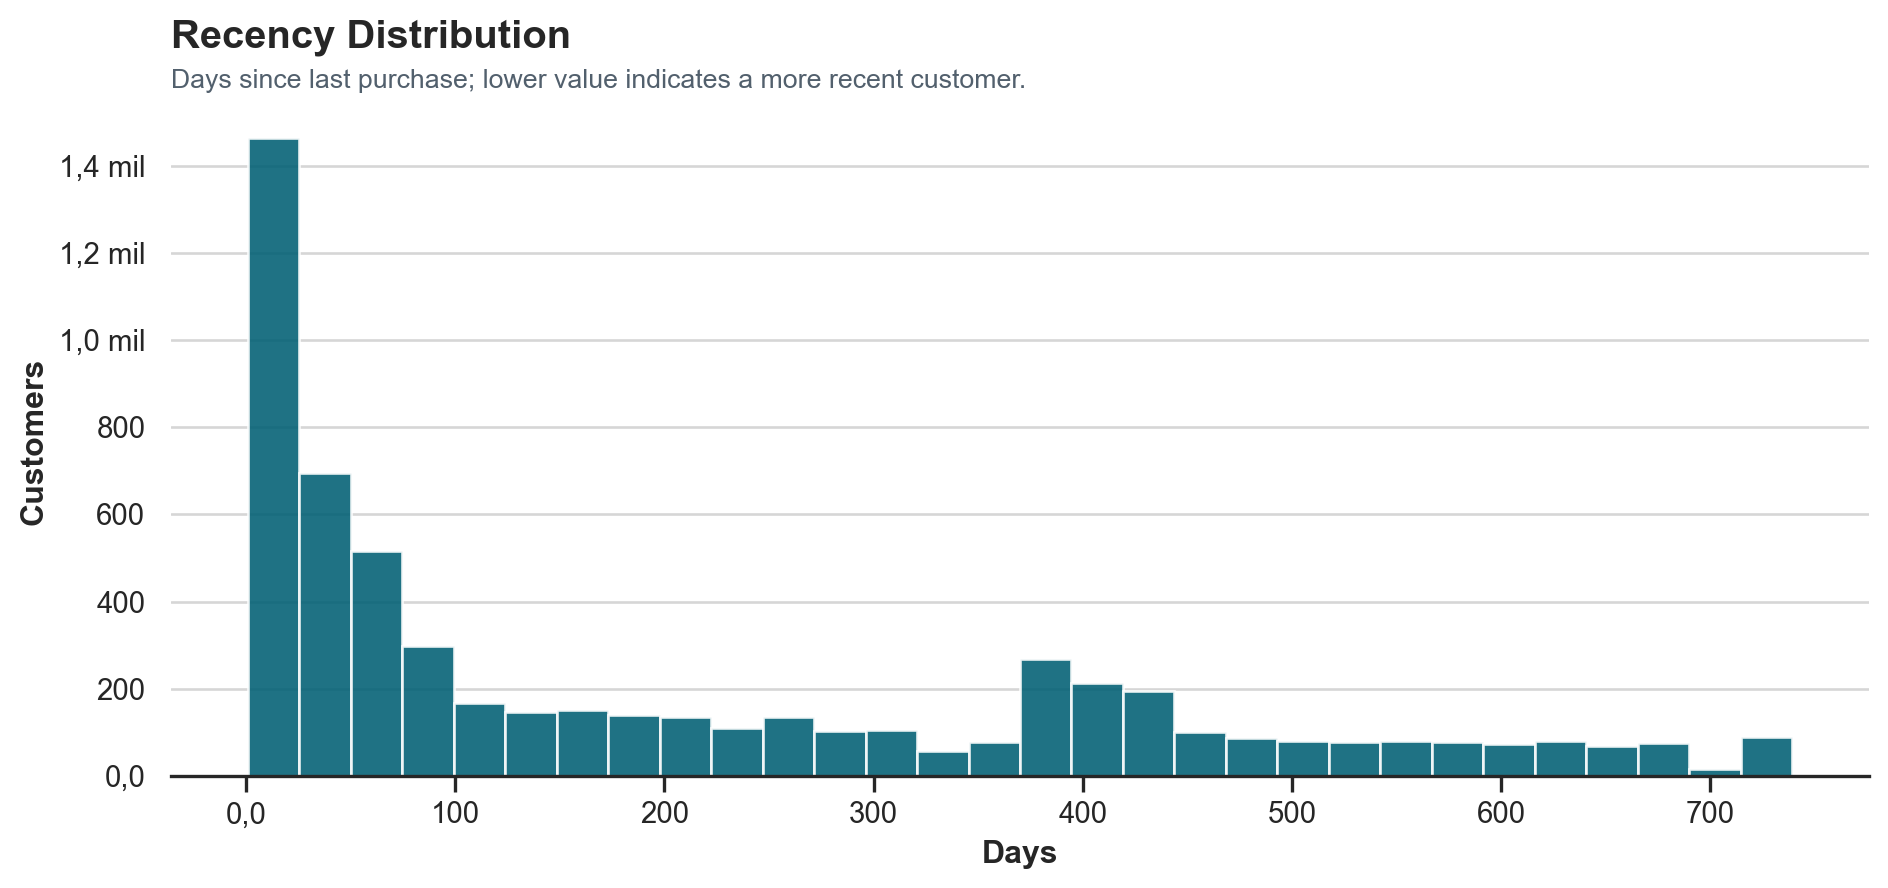

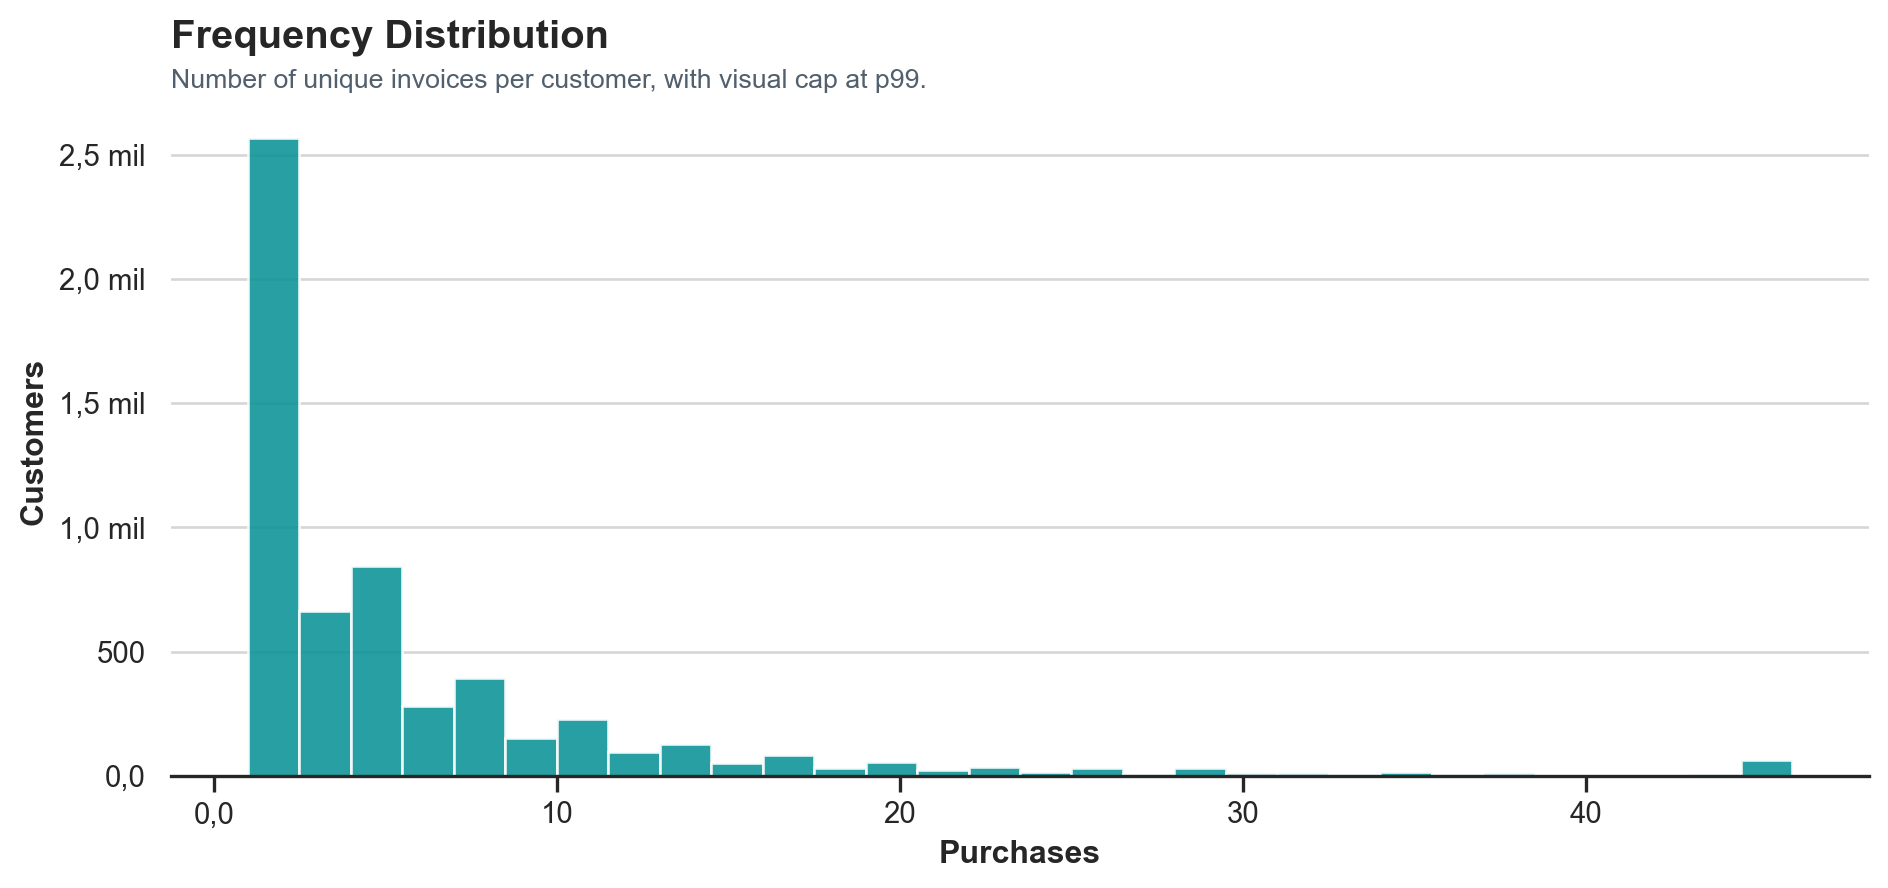

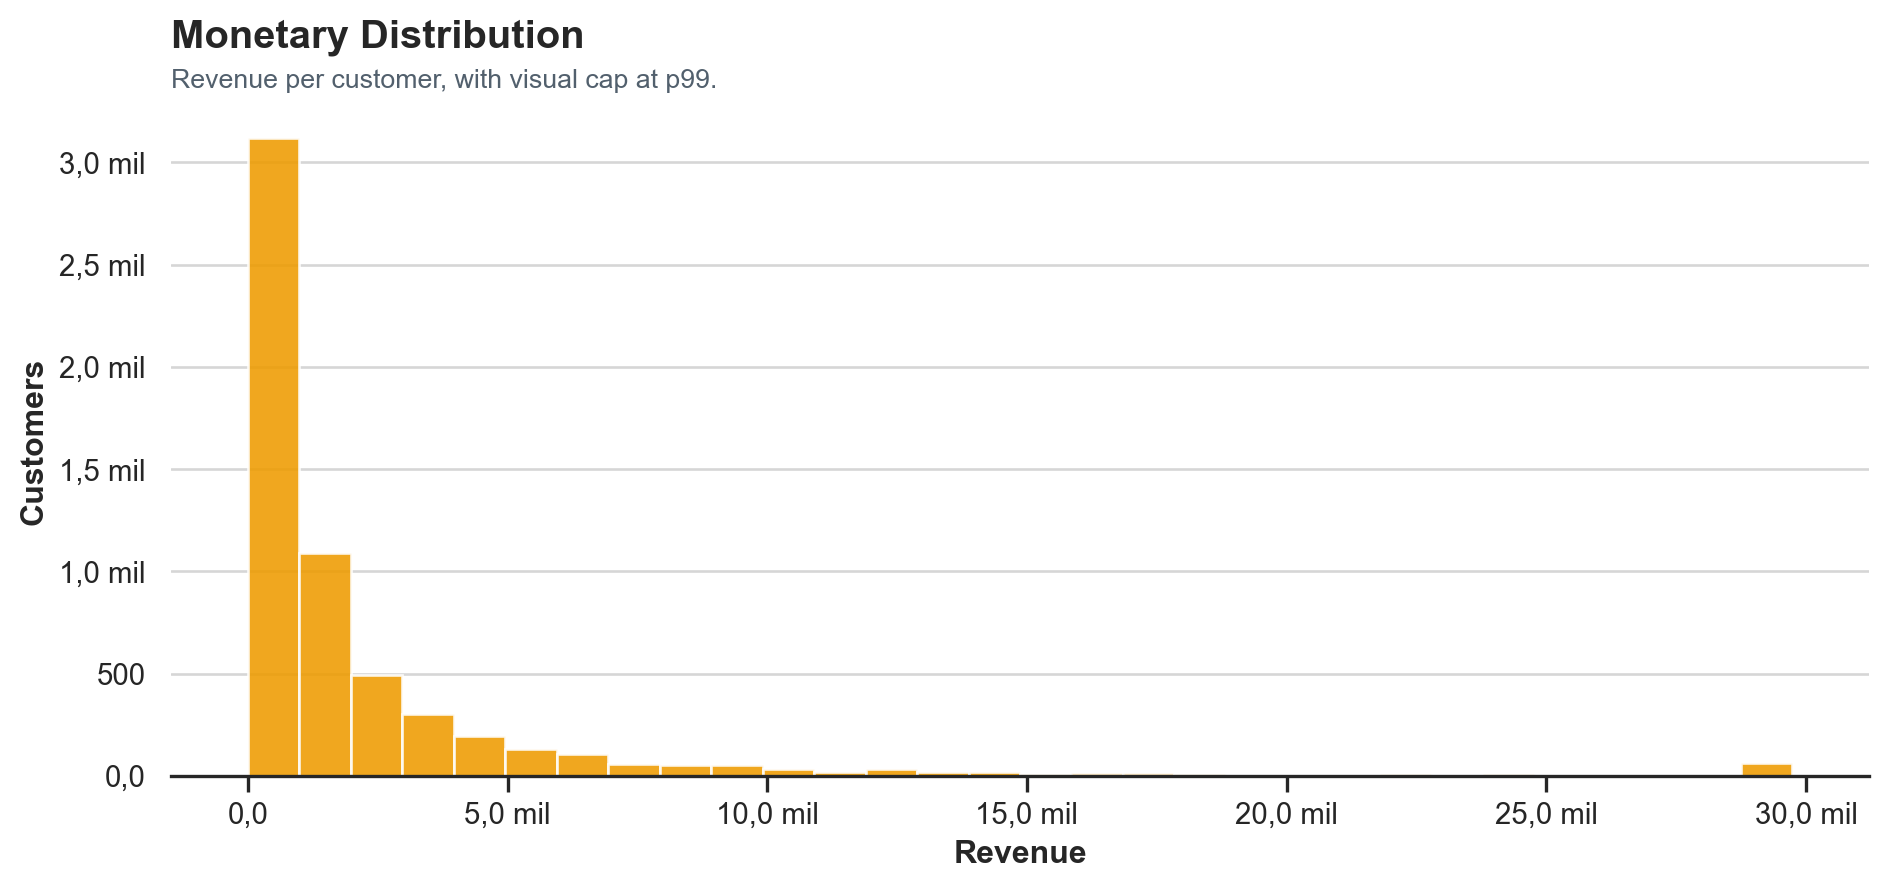

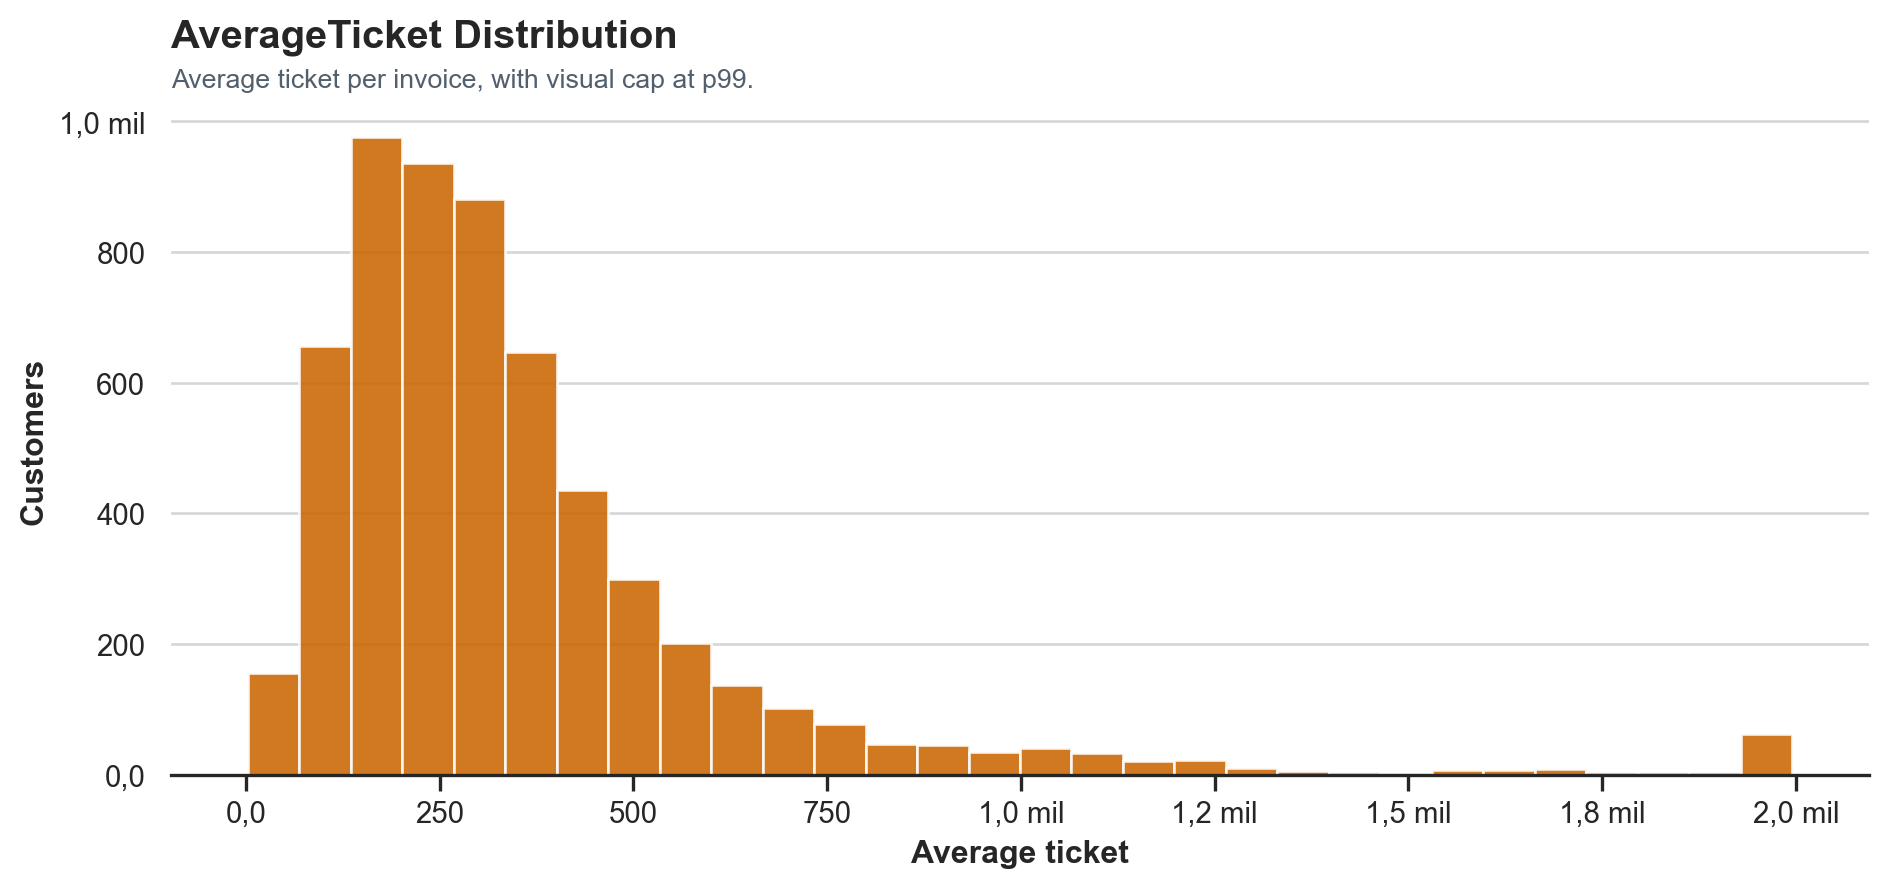

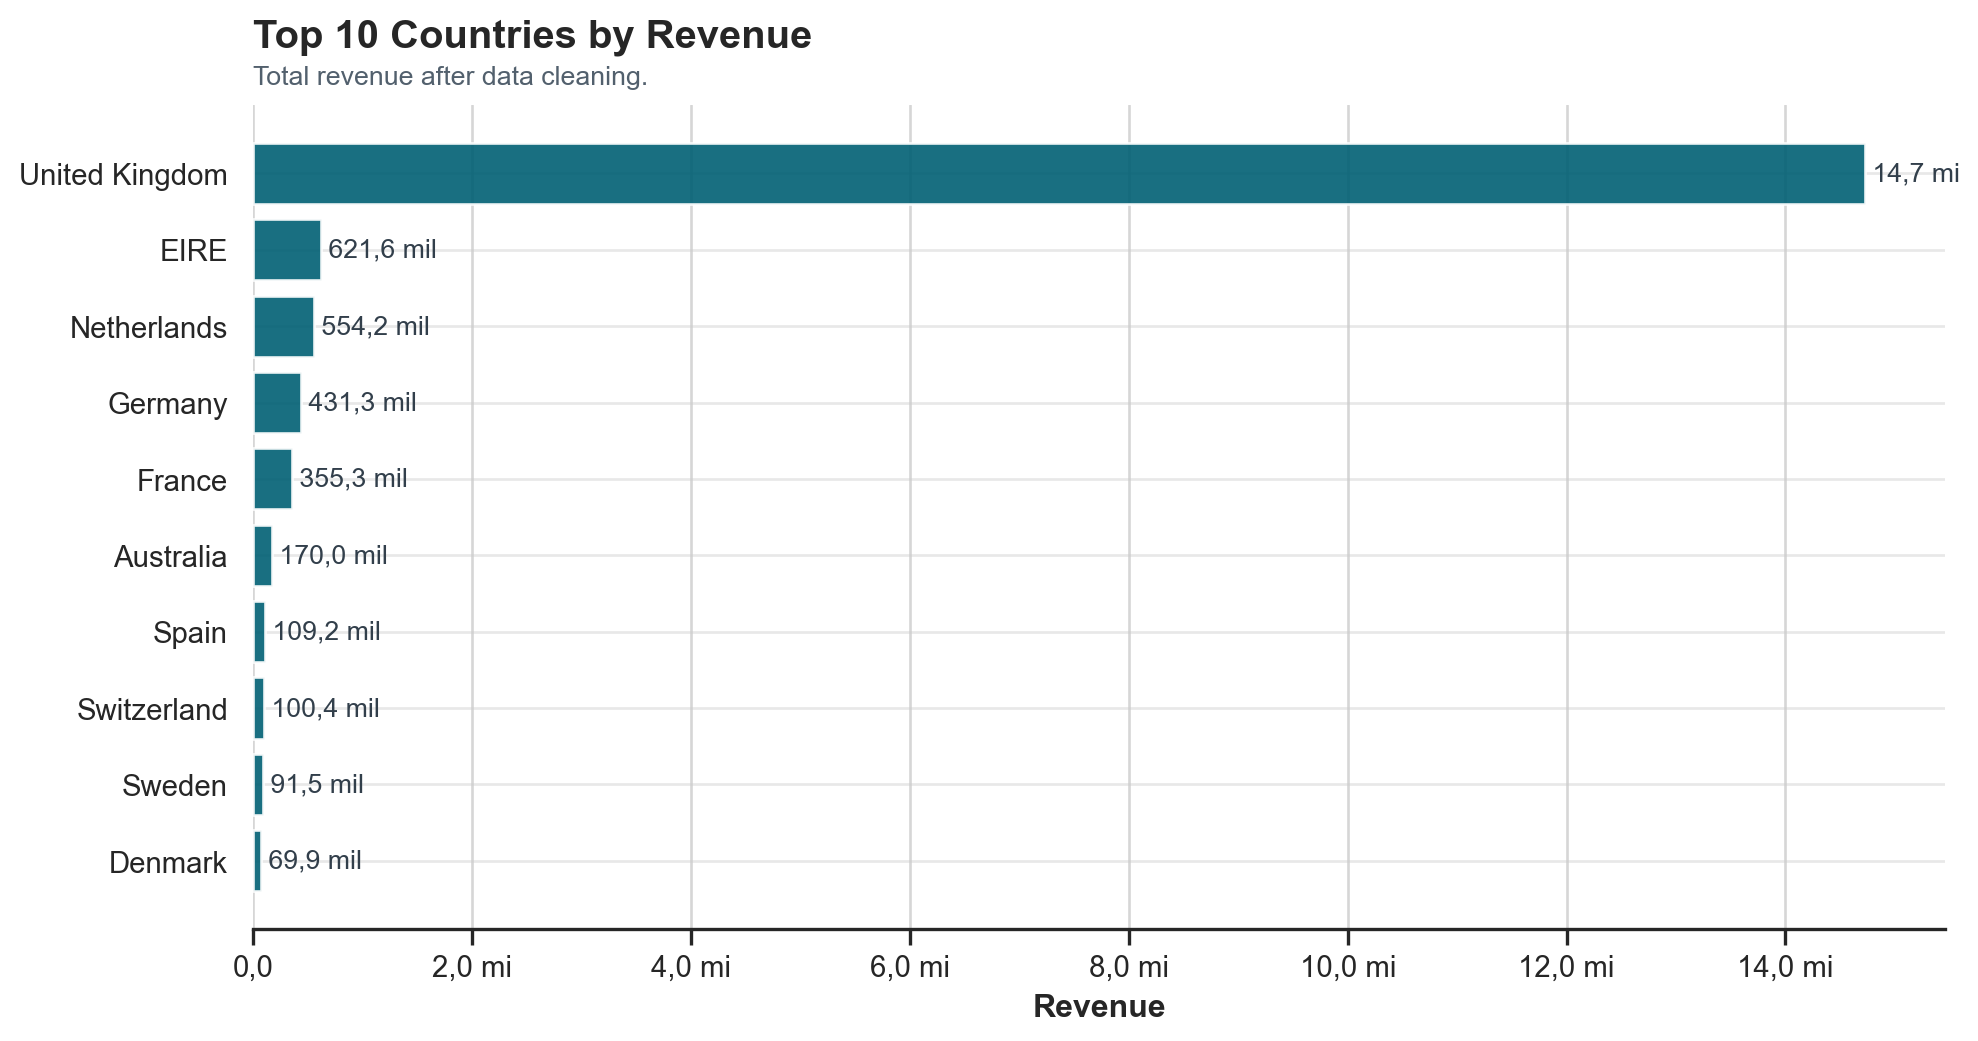

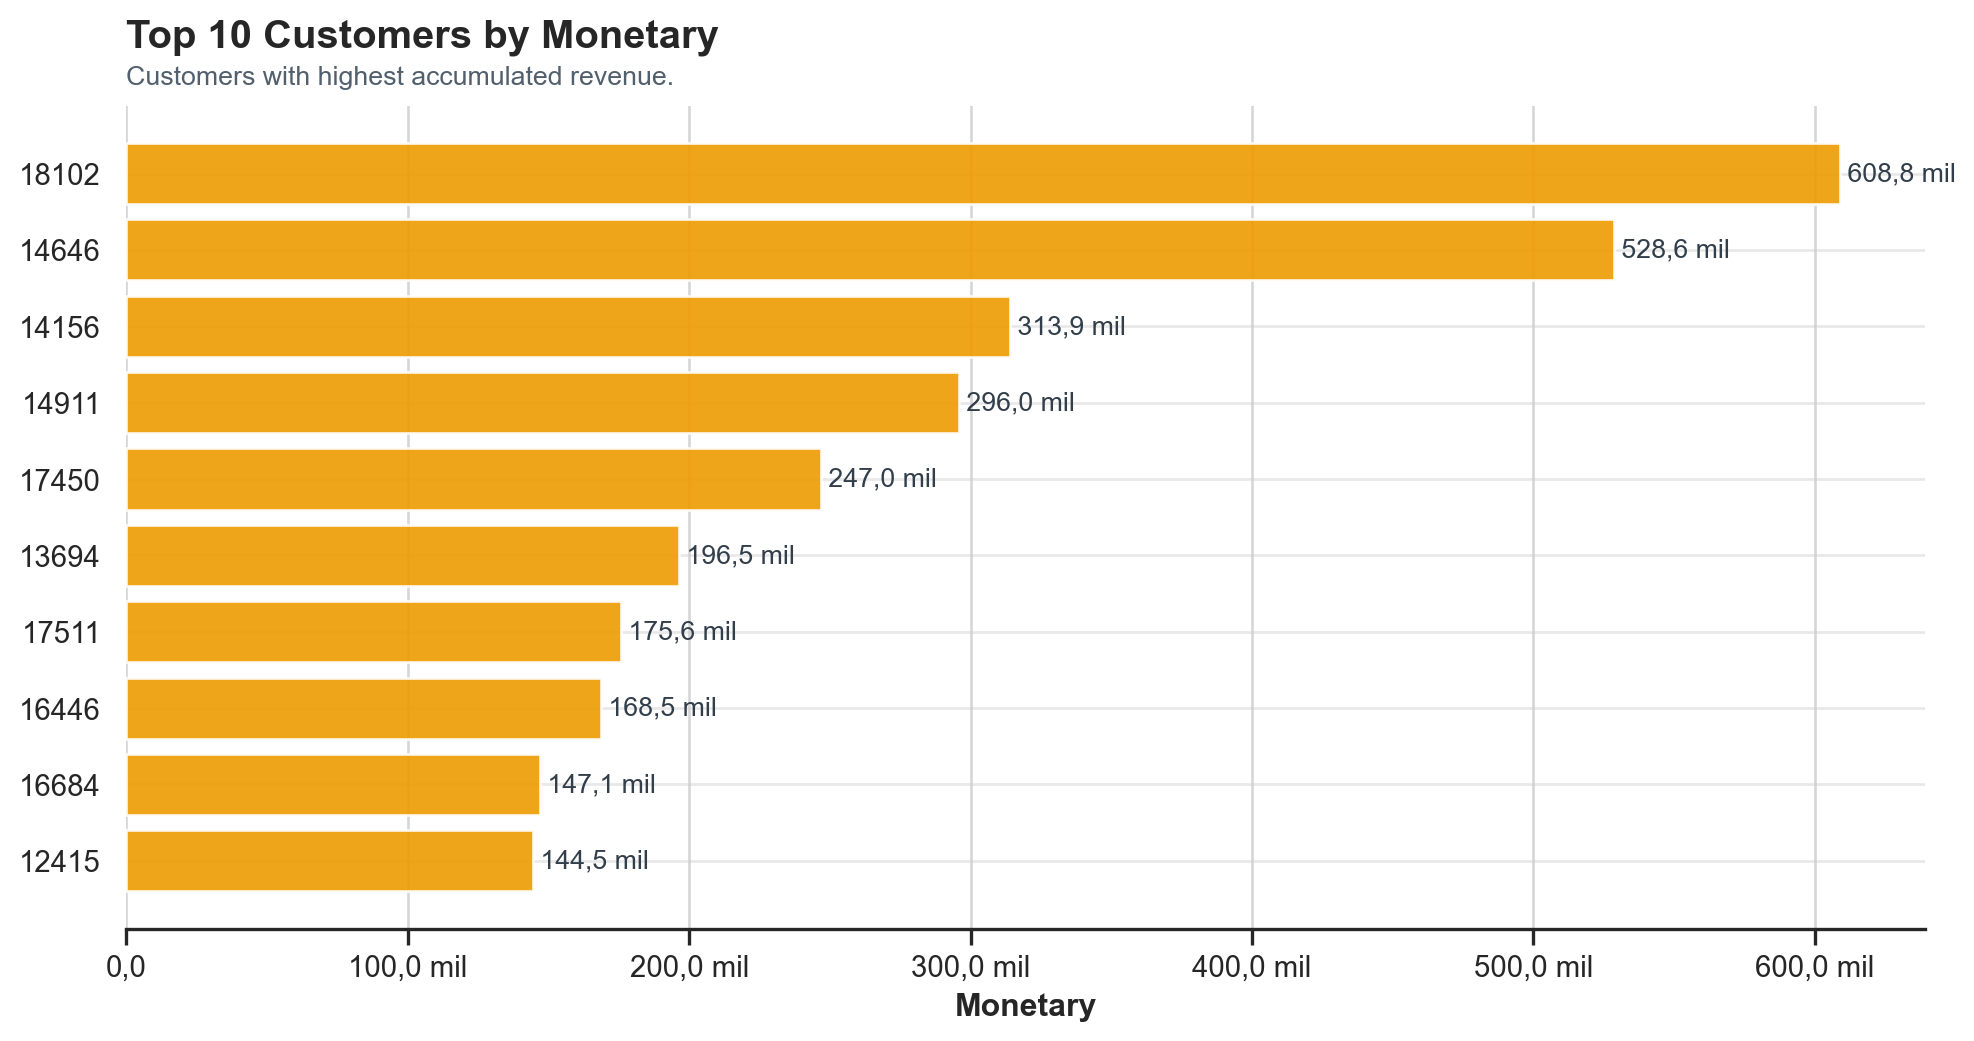

,Country,Revenue
38,United Kingdom,14723147.52
10,EIRE,621631.11
24,Netherlands,554232.34
14,Germany,431262.46
13,France,355257.47
0,Australia,169968.11
32,Spain,109178.53
34,Switzerland,100365.34
33,Sweden,91549.72
9,Denmark,69862.19


,Customer ID,Monetary
5692,18102,608821.65
2277,14646,528602.52
1789,14156,313946.37
2538,14911,295972.63
5050,17450,246973.09
1331,13694,196482.81
5109,17511,175603.55
4061,16446,168472.50
4295,16684,147142.77
68,12415,144458.37


In [44]:
hist(rfm["Recency"], "Recency Distribution", "Days since last purchase; lower value indicates a more recent customer.", "Days", PALETTE[0])
hist(rfm["Frequency"], "Frequency Distribution", "Number of unique invoices per customer, with visual cap at p99.", "Purchases", PALETTE[1], q=.99)
hist(rfm["Monetary"], "Monetary Distribution", "Revenue per customer, with visual cap at p99.", "Revenue", PALETTE[3], q=.99)
hist(rfm["AverageTicket"], "AverageTicket Distribution", "Average ticket per invoice, with visual cap at p99.", "Average ticket", PALETTE[4], q=.99)

country_revenue = clean_df.groupby("Country", as_index=False)["Revenue"].sum().sort_values("Revenue", ascending=False).head(10)
top_customers = rfm.nlargest(10, "Monetary")[["Customer ID", "Monetary"]]
barh(country_revenue.sort_values("Revenue"), "Country", "Revenue", "Top 10 Countries by Revenue", "Total revenue after data cleaning.", PALETTE[0])
barh(top_customers.sort_values("Monetary"), "Customer ID", "Monetary", "Top 10 Customers by Monetary", "Customers with highest accumulated revenue.", PALETTE[3])
display(country_revenue)
display(top_customers)

<span style="color:steelblue; text-align: left">

## Data Preparation for Clustering
</span>

The main variables are `Recency`, `Frequency`, `Monetary`, `AverageTicket` and `UniqueProducts`. The `log1p` transformation is applied to skewed variables (`Frequency`, `Monetary`, `AverageTicket` and `UniqueProducts`) to reduce the weight of outliers, a common practice in preprocessing when distributions are concentrated and long-tailed [Kuhn and Johnson, 2013; Hastie, Tibshirani and Friedman, 2009]. The features are then standardized because K-Means uses Euclidean distance and is sensitive to scale [MacQueen, 1967; Jain, 2010]. `Recency` must be read inversely: lower recency means a more recent or active customer.


In [45]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
log_features = [
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]

cluster_df = rfm[features].copy()
for col in log_features:
    cluster_df[col] = np.log1p(cluster_df[col])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(cluster_df)

print("Standardization used: StandardScaler")
display(cluster_df.head())


Standardization used: StandardScaler


,Recency,Frequency,Monetary,AverageTicket,UniqueProducts
0,326,2.56,11.26,8.77,3.33
1,2,2.20,8.64,6.56,4.84
2,75,1.79,7.61,6.00,3.26
3,19,1.61,8.40,7.01,4.93
4,310,0.69,5.82,5.82,2.89


<span style="color:steelblue; text-align: left">

## Choosing the Number of Clusters
</span>

Values of `k` between 2 and 10 are tested. The analysis uses `inertia`, related to the internal compactness typical of the K-Means least squares objective [Lloyd, 1982; Jain, 2010], and `silhouette_score`, to evaluate cohesion and separation between clusters [Rousseeuw, 1987]. The final choice combines metric and business utility, since a mathematically good number may be too broad to guide actions [Wedel and Kamakura, 2000].


,k,inertia,silhouette_score
0,2,17255.96,0.35
1,3,13659.28,0.28
2,4,11603.71,0.27
3,5,10286.31,0.25
4,6,9217.00,0.25
5,7,8533.81,0.23
6,8,7935.78,0.23
7,9,7438.42,0.23
8,10,6993.62,0.23


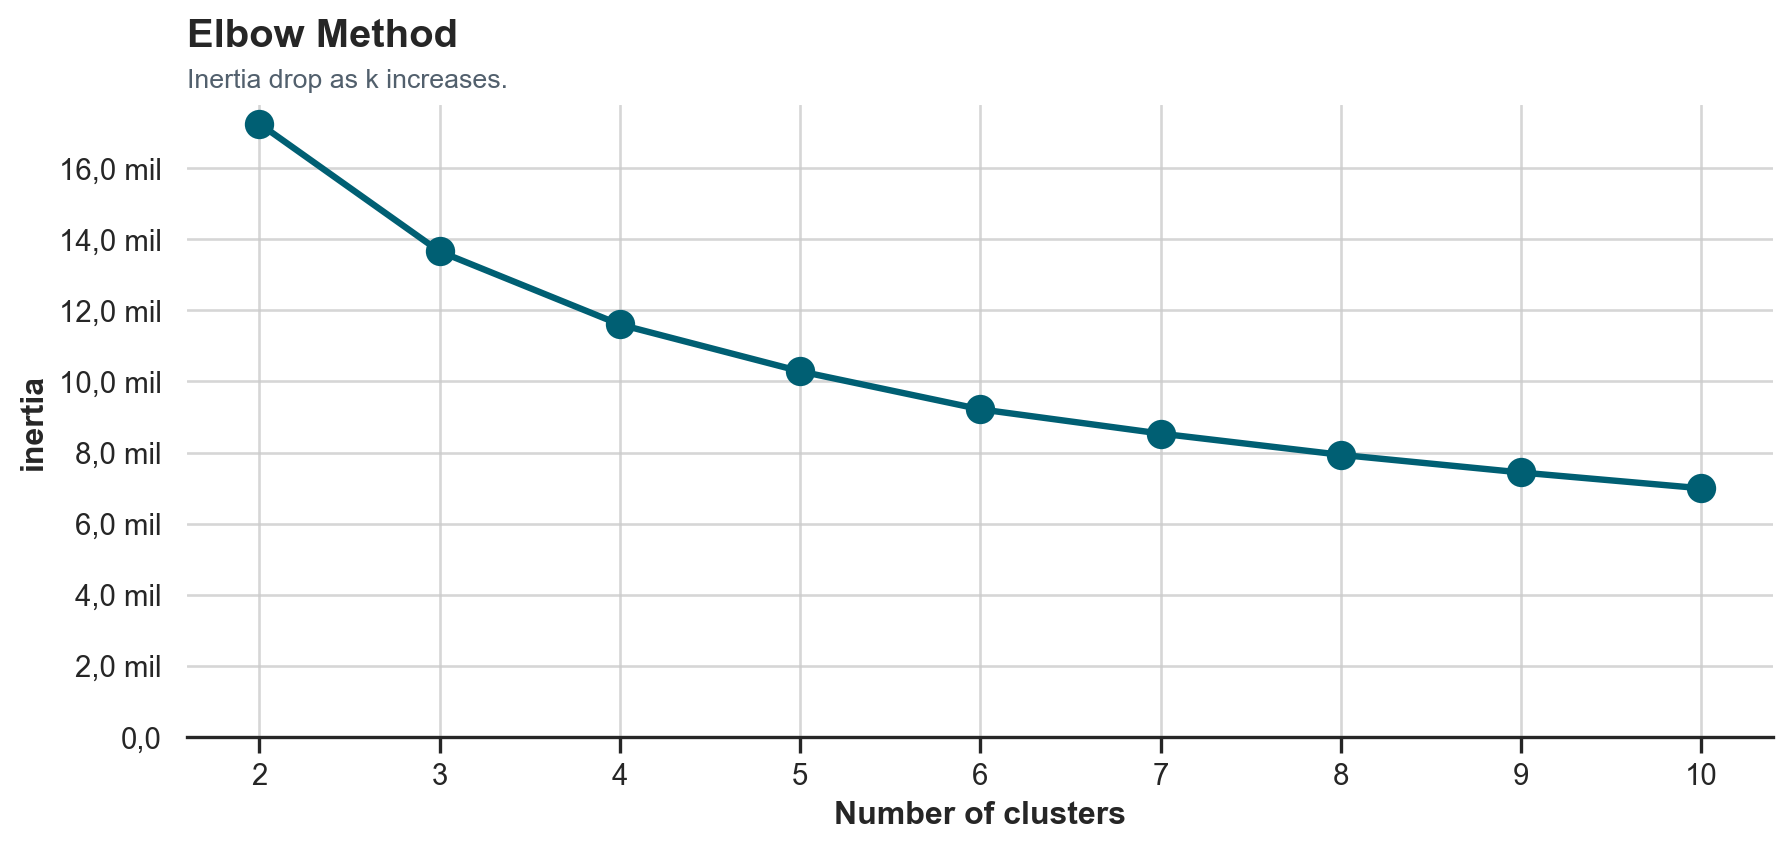

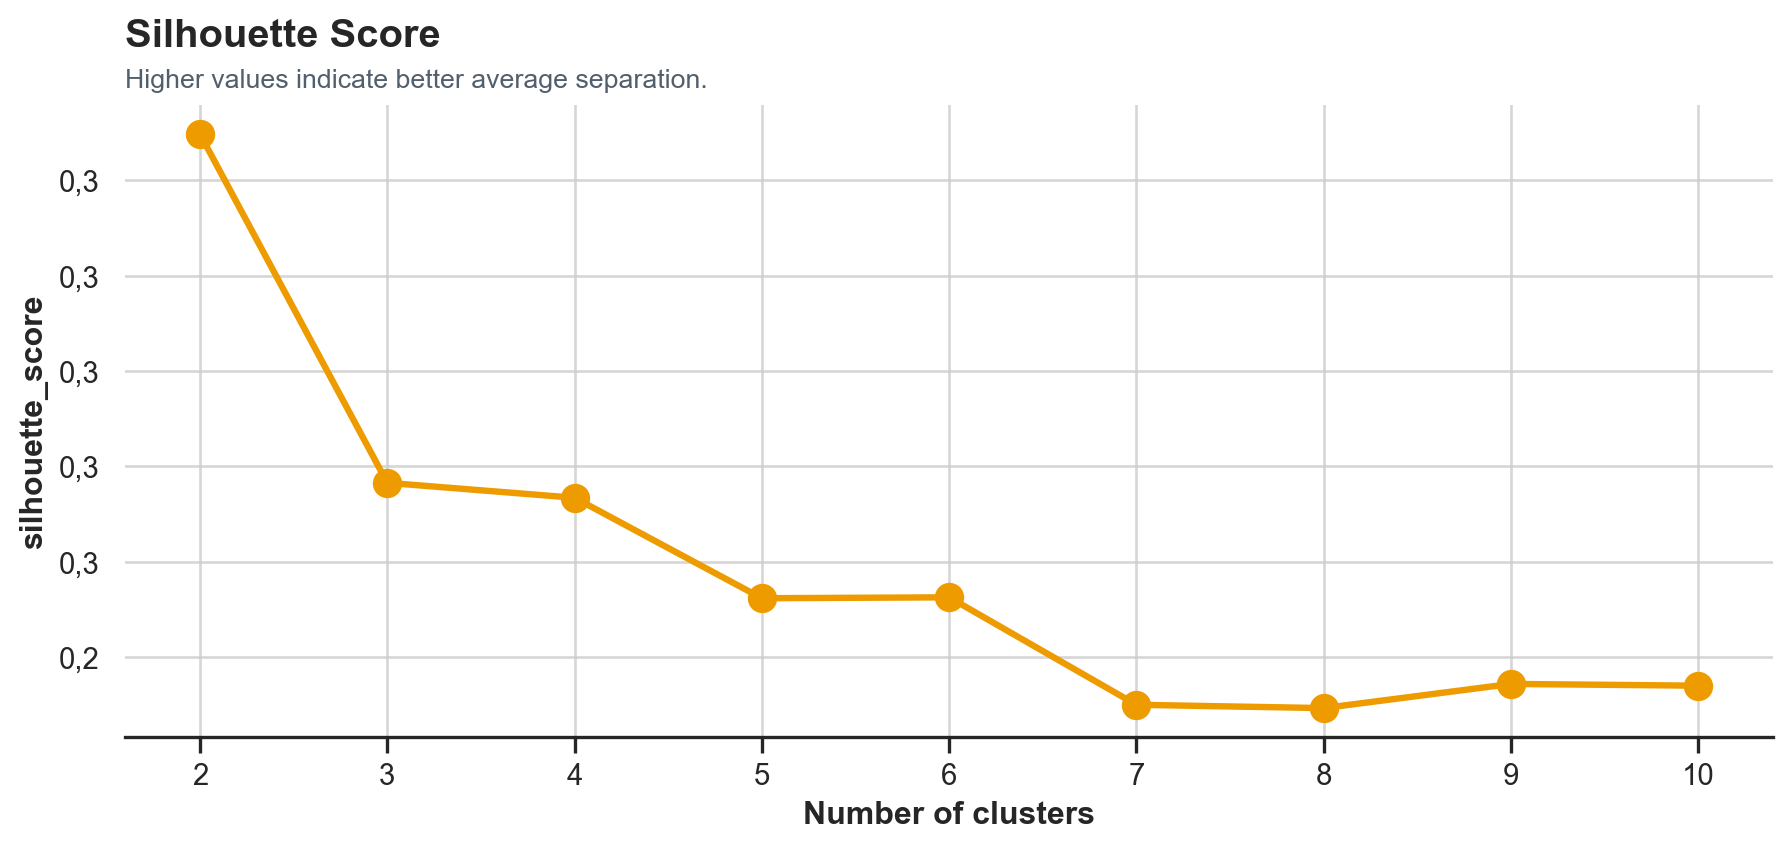


**Number of clusters chosen: 6.**

The highest silhouette was observed at `k=2`. Nevertheless, `k=6` was chosen because it offers more actionable segments for Next Best Action, separating high-value customers, loyal customers, occasional buyers, low-value customers, inactive customers and at-risk high-value customers. The decision prioritizes a balance between statistical quality, interpretability and business utility.


In [46]:
def fit_kmeans(x: np.ndarray, k: int, n_init: int = 10) -> tuple[np.ndarray, float]:
    """Trains K-Means and returns labels and inertia for a candidate k."""
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=n_init,
    )
    labels = model.fit_predict(x)
    return labels, float(model.inertia_)


def silhouette(x: np.ndarray, labels: np.ndarray, sample: int = 2500) -> float:
    """Calculates silhouette score with limited sampling to keep execution fast."""
    return float(
        silhouette_score(
            x,
            labels,
            sample_size=min(sample, len(x)),
            random_state=RANDOM_STATE,
        )
    )


rows = []
for k in range(2, 11):
    labels, inertia = fit_kmeans(x_scaled, k, n_init=10)
    rows.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette(x_scaled, labels),
    })

k_metrics = pd.DataFrame(rows)
display(k_metrics.round(4))
lineplot(
    k_metrics,
    "k",
    "inertia",
    "Elbow Method",
    "Inertia drop as k increases.",
    PALETTE[0],
    zero=True,
)
lineplot(
    k_metrics,
    "k",
    "silhouette_score",
    "Silhouette Score",
    "Higher values indicate better average separation.",
    PALETTE[3],
)

# FIX: best_k is used explicitly in the justification displayed in the notebook.
best_k = int(k_metrics.loc[k_metrics["silhouette_score"].idxmax(), "k"])
# FIX P4: number of clusters parameterized in the configuration cell.
selected_k = N_CLUSTERS
text = f"""
**Number of clusters chosen: {selected_k}.**

The highest silhouette was observed at `k={best_k}`. Nevertheless, `k={selected_k}` was chosen because it offers more actionable segments for Next Best Action, separating high-value customers, loyal customers, occasional buyers, low-value customers, inactive customers and at-risk high-value customers. The decision prioritizes a balance between statistical quality, interpretability and business utility.
"""
display(Markdown(text))


<span style="color:steelblue; text-align: left">

## K-Means Segmentation

</span>

The final model is trained with the chosen number of clusters. K-Means seeks to partition observations into groups close to centroids, minimizing internal distances, an idea formalized in classic works by MacQueen and Lloyd [MacQueen, 1967; Lloyd, 1982]. The technical label `Cluster` is added to the RFM table for analysis of size, means, medians, total revenue and percentage of revenue.


In [47]:
labels, final_inertia = fit_kmeans(x_scaled, selected_k, n_init=20)
rfm["Cluster"] = labels.astype(int)

cluster_vars = ["Recency", "Frequency", "Monetary", "AverageTicket", "QuantityTotal", "UniqueProducts"]
cluster_size = rfm["Cluster"].value_counts().sort_index().rename_axis("Cluster").reset_index(name="Customers")
cluster_mean = rfm.groupby("Cluster")[cluster_vars].mean().round(2)
cluster_median = rfm.groupby("Cluster")[cluster_vars].median().round(2)
cluster_revenue = rfm.groupby("Cluster", as_index=False).agg(TotalRevenue=("Monetary", "sum"))
cluster_revenue["RevenuePercentage"] = (cluster_revenue["TotalRevenue"] / cluster_revenue["TotalRevenue"].sum() * 100).round(2)

display(cluster_size)
display(cluster_mean)
display(cluster_median)
display(cluster_revenue)


,Cluster,Customers
0,0,674
1,1,1158
2,2,1095
3,3,1510
4,4,577
5,5,864


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,198.63,2.88,2931.68,1098.75,2046.04,70.58
1,95.69,2.17,443.49,227.96,299.01,25.14
2,488.79,1.83,517.80,303.95,305.30,32.18
3,84.15,6.51,1760.76,283.66,1053.46,99.74
4,421.09,1.39,129.98,100.71,77.98,7.58
5,38.76,23.02,13834.69,554.13,8114.42,248.89


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,149.50,3.00,1635.15,672.61,926.00,57.50
1,65.00,2.00,389.32,205.65,221.50,22.00
2,456.00,1.00,406.30,282.30,225.00,26.00
3,41.00,6.00,1590.66,272.96,881.00,83.00
4,430.00,1.00,118.86,101.36,59.00,6.00
5,17.00,16.00,6698.07,431.78,3716.00,199.00


,Cluster,TotalRevenue,RevenuePercentage
0,0,1975951.49,11.14
1,1,513556.93,2.89
2,2,566995.71,3.20
3,3,2658749.94,14.98
4,4,75000.23,0.42
5,5,11953174.87,67.37


<span style="color:steelblue; text-align: left">

## Cluster Interpretation
</span>

The cluster number has no business meaning. The interpretation below transforms each group into a segment using recency, frequency, revenue, average ticket and product variety. This translation of statistical groupings into managerial segments is central to applied market segmentation [Wedel and Kamakura, 2000; Chen, Sain and Guo, 2012].


In [48]:
ACTIONS = {
    "Champions": "Offer VIP program, early access and exclusive benefits.",
    "High Value at Risk": "Prioritize reactivation campaigns and personalized offers.",
    "Loyal Customers": "Encourage cross-sell and bundles.",
    "Occasional Buyers": "Second-purchase campaigns and low-cost coupons.",
    "Low Value": "Low-cost marketing automation.",
    "Inactive Customers": "Targeted reactivation or low priority.",
}

profile = rfm.groupby("Cluster").agg(
    Clientes=("Customer ID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    AverageTicket_mean=("AverageTicket", "mean"),
    UniqueProducts_mean=("UniqueProducts", "mean"),
    ReceitaTotal=("Monetary", "sum"),
).reset_index()
profile["PercentualReceita"] = profile["ReceitaTotal"] / profile["ReceitaTotal"].sum() * 100


def rank01(s: pd.Series, high: bool = True) -> pd.Series:
    """Normalizes ranks between 0 and 1; high=True favors higher values."""
    r = s.rank(ascending=True)
    if r.max() == r.min():
        score = r * 0 + 1
    else:
        score = (r - r.min()) / (r.max() - r.min())
    return score if high else 1 - score


def segment_names(p: pd.DataFrame) -> dict[int, str]:
    """Names clusters by recency, frequency, value, ticket and variety rankings."""
    p = p.set_index("Cluster")
    rem: set[int] = set(p.index)
    names: dict[int, str] = {}
    recent = rank01(p["Recency_mean"], high=False)
    old = rank01(p["Recency_mean"], high=True)
    freq = rank01(p["Frequency_mean"], high=True)
    mon = rank01(p["Monetary_mean"], high=True)
    ticket = rank01(p["AverageTicket_mean"], high=True)
    prod = rank01(p["UniqueProducts_mean"], high=True)

    champ = (recent * 0.25 + freq * 0.30 + mon * 0.30 + prod * 0.15).idxmax()
    names[int(champ)] = "Champions"
    rem.discard(champ)

    if rem:
        risk = (
            mon.loc[list(rem)] * 0.45
            + ticket.loc[list(rem)] * 0.30
            + old.loc[list(rem)] * 0.25
        ).idxmax()
        names[int(risk)] = "High Value at Risk"
        rem.discard(risk)
    if rem:
        loyal = freq.loc[list(rem)].idxmax()
        names[int(loyal)] = "Loyal Customers"
        rem.discard(loyal)
    if rem:
        inactive = old.loc[list(rem)].idxmax()
        names[int(inactive)] = "Inactive Customers"
        rem.discard(inactive)
    if rem:
        low = (
            mon.loc[list(rem)] * 0.45
            + freq.loc[list(rem)] * 0.30
            + prod.loc[list(rem)] * 0.25
        ).idxmin()
        names[int(low)] = "Low Value"
        rem.discard(low)
    for cl in rem:
        names[int(cl)] = "Occasional Buyers"
    return names


def validate_segment_names(p: pd.DataFrame, assigned_names: dict[int, str]) -> None:
    """Issues a warning when automatic names violate minimum business conditions."""
    # FIX: sanity validation to avoid fragile segment naming.
    named = p.assign(NomeSegmento=p["Cluster"].map(assigned_names))
    recency_overall = named["Recency_mean"].mean()
    monetary_median = named["Monetary_mean"].median()

    try:
        champions_recency = named.loc[
            named["NomeSegmento"] == "Champions",
            "Recency_mean",
        ].iloc[0]
        inactive_recency = named.loc[
            named["NomeSegmento"] == "Inactive Customers",
            "Recency_mean",
        ].iloc[0]
        risk_monetary = named.loc[
            named["NomeSegmento"] == "High Value at Risk",
            "Monetary_mean",
        ].iloc[0]

        assert champions_recency < recency_overall, "Champions have above-average recency."
        assert inactive_recency > recency_overall, "Inactive Customers have below-average recency."
        assert risk_monetary > monetary_median, "High Value at Risk has below-median monetary."
    except (AssertionError, IndexError) as exc:
        warnings.warn(
            "Check manual segment assignment — automatic criteria "
            f"were not satisfied. Detail: {exc}",
            stacklevel=2,
        )


names = segment_names(profile)
validate_segment_names(profile, names)
profile["NomeSegmento"] = profile["Cluster"].map(names)
profile["PerfilComportamental"] = profile.apply(
    lambda r: (
        f"Average recency of {fmt(r['Recency_mean'], 0)} days, "
        f"average frequency of {fmt(r['Frequency_mean'], 1)} purchases, "
        f"average revenue of {fmt(r['Monetary_mean'], 2)}, "
        f"average ticket of {fmt(r['AverageTicket_mean'], 2)} and "
        f"{fmt(r['UniqueProducts_mean'], 0)} distinct products."
    ),
    axis=1,
)
profile["AcaoRecomendada"] = profile["NomeSegmento"].map(ACTIONS)

rfm["SegmentName"] = rfm["Cluster"].map(names)
rfm["NextBestAction"] = rfm["SegmentName"].map(ACTIONS)

segment_table = profile[[
    "Cluster",
    "NomeSegmento",
    "PerfilComportamental",
    "ReceitaTotal",
    "PercentualReceita",
    "AcaoRecomendada",
]].sort_values("ReceitaTotal", ascending=False)
display(segment_table)


,Cluster,NomeSegmento,PerfilComportamental,ReceitaTotal,PercentualReceita,AcaoRecomendada
5,5,Champions,"Average recency of 39 days, average frequency of 23,0 purchases, average revenue of 13.834,69, average ticket of 554,13 and 249 distinct products.",11953174.87,67.37,"Offer VIP program, early access and exclusive benefits."
3,3,Loyal Customers,"Average recency of 84 days, average frequency of 6,5 purchases, average revenue of 1.760,76, average ticket of 283,66 and 100 distinct products.",2658749.94,14.98,Encourage cross-sell and bundles.
0,0,High Value at Risk,"Average recency of 199 days, average frequency of 2,9 purchases, average revenue of 2.931,68, average ticket of 1.098,75 and 71 distinct products.",1975951.49,11.14,Prioritize reactivation campaigns and personalized offers.
2,2,Inactive Customers,"Average recency of 489 days, average frequency of 1,8 purchases, average revenue of 517,80, average ticket of 303,95 and 32 distinct products.",566995.71,3.20,Targeted reactivation or low priority.
1,1,Occasional Buyers,"Average recency of 96 days, average frequency of 2,2 purchases, average revenue of 443,49, average ticket of 227,96 and 25 distinct products.",513556.93,2.89,Second-purchase campaigns and low-cost coupons.
4,4,Low Value,"Average recency of 421 days, average frequency of 1,4 purchases, average revenue of 129,98, average ticket of 100,71 and 8 distinct products.",75000.23,0.42,Low-cost marketing automation.


<span style="color:steelblue; text-align: left">

## Cluster Visualizations
</span>

The visualizations connect patterns of frequency, value, recency, revenue and segment size. Exploratory charts help validate whether the groups are interpretable and whether the solution makes sense beyond the numerical metric [Tukey, 1977; Rousseeuw, 1987]. Readings should consider that lower `Recency` represents a more recent purchase.


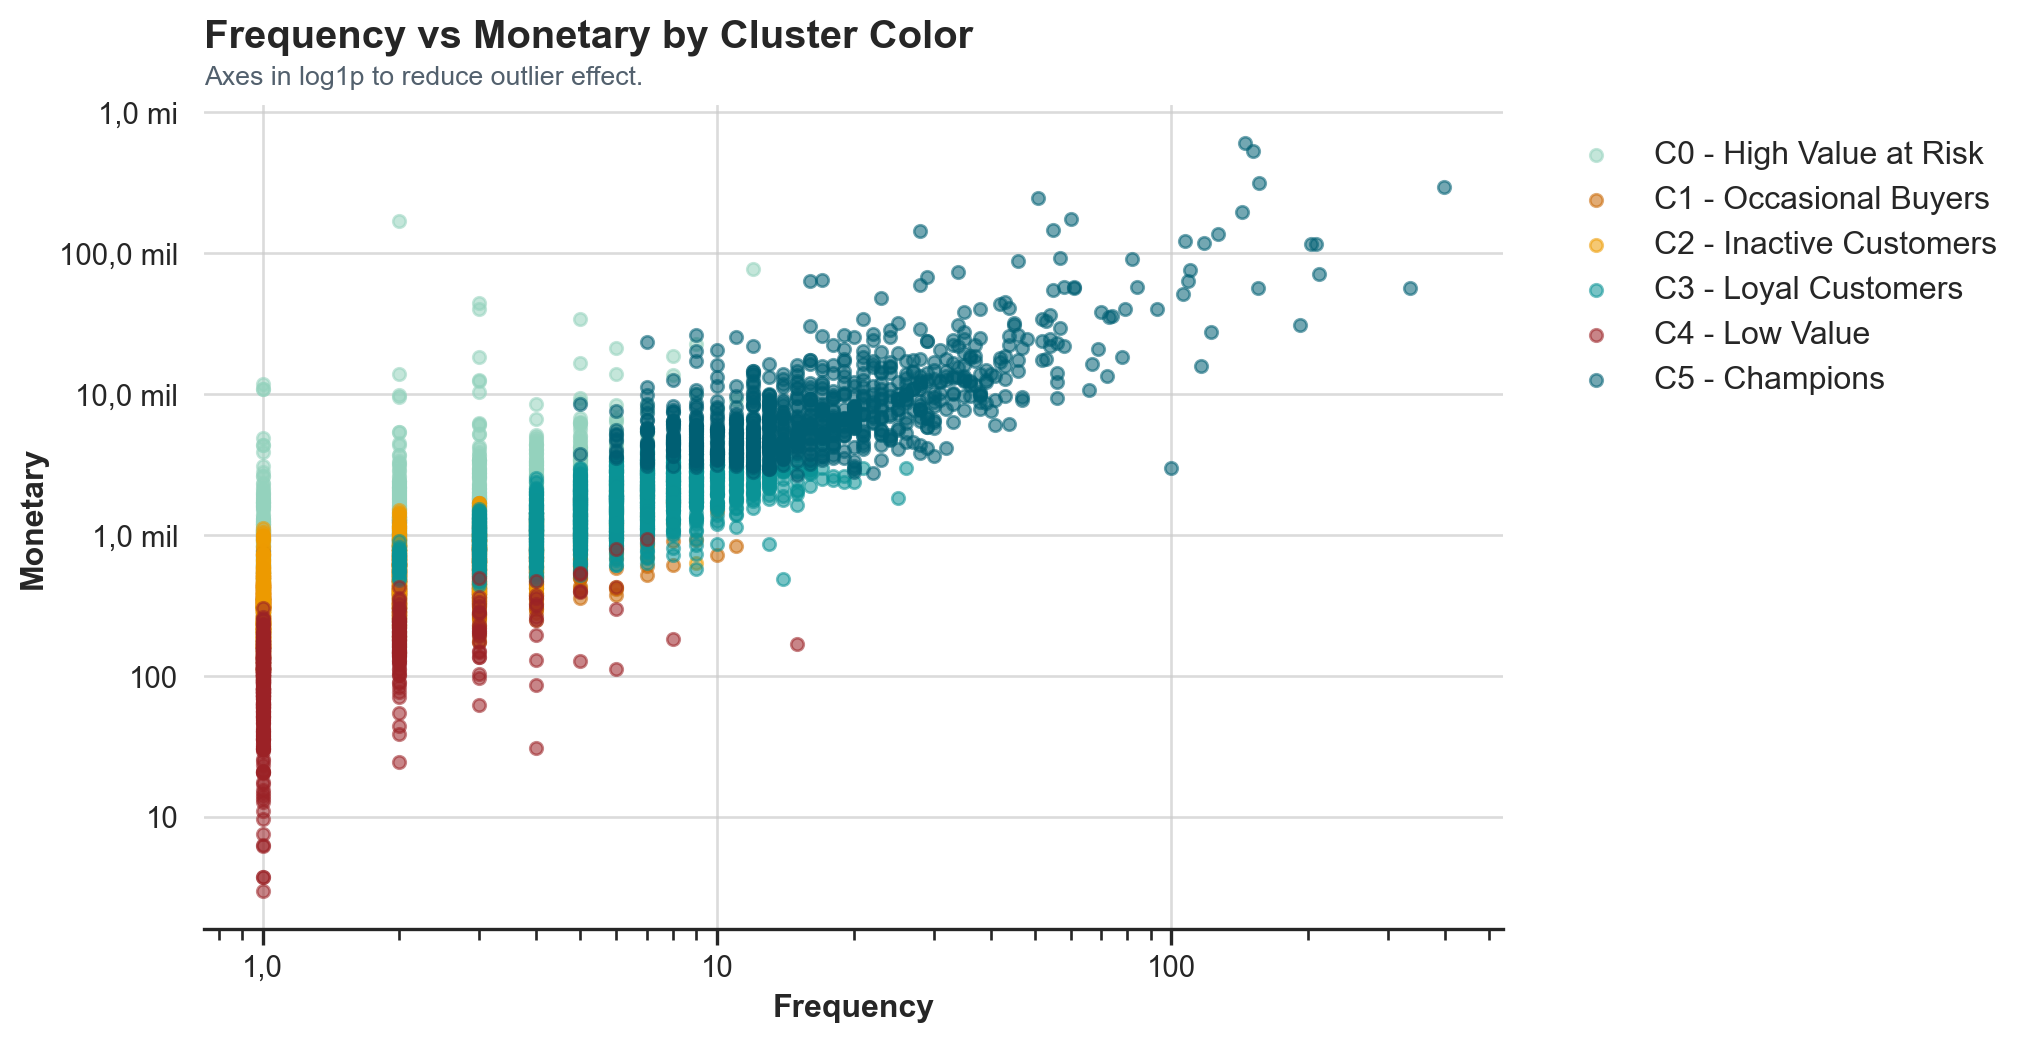

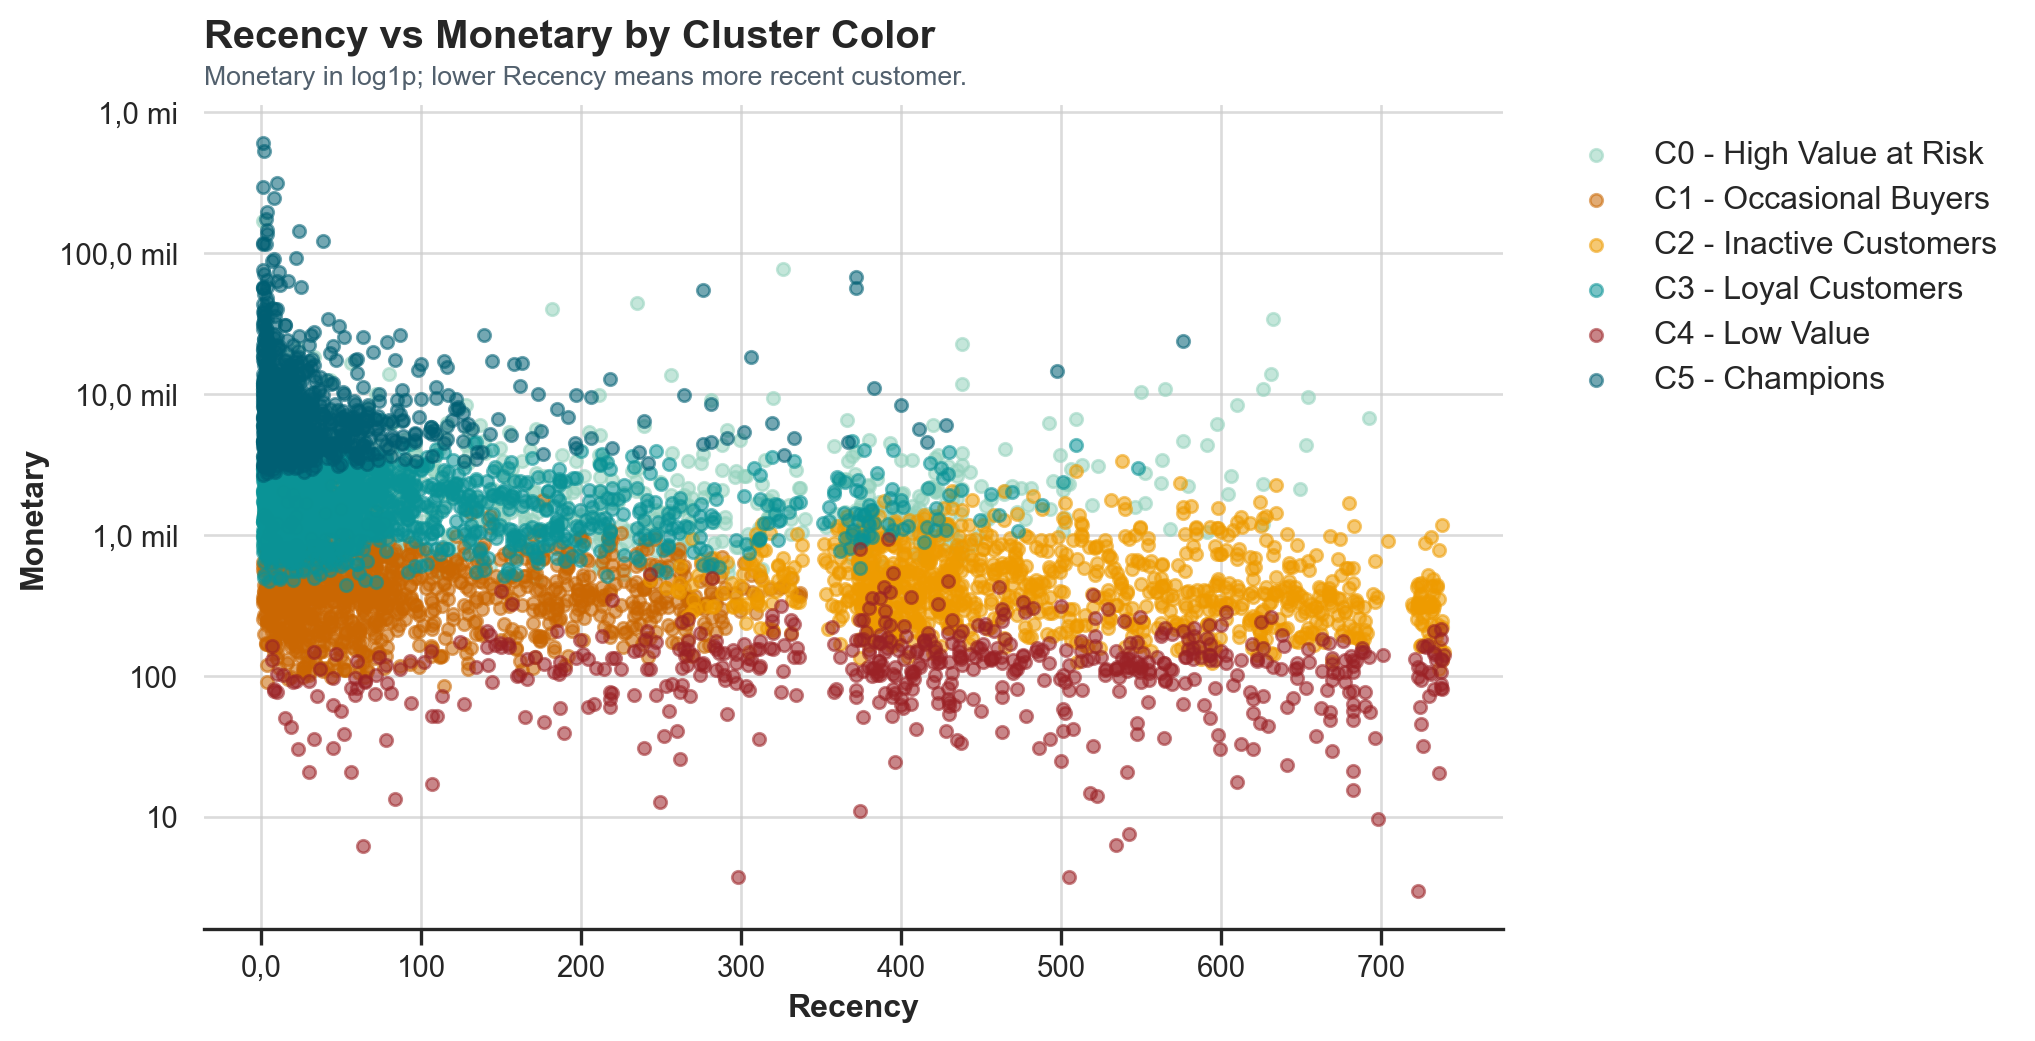

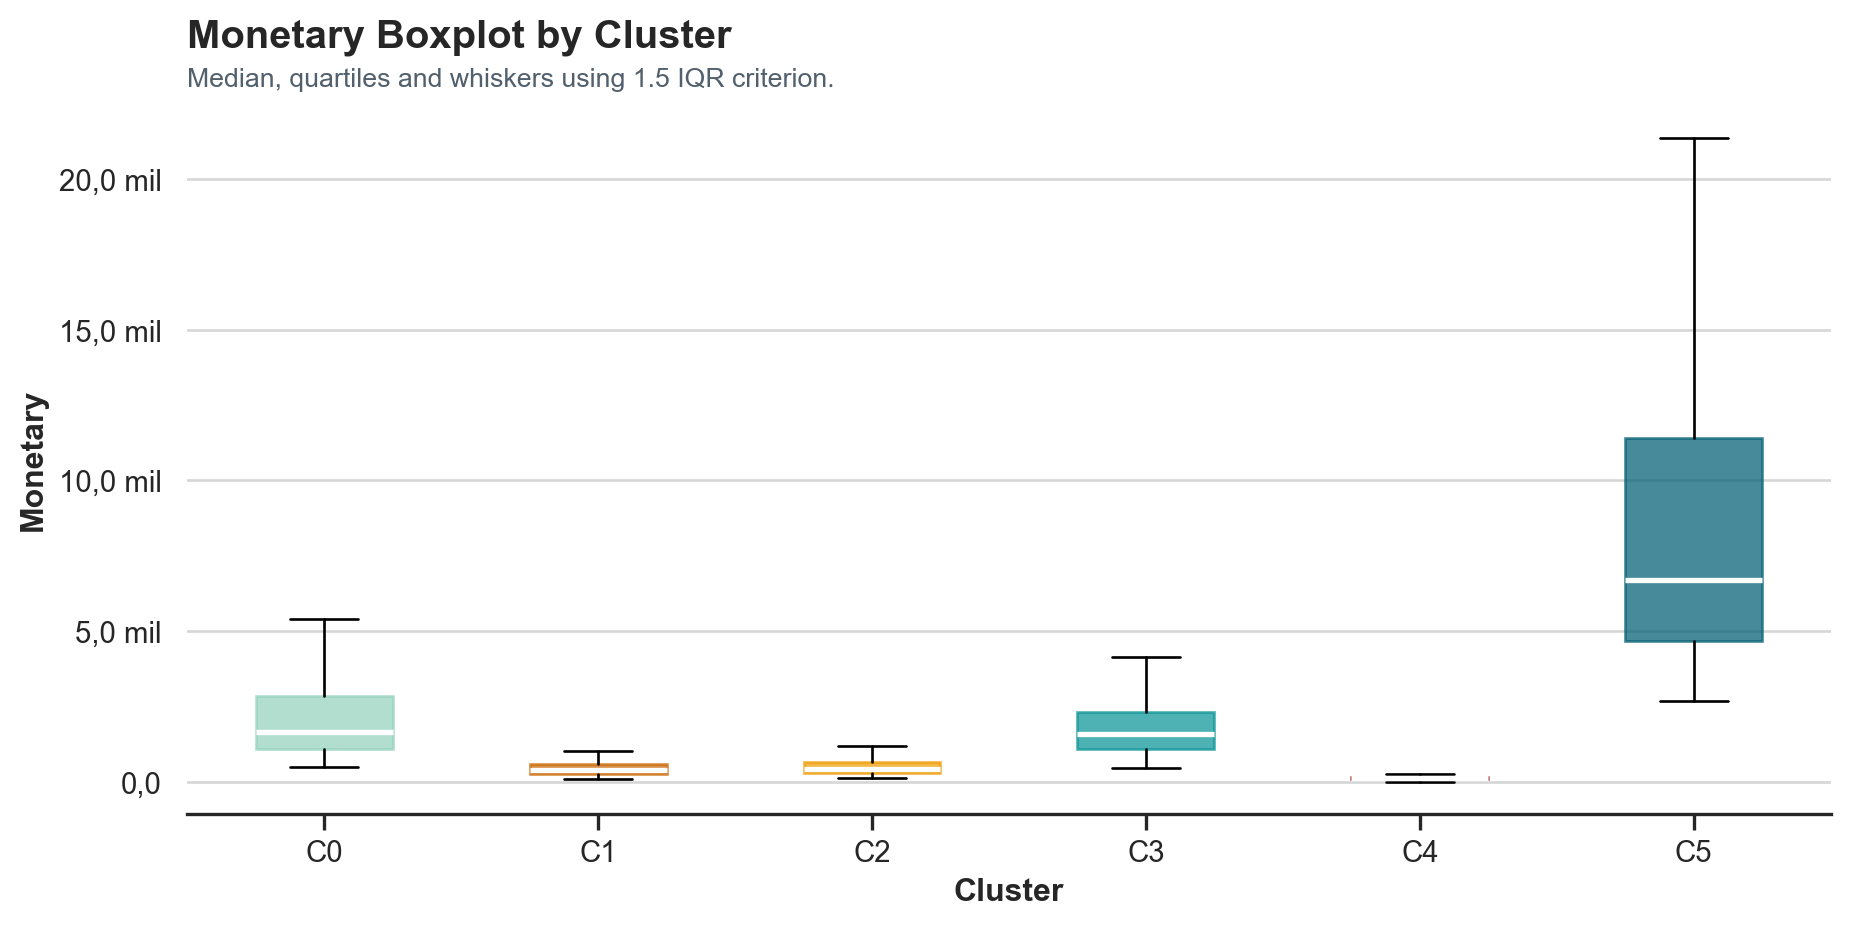

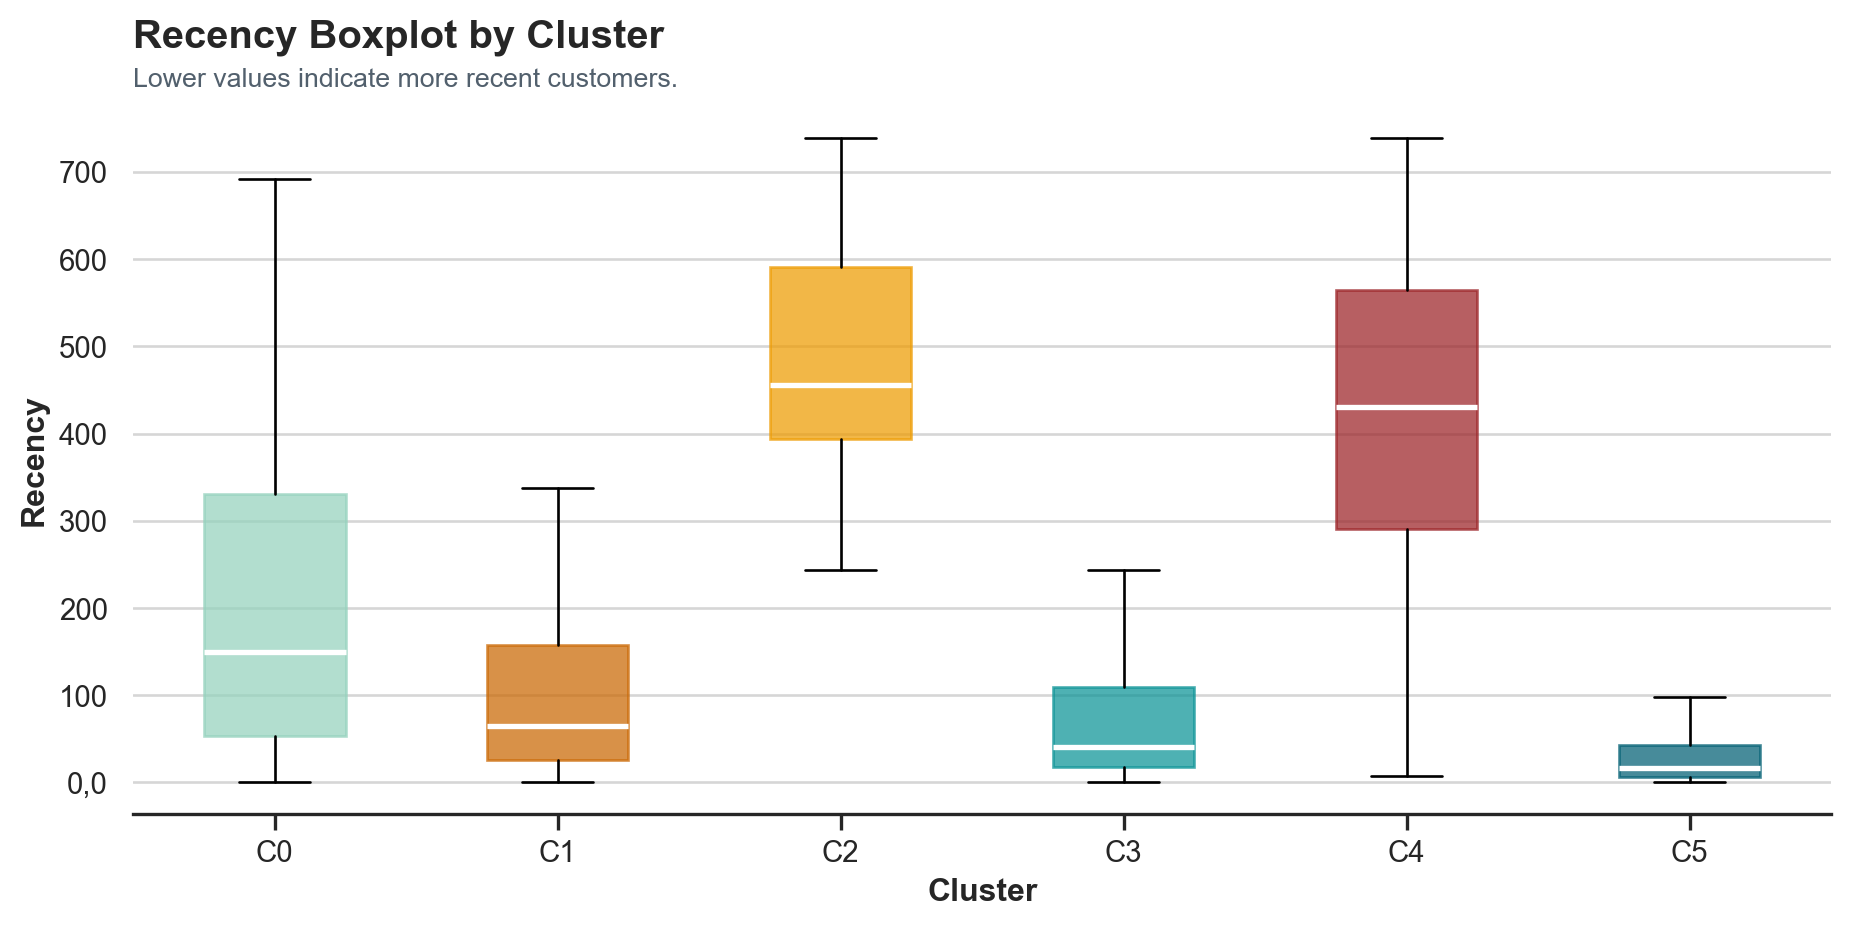

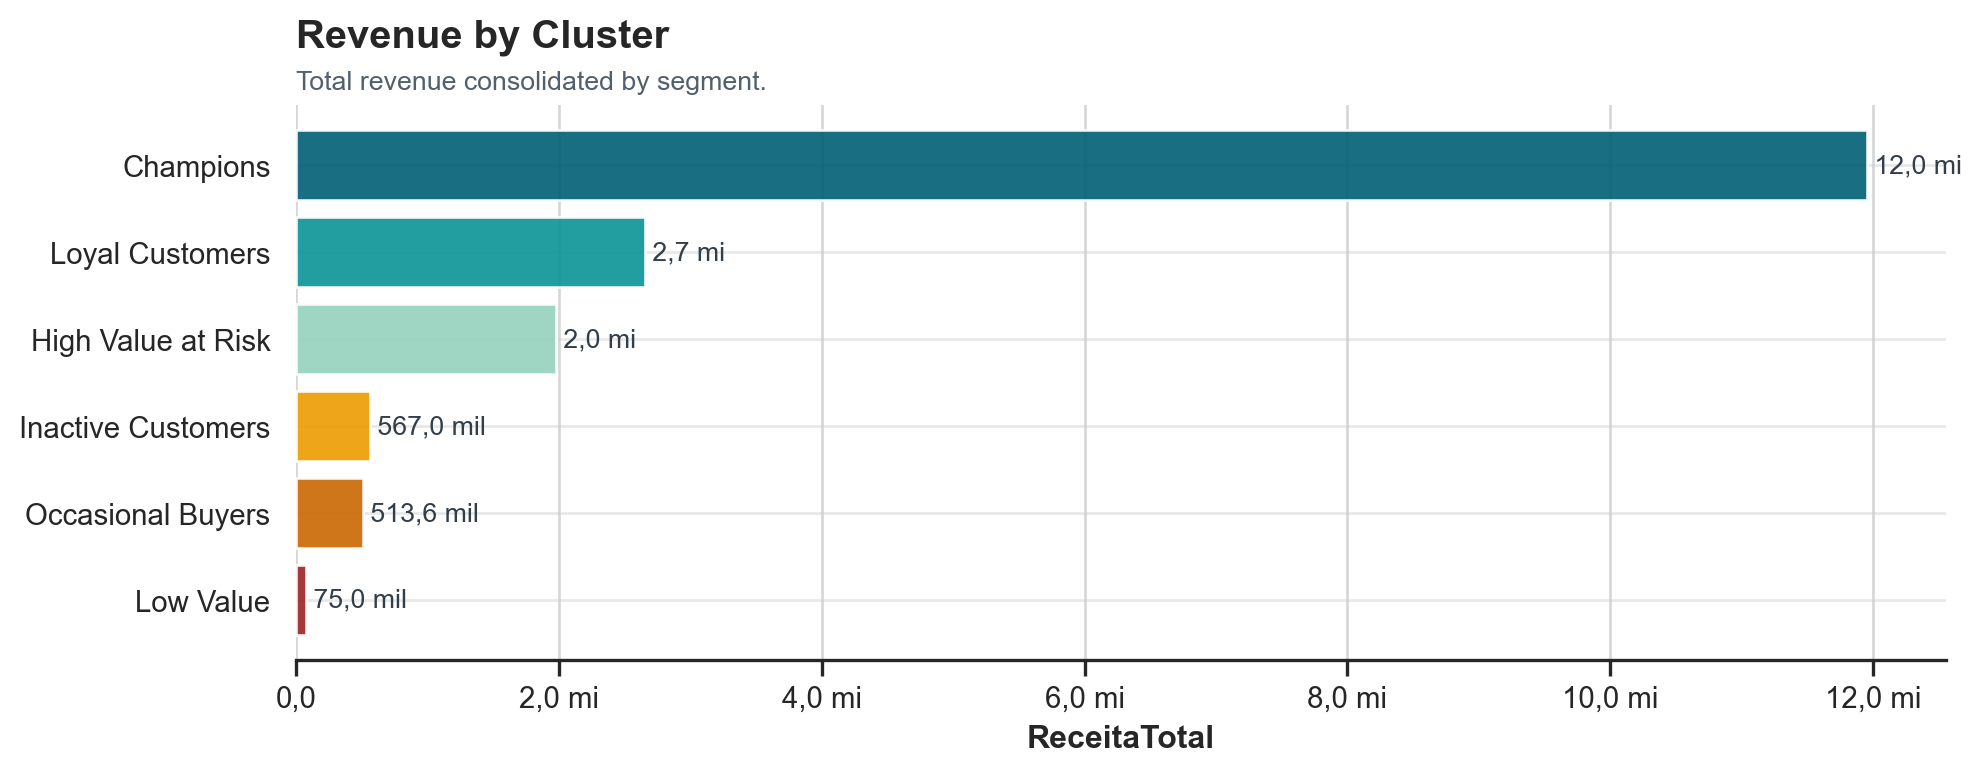

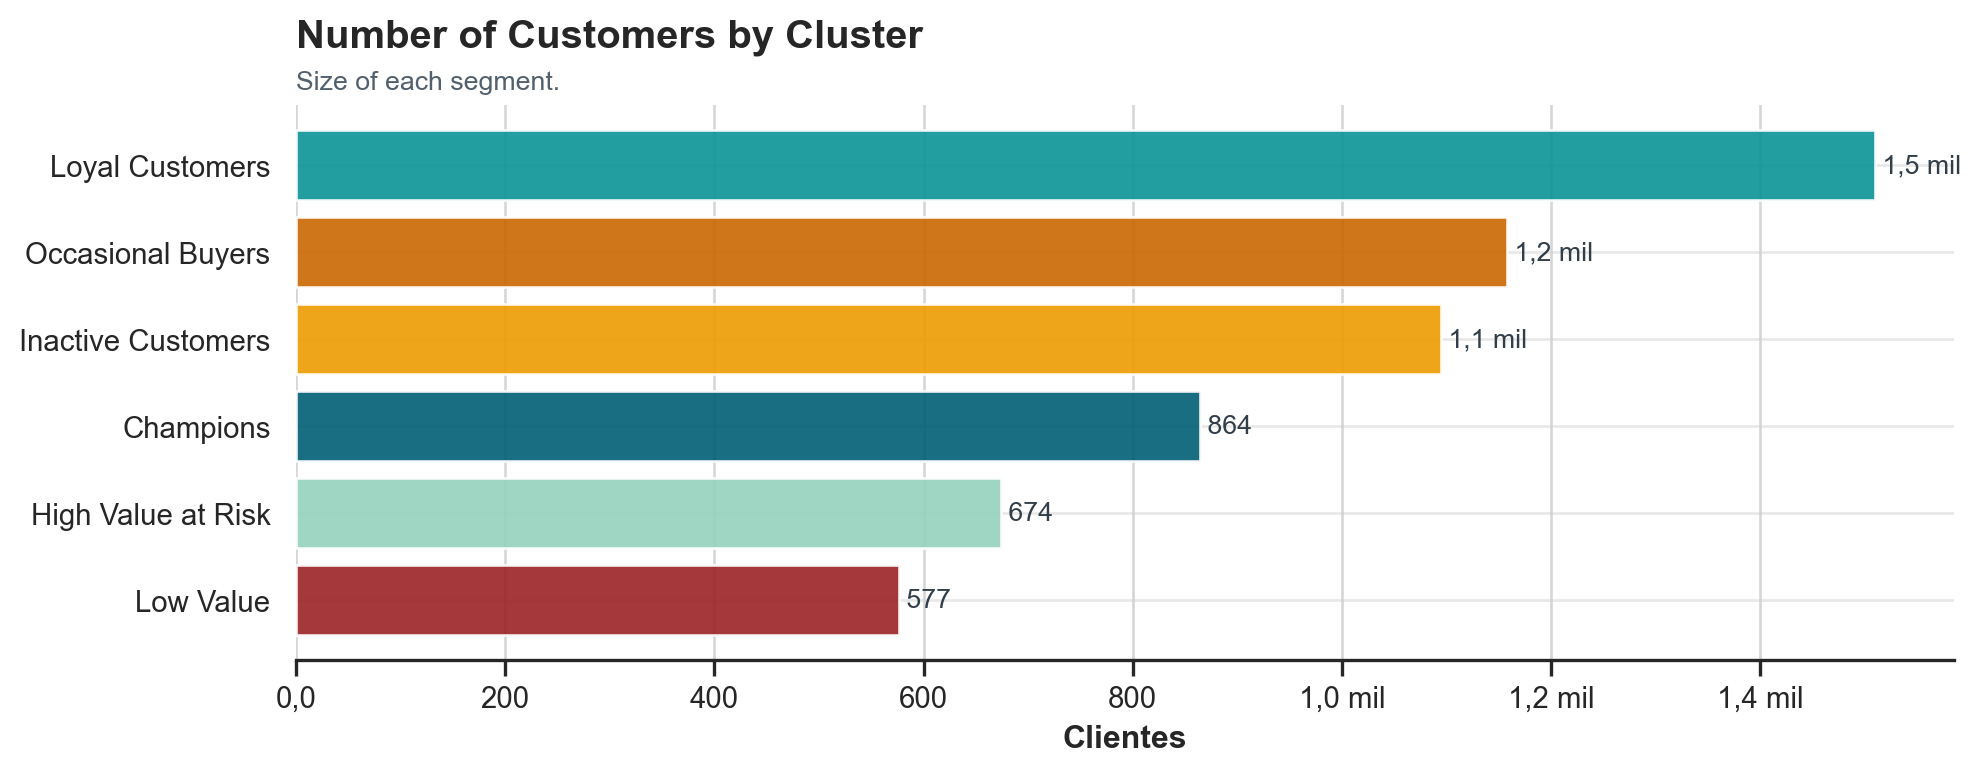

In [49]:
order = segment_table["Cluster"].tolist()
cluster_colors = {cl: PALETTE[i % len(PALETTE)] for i, cl in enumerate(order)}

scatter(rfm, "Frequency", "Monetary", "Frequency vs Monetary by Cluster Color", "Axes in log1p to reduce outlier effect.", cluster_colors, logx=True, logy=True)
scatter(rfm, "Recency", "Monetary", "Recency vs Monetary by Cluster Color", "Monetary in log1p; lower Recency means more recent customer.", cluster_colors, logy=True)
boxplot(rfm, "Cluster", "Monetary", "Monetary Boxplot by Cluster", "Median, quartiles and whiskers using 1.5 IQR criterion.", cluster_colors)
boxplot(rfm, "Cluster", "Recency", "Recency Boxplot by Cluster", "Lower values indicate more recent customers.", cluster_colors)
barh(profile.sort_values("ReceitaTotal"), "NomeSegmento", "ReceitaTotal", "Revenue by Cluster", "Total revenue consolidated by segment.", color_col="Cluster", cmap=cluster_colors)
barh(profile.sort_values("Clientes"), "NomeSegmento", "Clientes", "Number of Customers by Cluster", "Size of each segment.", color_col="Cluster", cmap=cluster_colors)

<span style="color:steelblue; text-align: left">

## Next Best Action
</span>

Next Best Action transforms segmentation into operational decisions. The first version below is a heuristic recommendation by segment, useful for initial managerial reading. The notebook then evolves this logic into a predictive and prescriptive layer, in which the action is chosen by simulated expected profit. This approach is consistent with research on personalized marketing interventions and prescriptive analytics, in which historical data guides action policies and resource allocation [Rust and Verhoef, 2005; Bertsimas and Kallus, 2019].


In [50]:
next_action_summary = rfm.groupby(["SegmentName", "NextBestAction"], as_index=False).agg(
    Clientes=("Customer ID", "count"),
    ReceitaTotal=("Monetary", "sum"),
    RecencyMedia=("Recency", "mean"),
    FrequencyMedia=("Frequency", "mean"),
).sort_values("ReceitaTotal", ascending=False)
next_action_summary["PercentualReceita"] = next_action_summary["ReceitaTotal"] / next_action_summary["ReceitaTotal"].sum() * 100

display(next_action_summary)
display(rfm[["Customer ID", "Cluster", "SegmentName", "Recency", "Frequency", "Monetary", "AverageTicket", "UniqueProducts", "NextBestAction"]].head(10))


,SegmentName,NextBestAction,Clientes,ReceitaTotal,RecencyMedia,FrequencyMedia,PercentualReceita
0,Champions,"Offer VIP program, early access and exclusive benefits.",864,11953174.87,38.76,23.02,67.37
4,Loyal Customers,Encourage cross-sell and bundles.,1510,2658749.94,84.15,6.51,14.98
1,High Value at Risk,Prioritize reactivation campaigns and personalized offers.,674,1975951.49,198.63,2.88,11.14
2,Inactive Customers,Targeted reactivation or low priority.,1095,566995.71,488.79,1.83,3.20
5,Occasional Buyers,Second-purchase campaigns and low-cost coupons.,1158,513556.93,95.69,2.17,2.89
3,Low Value,Low-cost marketing automation.,577,75000.23,421.09,1.39,0.42


,Customer ID,Cluster,SegmentName,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,NextBestAction
0,12346,0,High Value at Risk,326,12,77556.46,6463.04,27,Prioritize reactivation campaigns and personalized offers.
1,12347,5,Champions,2,8,5633.32,704.16,126,"Offer VIP program, early access and exclusive benefits."
2,12348,3,Loyal Customers,75,5,2019.40,403.88,25,Encourage cross-sell and bundles.
3,12349,0,High Value at Risk,19,4,4428.69,1107.17,138,Prioritize reactivation campaigns and personalized offers.
4,12350,2,Inactive Customers,310,1,334.40,334.40,17,Targeted reactivation or low priority.
5,12351,2,Inactive Customers,375,1,300.93,300.93,21,Targeted reactivation or low priority.
6,12352,3,Loyal Customers,36,10,2849.84,284.98,70,Encourage cross-sell and bundles.
7,12353,1,Occasional Buyers,204,2,406.76,203.38,23,Second-purchase campaigns and low-cost coupons.
8,12354,0,High Value at Risk,232,1,1079.40,1079.40,58,Prioritize reactivation campaigns and personalized offers.
9,12355,0,High Value at Risk,214,2,947.61,473.81,35,Prioritize reactivation campaigns and personalized offers.


<span style="color:steelblue; text-align: left">

## From Predictive to Prescriptive Analytics
</span>

Segmentation answers **who the customers are** and what behavioral patterns appear in the data. The supervised model answers **what is the probability of future repurchase**. The prescriptive layer answers **which action maximizes expected value** given this scenario.

This evolution brings the project closer to the framework of Bertsimas and Kallus [Bertsimas and Kallus, 2019]: `X` represents the observed customer data, `Y` represents future repurchase, `z` represents the incentive or campaign decision, and the objective function chooses the action that maximizes expected profit. The notebook therefore moves from a heuristic cluster-based recommendation to a simulated prescriptive recommendation.

Important: the simulation below **does not estimate real causal effects** of the incentive. The uplift values are business hypotheses to demonstrate the prescriptive mechanics. In production, the incremental effect of each campaign should be validated through A/B testing or uplift modeling, since causal questions depend on well-defined interventions [Imbens and Rubin, 2015].


<span style="color:steelblue; text-align: left">

## Temporal Repurchase Target
</span>

To avoid data leakage, the dataset is split by time. Features are built only from purchases prior to the cutoff date. The target `repurchase_90d` observes the 90 days following the cutoff date and receives a value of 1 when the customer purchased again in that period.

This target represents **future repurchase** within a defined window, not classic supervised churn. The goal is not to definitively label a customer as lost, but to estimate the probability of a new purchase within an operational decision window.

The predictive step also separates an independent hold-out set before model validation. This hold-out is excluded from training and is used later to generate probabilities and feed the financial simulation without overfitting.


In [51]:
# FIX P4: prediction horizon parameterized in configuration cell.
prediction_horizon_days = PREDICTION_HORIZON_DAYS
cutoff_date = clean_df["InvoiceDate"].max() - pd.Timedelta(days=prediction_horizon_days)
target_end_date = cutoff_date + pd.Timedelta(days=prediction_horizon_days)

feature_df = clean_df.loc[clean_df["InvoiceDate"] < cutoff_date].copy()
target_df = clean_df.loc[
    (clean_df["InvoiceDate"] >= cutoff_date)
    & (clean_df["InvoiceDate"] <= target_end_date)
].copy()

predictive_features = feature_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

# FIX: AverageTicket protected against division by zero in the predictive dataset as well.
predictive_features["AverageTicket"] = np.where(
    predictive_features["Frequency"] > 0,
    predictive_features["Monetary"] / predictive_features["Frequency"],
    0.0,
)

future_buyers = set(target_df["Customer ID"].unique())
predictive_features["repurchase_90d"] = (
    predictive_features["Customer ID"].isin(future_buyers).astype(int)
)

target_summary = pd.DataFrame({
    "Metric": [
        "Cutoff date",
        "End of target window",
        "Customers with pre-cutoff features",
        "Buyers in future window",
    ],
    "Valor": [
        cutoff_date.strftime("%Y-%m-%d"),
        target_end_date.strftime("%Y-%m-%d"),
        fmt(predictive_features["Customer ID"].nunique()),
        fmt(predictive_features["repurchase_90d"].sum()),
    ],
})
target_distribution = predictive_features["repurchase_90d"].value_counts(
).rename_axis("repurchase_90d").reset_index(name="Customer ID")
target_distribution["Percentage"] = (
    target_distribution["Customer ID"] / target_distribution["Customer ID"].sum() * 100
)

display(target_summary)
display(target_distribution.sort_values("repurchase_90d"))
display(predictive_features.head())


,Metric,Valor
0,Cutoff date,2011-09-10
1,End of target window,2011-12-09
2,Customers with pre-cutoff features,5.281
3,Buyers in future window,2.292


,repurchase_90d,Customer ID,Percentage
0,0,2989,56.60
1,1,2292,43.40


,Customer ID,Recency,Frequency,Monetary,QuantityTotal,UniqueProducts,CountryMode,AverageTicket,repurchase_90d
0,12346,235,12,77556.46,74285,27,United Kingdom,6463.04,0
1,12347,39,6,4114.18,2418,107,Iceland,685.70,1
2,12348,158,4,1709.40,2497,25,Finland,427.35,1
3,12349,317,3,2671.14,993,90,Italy,890.38,1
4,12350,219,1,334.40,197,17,Norway,334.40,0


<span style="color:steelblue; text-align: left">

## Repurchase Probability Model
</span>

K-Means segments observed behavior; it does not directly estimate the chance of repurchase. To create the predictive layer, a supervised model uses pre-cutoff features to estimate `prob_repurchase_90d`, i.e., the probability of the customer purchasing again in the 90 days after the cutoff date.

Logistic regression is used as an interpretable baseline. Tree-based models are evaluated for comparison. To avoid leakage, the predictive cluster enters as a transformation inside the `Pipeline`: K-Means is fitted only on the training set and only predicts clusters for validation and hold-out. Additionally, the probability used in the prescriptive simulation is calibrated with `CalibratedClassifierCV`, since calibration reduces systematic bias in probabilities, which is essential when they enter financial calculations.


,Model,Sample,ROC_AUC,Recall,Precision,Accuracy,BrierScore
2,GradientBoostingClassifier,Validation,0.80,0.61,0.72,0.73,0.18
1,RandomForestClassifier,Validation,0.79,0.65,0.69,0.72,0.19
0,LogisticRegression,Validation,0.79,0.67,0.67,0.71,0.18


,Model,Sample,BrierScore
0,LogisticRegression without calibration,Validation,0.18
1,Calibrated LogisticRegression,Validation,0.18


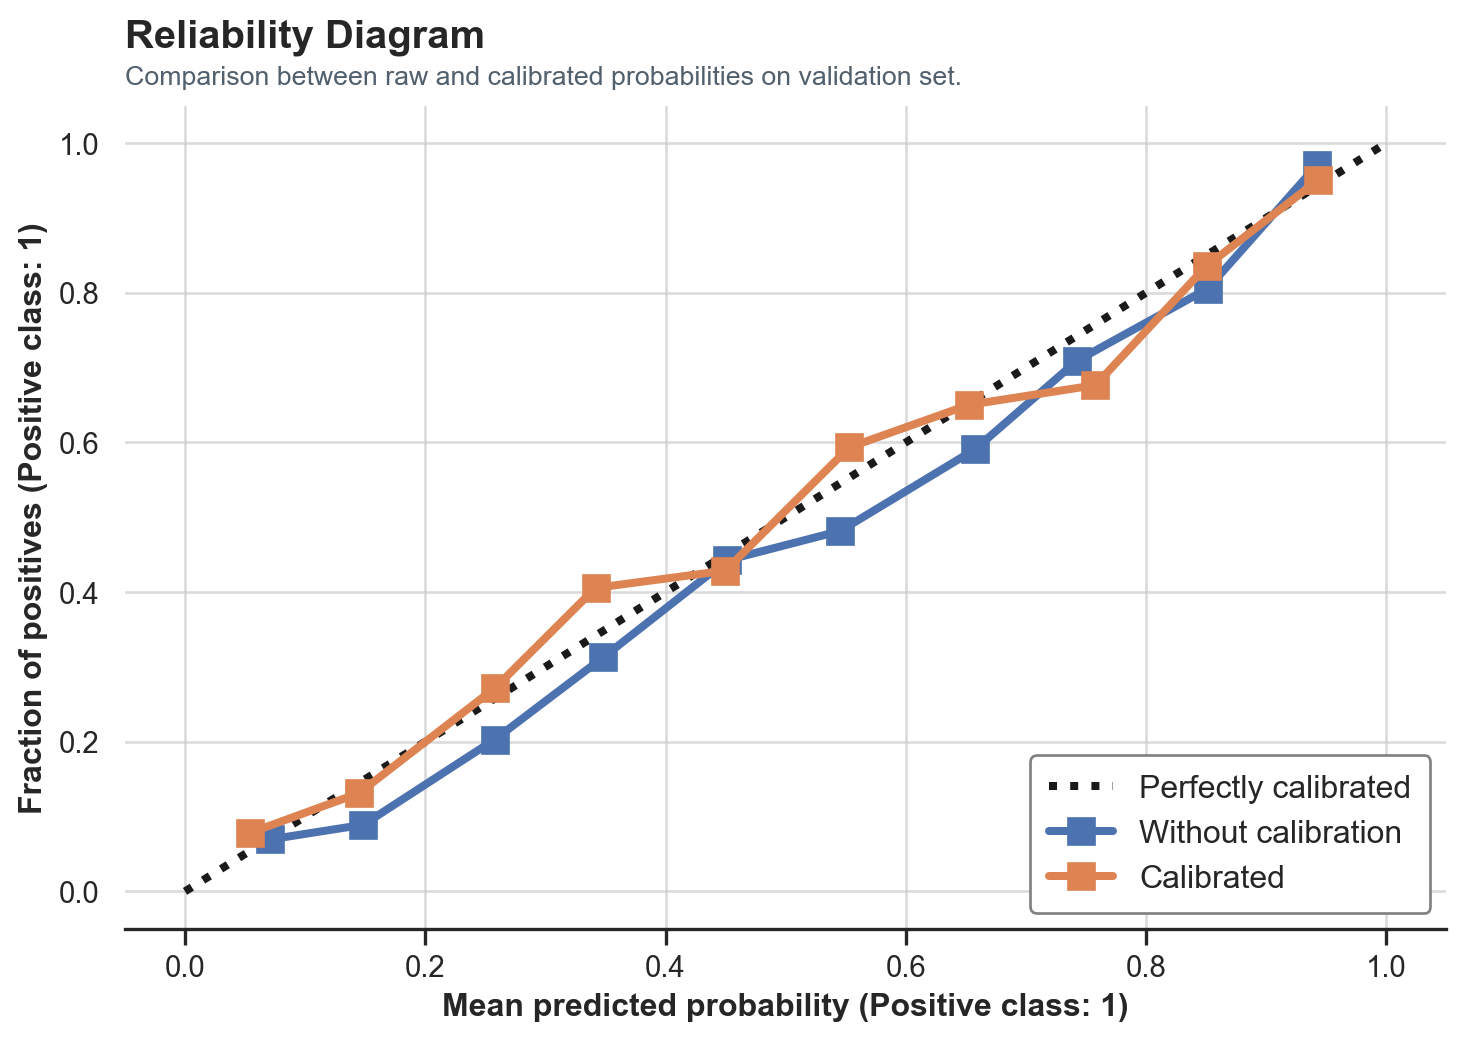

,Model,Sample,ROC_AUC,Recall,Precision,BrierScore
0,LogisticRegression without calibration,Hold-out,0.80,0.71,0.68,0.18
1,Calibrated LogisticRegression,Hold-out,0.80,0.64,0.72,0.18


,Cluster,Clientes,Recency_mean,Frequency_mean,Monetary_mean,AverageTicket_mean,UniqueProducts_mean,ReceitaTotal,PercentualReceita,PredictiveSegment
3,3,480,50.83,20.32,12159.10,554.49,218.43,5836370.05,67.52,Champions
1,1,783,117.50,6.27,1675.11,283.22,91.83,1311608.58,15.17,Loyal Customers
5,5,339,228.23,2.66,2706.62,991.84,62.25,917543.74,10.61,High Value at Risk
2,2,679,407.04,1.69,456.28,287.40,32.11,309814.41,3.58,Inactive Customers
0,0,545,106.64,2.15,421.96,218.49,23.17,229967.45,2.66,Occasional Buyers
4,4,315,390.84,1.28,122.90,101.51,7.01,38713.13,0.45,Low Value


,Customer ID,PredictiveSegment,repurchase_90d,prob_repurchase_90d_raw,prob_repurchase_90d,Recency,Frequency,Monetary,AverageTicket
348,12748,Champions,1,1.00,1.00,0,259,36987.41,142.81
2002,14606,Champions,1,1.00,1.00,3,170,28268.60,166.29
4879,17841,Champions,1,1.00,1.00,1,168,53394.36,317.82
633,13069,Champions,1,0.98,0.99,9,34,9121.71,268.29
3618,16422,Champions,1,1.00,0.99,9,97,58084.77,598.81
2038,14646,Champions,1,1.00,0.99,2,120,426699.12,3555.83
2055,14667,Champions,1,0.98,0.99,4,47,18756.96,399.08
1276,13798,Champions,1,0.99,0.99,2,95,67844.16,714.15
1932,14527,Champions,1,1.00,0.99,8,107,24564.90,229.58
4586,17511,Champions,1,0.99,0.98,3,50,143916.92,2878.34


In [52]:
numeric_predictors = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "QuantityTotal",
    "UniqueProducts",
]
categorical_predictors = ["CountryMode"]
model_features = numeric_predictors + categorical_predictors

# FIX P1: index reset ensures safe alignment after merges and filters.
predictive_features = predictive_features.reset_index(drop=True)
modeling_df = predictive_features[
    ["Customer ID", "repurchase_90d"] + model_features
].copy()
modeling_df = modeling_df.reset_index(drop=True)  # Index reset to ensure safe alignment with X_train.index after splits

X = modeling_df[model_features]
y = modeling_df["repurchase_90d"]
stratify_all = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

# FIX: independent hold-out separated before any train/validation split.
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X,
    y,
    test_size=HOLDOUT_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratify_all,
)
stratify_dev = y_dev if y_dev.nunique() == 2 and y_dev.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=stratify_dev,
)


class KMeansClusterAdder(BaseEstimator, TransformerMixin):
    """Adds `PredictiveCluster` by fitting K-Means only on the training set."""

    def __init__(
        self,
        cluster_features: list[str] | None = None,
        log_features: list[str] | None = None,
        n_clusters: int = N_CLUSTERS,
        random_state: int = 42,
        n_init: int = 20,
    ) -> None:
        self.cluster_features = cluster_features
        self.log_features = log_features
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "KMeansClusterAdder":
        # FIX: KMeans.fit runs only on X_train inside the Pipeline; validation and hold-out use predict.
        x_df = self._as_frame(X, fit=True)
        cluster_input = self._cluster_input(x_df)
        self.cluster_scaler_ = StandardScaler()
        scaled = self.cluster_scaler_.fit_transform(cluster_input)
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init,
        )
        self.kmeans_.fit(scaled)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        # FIX P1: fails explicitly if transform is called before fit.
        check_is_fitted(self, ["kmeans_", "cluster_scaler_"])
        x_df = self._as_frame(X, fit=False)
        cluster_input = self._cluster_input(x_df)
        scaled = self.cluster_scaler_.transform(cluster_input)
        x_out = x_df.copy()
        x_out["PredictiveCluster"] = self.kmeans_.predict(scaled).astype(str)
        return x_out

    def _as_frame(self, X: pd.DataFrame, fit: bool) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            if fit:
                self.feature_names_in_ = list(X.columns)
            return X.copy()
        return pd.DataFrame(X, columns=self.feature_names_in_)

    def _cluster_input(self, x_df: pd.DataFrame) -> pd.DataFrame:
        cluster_features = self.cluster_features or numeric_predictors
        log_cols = self.log_features or []
        cluster_input = x_df[cluster_features].copy()
        for col in log_cols:
            if col in cluster_input.columns:
                cluster_input[col] = np.log1p(cluster_input[col].clip(lower=0))
        return cluster_input


def make_one_hot_encoder() -> OneHotEncoder:
    """Creates encoder compatible with recent and older versions of scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor() -> Pipeline:
    """Assembles preprocessing with temporal cluster without leakage between splits."""
    cluster_step = KMeansClusterAdder(
        cluster_features=features,
        log_features=log_features,
        n_clusters=selected_k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    columns_step = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_predictors),
            (
                "categorical",
                make_one_hot_encoder(),
                ["CountryMode", "PredictiveCluster"],
            ),
        ]
    )
    return Pipeline([
        ("cluster", cluster_step),
        ("columns", columns_step),
    ])


def make_model_specs() -> dict[str, Any]:
    """Defines candidate models for supervised comparison."""
    return {
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoostingClassifier": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
    }


def make_repurchase_pipeline(estimator: Any) -> Pipeline:
    """Combines leakage-free preprocessing and supervised estimator."""
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", estimator),
    ])


def evaluate_classifier(
    model_name: str,
    dataset_name: str,
    estimator: Any,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
) -> dict[str, float | str]:
    """Calculates classification and calibration metrics for a sample."""
    y_prob = estimator.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    auc = roc_auc_score(y_eval, y_prob) if y_eval.nunique() == 2 else np.nan
    return {
        "Model": model_name,
        "Sample": dataset_name,
        "ROC_AUC": auc,
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_eval, y_pred),
        "BrierScore": brier_score_loss(y_eval, y_prob),
    }


fitted_models = {}
metric_rows = []
for model_name, estimator in make_model_specs().items():
    candidate_pipeline = make_repurchase_pipeline(estimator)
    candidate_pipeline.fit(X_train, y_train)
    metric_rows.append(
        evaluate_classifier(model_name, "Validation", candidate_pipeline, X_test, y_test)
    )
    fitted_models[model_name] = candidate_pipeline

model_metrics = pd.DataFrame(metric_rows).sort_values("ROC_AUC", ascending=False)
display(model_metrics.round(4))

baseline_model_name = "LogisticRegression"
baseline_pipeline = make_repurchase_pipeline(make_model_specs()[baseline_model_name])
baseline_pipeline.fit(X_train, y_train)

# FIX: isotonic calibration before using probabilities in financial calculations.
calibrated_repurchase_model = CalibratedClassifierCV(
    estimator=make_repurchase_pipeline(make_model_specs()[baseline_model_name]),
    method="isotonic",
    cv=5,
)
calibrated_repurchase_model.fit(X_train, y_train)

calibration_metrics = pd.DataFrame([
    evaluate_classifier(
        "LogisticRegression without calibration",
        "Validation",
        baseline_pipeline,
        X_test,
        y_test,
    ),
    evaluate_classifier(
        "Calibrated LogisticRegression",
        "Validation",
        calibrated_repurchase_model,
        X_test,
        y_test,
    ),
])
display(calibration_metrics[["Model", "Sample", "BrierScore"]].round(4))

fig, ax = plt.subplots(figsize=(7.8, 5.6))
CalibrationDisplay.from_estimator(
    baseline_pipeline,
    X_test,
    y_test,
    n_bins=10,
    ax=ax,
    name="Without calibration",
)
CalibrationDisplay.from_estimator(
    calibrated_repurchase_model,
    X_test,
    y_test,
    n_bins=10,
    ax=ax,
    name="Calibrated",
)
add_titles(
    ax,
    "Reliability Diagram",
    "Comparison between raw and calibrated probabilities on validation set.",
)
ax.grid(alpha=0.7)
plt.tight_layout()
plt.show()

holdout_metrics = pd.DataFrame([
    evaluate_classifier(
        "LogisticRegression without calibration",
        "Hold-out",
        baseline_pipeline,
        X_hold,
        y_hold,
    ),
    evaluate_classifier(
        "Calibrated LogisticRegression",
        "Hold-out",
        calibrated_repurchase_model,
        X_hold,
        y_hold,
    ),
])
display(
    holdout_metrics[[
        "Model",
        "Sample",
        "ROC_AUC",
        "Recall",
        "Precision",
        "BrierScore",
    ]].round(4)
)

cluster_segmenter = KMeansClusterAdder(
    cluster_features=features,
    log_features=log_features,
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
).fit(X_train)
train_clustered = cluster_segmenter.transform(X_train)
train_profile_base = predictive_features.loc[X_train.index].copy()
assert len(train_profile_base) == len(X_train), (
    f"Index misalignment: train_profile_base has {len(train_profile_base)} "
    f"rows, X_train has {len(X_train)}."
)
train_profile_base["PredictiveCluster"] = train_clustered[
    "PredictiveCluster"
].astype(int).to_numpy()

temporal_profile = train_profile_base.groupby("PredictiveCluster").agg(
    Clientes=("Customer ID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    AverageTicket_mean=("AverageTicket", "mean"),
    UniqueProducts_mean=("UniqueProducts", "mean"),
    ReceitaTotal=("Monetary", "sum"),
).reset_index().rename(columns={"PredictiveCluster": "Cluster"})
temporal_profile["PercentualReceita"] = (
    temporal_profile["ReceitaTotal"] / temporal_profile["ReceitaTotal"].sum() * 100
)

temporal_names = segment_names(temporal_profile)
validate_segment_names(temporal_profile, temporal_names)
temporal_profile["PredictiveSegment"] = temporal_profile["Cluster"].map(
    temporal_names
)

holdout_predictions = predictive_features.loc[X_hold.index].copy()
holdout_clustered = cluster_segmenter.transform(X_hold)
holdout_predictions["PredictiveCluster"] = holdout_clustered[
    "PredictiveCluster"
].astype(int).to_numpy()
holdout_predictions["PredictiveSegment"] = holdout_predictions[
    "PredictiveCluster"
].map(temporal_names)
holdout_predictions["prob_repurchase_90d_raw"] = baseline_pipeline.predict_proba(
    X_hold
)[:, 1]
# FIX: probabilities generated on hold-out to avoid overfitting in the simulation.
holdout_predictions["prob_repurchase_90d"] = calibrated_repurchase_model.predict_proba(
    X_hold
)[:, 1]

prediction_cols = [
    "prob_repurchase_90d_raw",
    "prob_repurchase_90d",
    "PredictiveCluster",
    "PredictiveSegment",
]
predictive_features = predictive_features.drop(
    columns=prediction_cols,
    errors="ignore",
).merge(
    holdout_predictions[["Customer ID"] + prediction_cols],
    on="Customer ID",
    how="left",
)

rfm_probability_cols = ["repurchase_90d"] + prediction_cols
rfm = rfm.drop(columns=rfm_probability_cols, errors="ignore").merge(
    predictive_features[["Customer ID"] + rfm_probability_cols],
    on="Customer ID",
    how="left",
)

display(temporal_profile.sort_values("ReceitaTotal", ascending=False))
display(
    holdout_predictions[[
        "Customer ID",
        "PredictiveSegment",
        "repurchase_90d",
        "prob_repurchase_90d_raw",
        "prob_repurchase_90d",
        "Recency",
        "Frequency",
        "Monetary",
        "AverageTicket",
    ]].sort_values("prob_repurchase_90d", ascending=False).head(10)
)


<span style="color:steelblue; text-align: left">

## Incentive Simulation and Expected Profit
</span>

The prescriptive layer evaluates possible actions `z`. Each action has an incentive cost, and the uplift now varies by temporal segment. This matrix is more realistic than a uniform uplift, since segments like `Champions`, `Inactive Customers` and `High Value at Risk` tend to react differently to campaigns.

The values remain business simulation hypotheses, not estimated causal effects. For each customer and action, the expected profit is calculated as: `expected_probability = min(prob_repurchase_90d + uplift, 1)`, `expected_revenue = expected_probability * AverageTicket` and `expected_profit = expected_revenue - incentive_cost`.


In [53]:
action_catalog = pd.DataFrame([
    {
        "Action": "No Action",
        "RecommendedAction": "Keep without incentive",
        "incentive_cost": 0.00,
    },
    {
        "Action": "Low Incentive",
        "RecommendedAction": "Light campaign",
        "incentive_cost": 2.00,
    },
    {
        "Action": "Medium Incentive",
        "RecommendedAction": "Medium campaign",
        "incentive_cost": 5.00,
    },
    {
        "Action": "High Incentive",
        "RecommendedAction": "Aggressive campaign",
        "incentive_cost": 10.00,
    },
])

# FIX: hypothetical uplift by segment — validate with A/B experiment in production.
uplift_matrix = pd.DataFrame([
    {
        "PredictiveSegment": "Champions",
        "No Action": 0.00,
        "Low Incentive": 0.02,
        "Medium Incentive": 0.04,
        "High Incentive": 0.05,
    },
    {
        "PredictiveSegment": "High Value at Risk",
        "No Action": 0.00,
        "Low Incentive": 0.04,
        "Medium Incentive": 0.09,
        "High Incentive": 0.15,
    },
    {
        "PredictiveSegment": "Loyal Customers",
        "No Action": 0.00,
        "Low Incentive": 0.03,
        "Medium Incentive": 0.07,
        "High Incentive": 0.10,
    },
    {
        "PredictiveSegment": "Occasional Buyers",
        "No Action": 0.00,
        "Low Incentive": 0.05,
        "Medium Incentive": 0.10,
        "High Incentive": 0.13,
    },
    {
        "PredictiveSegment": "Low Value",
        "No Action": 0.00,
        "Low Incentive": 0.02,
        "Medium Incentive": 0.04,
        "High Incentive": 0.05,
    },
    {
        "PredictiveSegment": "Inactive Customers",
        "No Action": 0.00,
        "Low Incentive": 0.01,
        "Medium Incentive": 0.03,
        "High Incentive": 0.04,
    },
])
uplift_long = uplift_matrix.melt(
    id_vars="PredictiveSegment",
    var_name="Action",
    value_name="uplift",
)
incentive_actions = uplift_long.merge(action_catalog, on="Action", how="left")

# The simulation uses only hold-out customers, i.e., data never seen by the model.
decision_base = holdout_predictions[[
    "Customer ID",
    "PredictiveCluster",
    "PredictiveSegment",
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "prob_repurchase_90d",
    "repurchase_90d",
]].copy()
decision_base["_key"] = 1
simulation_actions = action_catalog.copy()
simulation_actions["_key"] = 1

decision_simulation = decision_base.merge(
    simulation_actions,
    on="_key",
).drop(columns="_key")
# FIX: join by customer, segment and action to look up the correct uplift.
decision_simulation = decision_simulation.merge(
    uplift_long,
    on=["PredictiveSegment", "Action"],
    how="left",
)
missing_uplift = decision_simulation["uplift"].isna().sum()
if missing_uplift:
    warnings.warn(
        f"{missing_uplift} customer/segment/action combinations have no uplift.",
        stacklevel=2,
    )

decision_simulation["expected_probability"] = (
    decision_simulation["prob_repurchase_90d"] + decision_simulation["uplift"]
).clip(upper=1)
decision_simulation["expected_revenue"] = (
    decision_simulation["expected_probability"] * decision_simulation["AverageTicket"]
)
decision_simulation["expected_profit"] = (
    decision_simulation["expected_revenue"] - decision_simulation["incentive_cost"]
)

no_action_profit = decision_simulation.loc[
    decision_simulation["Action"] == "No Action",
    ["Customer ID", "expected_profit"],
].rename(columns={"expected_profit": "ExpectedProfit_NoAction"})

best_action_idx = decision_simulation.groupby("Customer ID")[
    "expected_profit"
].idxmax()
prescriptive_df = decision_simulation.loc[best_action_idx].copy()
prescriptive_df = prescriptive_df.merge(no_action_profit, on="Customer ID", how="left")
prescriptive_df = prescriptive_df.rename(columns={
    "Action": "BestAction",
    "expected_profit": "ExpectedProfit",
})
prescriptive_df["IncrementalProfit"] = (
    prescriptive_df["ExpectedProfit"]
    - prescriptive_df["ExpectedProfit_NoAction"]
)

display(
    incentive_actions[[
        "PredictiveSegment",
        "Action",
        "RecommendedAction",
        "incentive_cost",
        "uplift",
    ]].sort_values(["PredictiveSegment", "Action"])
)
display(
    decision_simulation[[
        "Customer ID",
        "PredictiveSegment",
        "Action",
        "prob_repurchase_90d",
        "uplift",
        "expected_probability",
        "AverageTicket",
        "incentive_cost",
        "expected_profit",
    ]].head(12)
)


,PredictiveSegment,Action,RecommendedAction,incentive_cost,uplift
18,Champions,High Incentive,Aggressive campaign,10.00,0.05
6,Champions,Low Incentive,Light campaign,2.00,0.02
12,Champions,Medium Incentive,Medium campaign,5.00,0.04
0,Champions,No Action,Keep without incentive,0.00,0.00
19,High Value at Risk,High Incentive,Aggressive campaign,10.00,0.15
7,High Value at Risk,Low Incentive,Light campaign,2.00,0.04
13,High Value at Risk,Medium Incentive,Medium campaign,5.00,0.09
1,High Value at Risk,No Action,Keep without incentive,0.00,0.00
23,Inactive Customers,High Incentive,Aggressive campaign,10.00,0.04
11,Inactive Customers,Low Incentive,Light campaign,2.00,0.01


,Customer ID,PredictiveSegment,Action,prob_repurchase_90d,uplift,expected_probability,AverageTicket,incentive_cost,expected_profit
0,14538,Loyal Customers,No Action,0.44,0.00,0.44,272.27,0.00,119.58
1,14538,Loyal Customers,Low Incentive,0.44,0.03,0.47,272.27,2.00,125.75
2,14538,Loyal Customers,Medium Incentive,0.44,0.07,0.51,272.27,5.00,133.64
3,14538,Loyal Customers,High Incentive,0.44,0.10,0.54,272.27,10.00,136.81
4,12836,Champions,No Action,0.87,0.00,0.87,434.66,0.00,377.92
5,12836,Champions,Low Incentive,0.87,0.02,0.89,434.66,2.00,384.61
6,12836,Champions,Medium Incentive,0.87,0.04,0.91,434.66,5.00,390.30
7,12836,Champions,High Incentive,0.87,0.05,0.92,434.66,10.00,389.65
8,16071,Inactive Customers,No Action,0.16,0.00,0.16,250.19,0.00,41.23
9,16071,Inactive Customers,Low Incentive,0.16,0.01,0.17,250.19,2.00,41.74


<span style="color:steelblue; text-align: left">

## Prescriptive Next Best Action Recommendation
</span>

The final decision tests all available actions for each customer and selects the one with the highest `ExpectedProfit`. The incremental gain compares the best action against `No Action`. Thus, the Next Best Action is no longer just a cluster rule but a decision based on expected profit.


In [54]:
def build_prescriptive_recommendation(row: pd.Series) -> str:
    """Translates the simulated optimal action into an executive business recommendation."""
    # FIX: main function with type hint and docstring for portfolio use.
    action_label = row["RecommendedAction"]
    segment = row["PredictiveSegment"]
    incremental = row["IncrementalProfit"]

    if row["BestAction"] == "No Action" or incremental <= 0:
        return f"{action_label}: preserve margin; incentive does not increase expected profit."
    if segment in ["Champions", "High Value at Risk"] and row["BestAction"] == "High Incentive":
        return "Maximum retention priority with aggressive campaign."
    if segment in ["Champions", "High Value at Risk"]:
        return f"Prioritize relationship with {action_label.lower()}."
    if segment == "Low Value" and row["BestAction"] == "High Incentive":
        return "Review cost before aggressive campaign for low-value customer."
    if segment == "Inactive Customers":
        return f"Test controlled reactivation with {action_label.lower()}."
    return f"Execute {action_label.lower()} based on positive expected profit."


prescriptive_df["PrescriptiveNextBestAction"] = prescriptive_df.apply(
    build_prescriptive_recommendation,
    axis=1,
)
prescriptive_df["ClusterSegment"] = (
    "C"
    + prescriptive_df["PredictiveCluster"].astype(str)
    + " - "
    + prescriptive_df["PredictiveSegment"]
)

prescriptive_cols = [
    "BestAction",
    "RecommendedAction",
    "ExpectedProfit",
    "ExpectedProfit_NoAction",
    "IncrementalProfit",
    "PrescriptiveNextBestAction",
]
rfm = rfm.drop(columns=prescriptive_cols, errors="ignore").merge(
    prescriptive_df[["Customer ID"] + prescriptive_cols],
    on="Customer ID",
    how="left",
)

action_summary = prescriptive_df.groupby(
    ["BestAction", "RecommendedAction"],
    as_index=False,
).agg(
    Clientes=("Customer ID", "count"),
    LucroEsperadoTotal=("ExpectedProfit", "sum"),
    LucroIncrementalTotal=("IncrementalProfit", "sum"),
    TicketMedio=("AverageTicket", "mean"),
    ProbabilidadeMediaRecompra=("prob_repurchase_90d", "mean"),
).sort_values("LucroIncrementalTotal", ascending=False)

cluster_action_summary = prescriptive_df.groupby(
    ["PredictiveCluster", "PredictiveSegment", "RecommendedAction"],
    as_index=False,
).agg(
    Clientes=("Customer ID", "count"),
    LucroEsperadoTotal=("ExpectedProfit", "sum"),
    LucroIncrementalTotal=("IncrementalProfit", "sum"),
    ProbabilidadeMediaRecompra=("prob_repurchase_90d", "mean"),
)

display(action_summary.round(4))
display(
    cluster_action_summary.sort_values(
        ["PredictiveCluster", "LucroIncrementalTotal"],
        ascending=[True, False],
    ).head(20).round(4)
)
display(
    prescriptive_df[[
        "Customer ID",
        "PredictiveSegment",
        "prob_repurchase_90d",
        "AverageTicket",
        "BestAction",
        "RecommendedAction",
        "ExpectedProfit",
        "ExpectedProfit_NoAction",
        "IncrementalProfit",
        "PrescriptiveNextBestAction",
    ]].sort_values("IncrementalProfit", ascending=False).head(10)
)


,BestAction,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,TicketMedio,ProbabilidadeMediaRecompra
0,High Incentive,Aggressive campaign,403,114445.95,19151.67,490.41,0.50
2,Medium Incentive,Medium campaign,311,34735.07,1708.29,257.50,0.40
1,Low Incentive,Light campaign,31,9302.76,128.41,384.79,0.33
3,No Action,Keep without incentive,48,1299.17,0.00,99.79,0.20


,PredictiveCluster,PredictiveSegment,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,ProbabilidadeMediaRecompra
0,0,Occasional Buyers,Aggressive campaign,97,13525.21,2652.33,0.39
1,0,Occasional Buyers,Medium campaign,59,3256.63,440.89,0.39
2,1,Loyal Customers,Aggressive campaign,165,30245.01,3125.60,0.57
3,1,Loyal Customers,Medium campaign,18,1595.51,81.10,0.62
6,2,Inactive Customers,Medium campaign,156,9310.71,571.85,0.19
4,2,Inactive Customers,Aggressive campaign,6,695.14,75.82,0.19
5,2,Inactive Customers,Keep without incentive,18,495.94,0.00,0.19
7,3,Champions,Aggressive campaign,37,27176.14,1202.39,0.82
10,3,Champions,Medium campaign,66,20313.54,574.55,0.87
9,3,Champions,Light campaign,8,8991.94,116.03,0.99


,Customer ID,PredictiveSegment,prob_repurchase_90d,AverageTicket,BestAction,RecommendedAction,ExpectedProfit,ExpectedProfit_NoAction,IncrementalProfit,PrescriptiveNextBestAction
158,13687,High Value at Risk,0.33,11880.84,High Incentive,Aggressive campaign,5644.12,3872.00,1772.13,Maximum retention priority with aggressive campaign.
24,12590,High Value at Risk,0.35,4932.13,High Incentive,Aggressive campaign,2462.10,1732.29,729.82,Maximum retention priority with aggressive campaign.
208,14063,High Value at Risk,0.17,2523.36,High Incentive,Aggressive campaign,804.66,436.16,368.50,Maximum retention priority with aggressive campaign.
65,12911,High Value at Risk,0.16,1680.47,High Incentive,Aggressive campaign,514.63,272.56,242.07,Maximum retention priority with aggressive campaign.
167,13734,High Value at Risk,0.15,1675.41,High Incentive,Aggressive campaign,490.73,249.42,241.31,Maximum retention priority with aggressive campaign.
377,15310,High Value at Risk,0.17,1634.64,High Incentive,Aggressive campaign,519.63,284.44,235.20,Maximum retention priority with aggressive campaign.
51,12798,High Value at Risk,0.34,1570.46,High Incentive,Aggressive campaign,759.51,533.94,225.57,Maximum retention priority with aggressive campaign.
67,12967,High Value at Risk,0.28,1435.64,High Incentive,Aggressive campaign,602.72,397.38,205.35,Maximum retention priority with aggressive campaign.
34,12653,High Value at Risk,0.53,1386.94,High Incentive,Aggressive campaign,930.76,732.72,198.04,Maximum retention priority with aggressive campaign.
327,14899,High Value at Risk,0.28,1384.88,High Incentive,Aggressive campaign,581.06,383.33,197.73,Maximum retention priority with aggressive campaign.


<span style="color:steelblue; text-align: left">

## Budget Allocation with Budget Constraint
</span>

The optimal decision per customer ignores the fact that the marketing budget is finite. In this step, the prescriptive recommendation is submitted to a `budget_total` and a greedy selection prioritizes customers with the highest expected incremental profit until the available budget is consumed.

This greedy allocation is a heuristic. For exact optimization with multiple constraints, segment limits, operational capacity or additional business rules, the next step would be to formulate the problem as Integer Linear Programming (ILP).


<span style="color:steelblue; text-align: left">

## Note on Budget Simulation Scope
</span>

The incentive simulation and budget allocation operate on the **hold-out set**
(approximately 15% of the total customer base), which is the subset for which
the model generated probabilities on data never seen during training.

This subset is a deliberate methodological choice: using the hold-out ensures that
the expected profits are not inflated by overfitting. In production, the calibrated
model would be applied to **the entire active customer base**, and the budget simulation
would cover all eligible customers.

To scale the results to the full base, multiply the values by
`1 / HOLDOUT_FRACTION`, where `HOLDOUT_FRACTION = 0.15`.


,Metric,Valor
0,Simulation scope,Hold-out set (≈15% of base)
1,Fraction of total base,793 of 5281 customers with features
2,Total budget,"10.000,00"
3,Budget used,"5.647,00"
4,Remaining budget,"4.353,00"
5,Customers served,745
6,Expected incremental profit,"20.988,37"


,PredictiveSegment,ClientesAtendidos,CustoTotal,LucroIncrementalEsperadoTotal,ROIEstimado
1,High Value at Risk,98,980.00,12095.52,12.34
4,Loyal Customers,183,1740.00,3206.70,1.84
5,Occasional Buyers,156,1265.00,3093.23,2.45
0,Champions,111,716.00,1892.97,2.64
2,Inactive Customers,162,840.00,647.67,0.77
3,Low Value,35,106.00,52.28,0.49


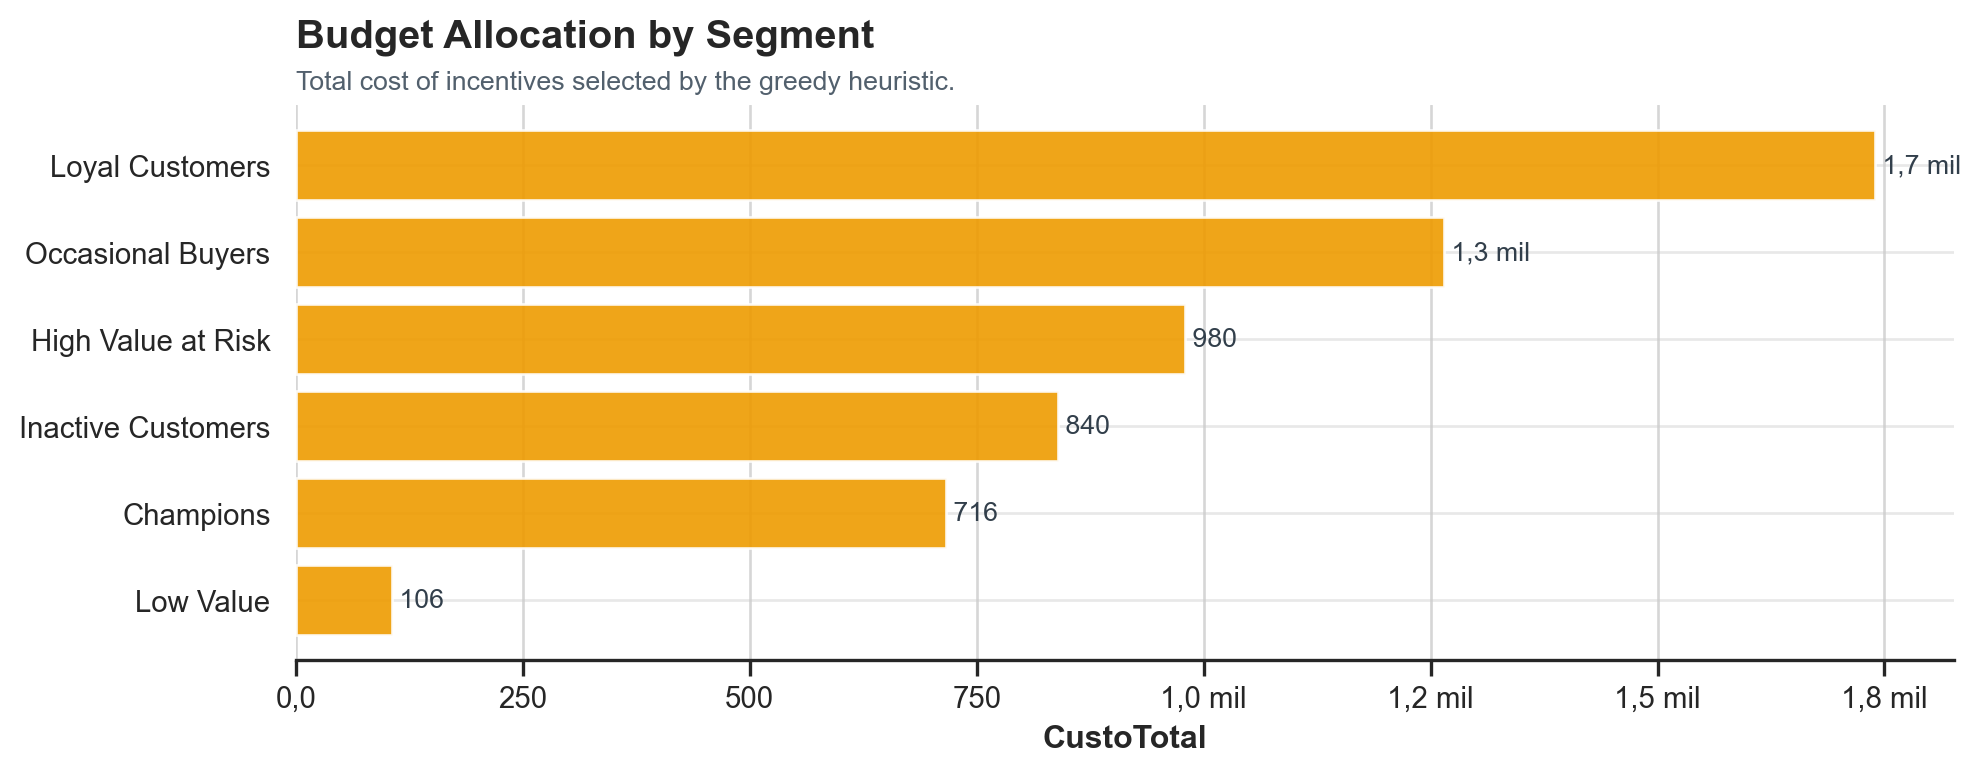

In [55]:
# FIX P4: budget parameterized in the configuration cell.
budget_total = BUDGET_TOTAL

# FIX: greedy allocation is a heuristic — for exact optimization, use ILP.
budget_candidates = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action")
    & (prescriptive_df["IncrementalProfit"] > 0)
    & (prescriptive_df["incentive_cost"] > 0)
].copy()
budget_candidates["ExpectedROI"] = np.where(
    budget_candidates["incentive_cost"] > 0,
    budget_candidates["IncrementalProfit"] / budget_candidates["incentive_cost"],
    0.0,
)
budget_candidates = budget_candidates.sort_values(
    "IncrementalProfit",
    ascending=False,
).copy()

remaining_budget = budget_total
selected_indices = []
for idx, row in budget_candidates.iterrows():
    cost = row["incentive_cost"]
    if cost <= remaining_budget:
        selected_indices.append(idx)
        remaining_budget -= cost

budget_selected = budget_candidates.loc[selected_indices].copy()
if budget_selected.empty:
    budget_segment_summary = pd.DataFrame(columns=[
        "PredictiveSegment",
        "ClientesAtendidos",
        "CustoTotal",
        "LucroIncrementalEsperadoTotal",
        "ROIEstimado",
    ])
else:
    budget_segment_summary = budget_selected.groupby(
        "PredictiveSegment",
        as_index=False,
    ).agg(
        ClientesAtendidos=("Customer ID", "count"),
        CustoTotal=("incentive_cost", "sum"),
        LucroIncrementalEsperadoTotal=("IncrementalProfit", "sum"),
    )
    budget_segment_summary["ROIEstimado"] = np.where(
        budget_segment_summary["CustoTotal"] > 0,
        budget_segment_summary["LucroIncrementalEsperadoTotal"]
        / budget_segment_summary["CustoTotal"],
        0.0,
    )
    budget_segment_summary = budget_segment_summary.sort_values(
        "LucroIncrementalEsperadoTotal",
        ascending=False,
    )

# FIX P2: explicit scope avoids misinterpretation of results.
budget_overview = pd.DataFrame({
    "Metric": [
        "Simulation scope",
        "Fraction of total base",
        "Total budget",
        "Budget used",
        "Remaining budget",
        "Customers served",
        "Expected incremental profit",
    ],
    "Valor": [
        "Hold-out set (≈15% of base)",
        f"{len(prescriptive_df)} of {len(predictive_features)} customers with features",
        fmt(budget_total, 2),
        fmt(budget_selected["incentive_cost"].sum(), 2),
        fmt(remaining_budget, 2),
        fmt(len(budget_selected)),
        fmt(budget_selected["IncrementalProfit"].sum(), 2),
    ],
})

display(budget_overview)
display(budget_segment_summary.round(4))

if not budget_segment_summary.empty:
    barh(
        budget_segment_summary.sort_values("CustoTotal"),
        "PredictiveSegment",
        "CustoTotal",
        "Budget Allocation by Segment",
        "Total cost of incentives selected by the greedy heuristic.",
        PALETTE[3],
    )


<span style="color:steelblue; text-align: left">

## Prescriptive Layer Visualizations
</span>

The visualizations below connect calibrated repurchase probability, temporal segment, recommended action and incremental profit. The reading should separate two things: the probability comes from the supervised model calibrated on the hold-out; the incremental gain comes from the incentive simulation and depends directly on the uplift and cost hypotheses.


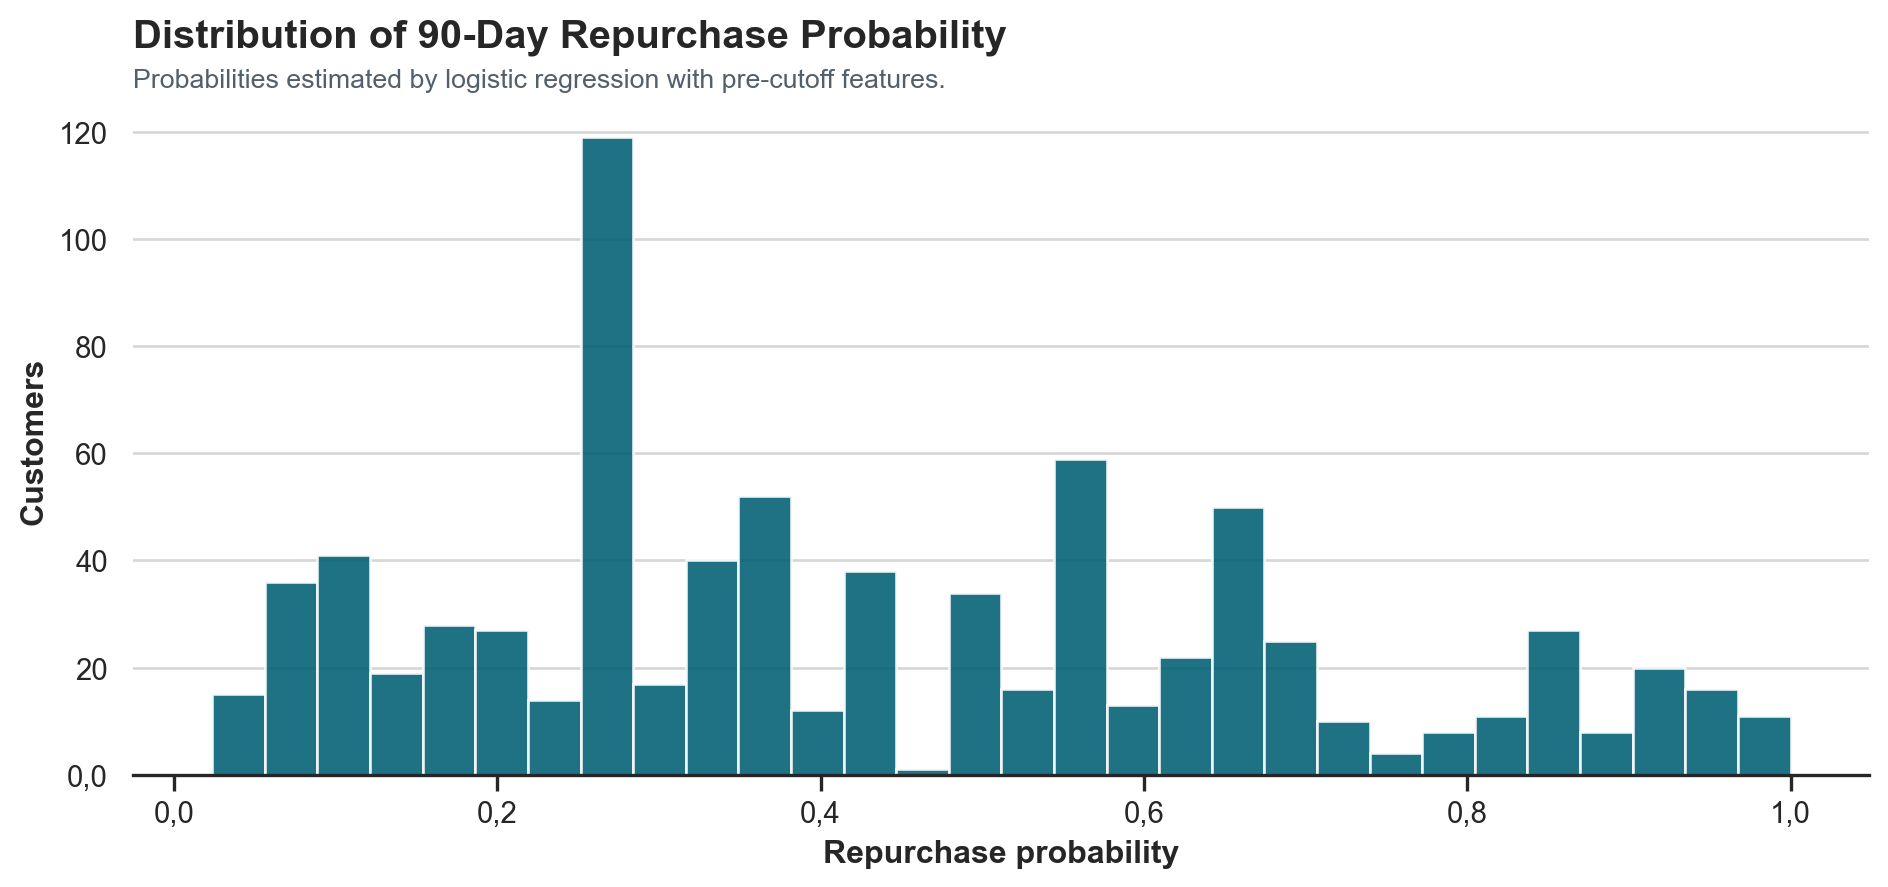

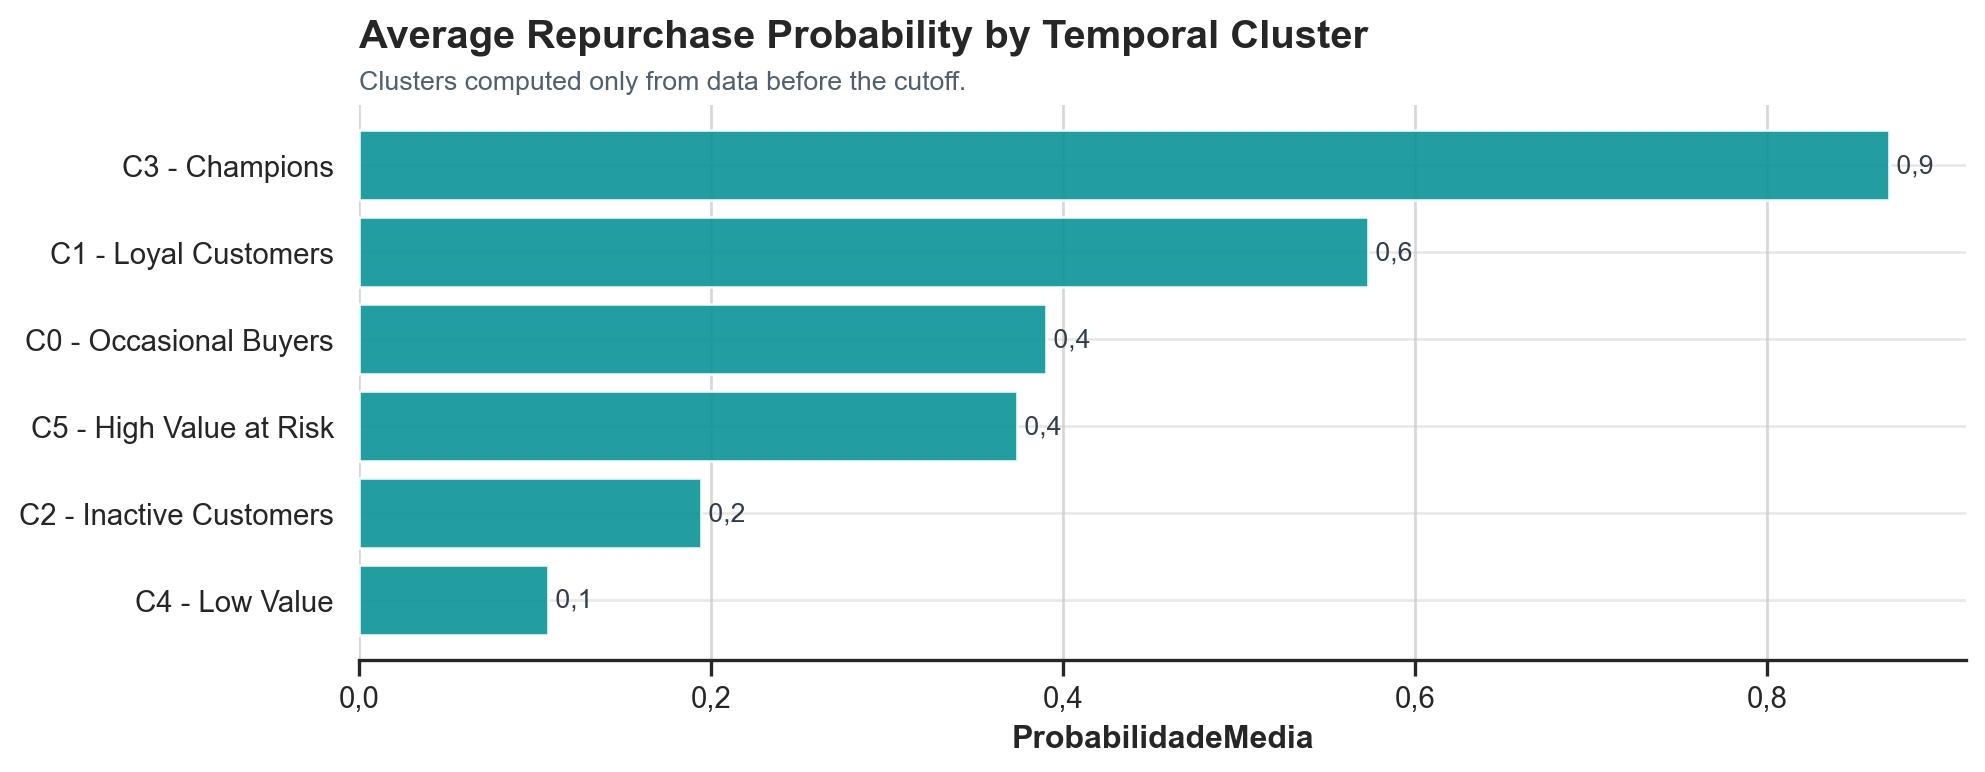

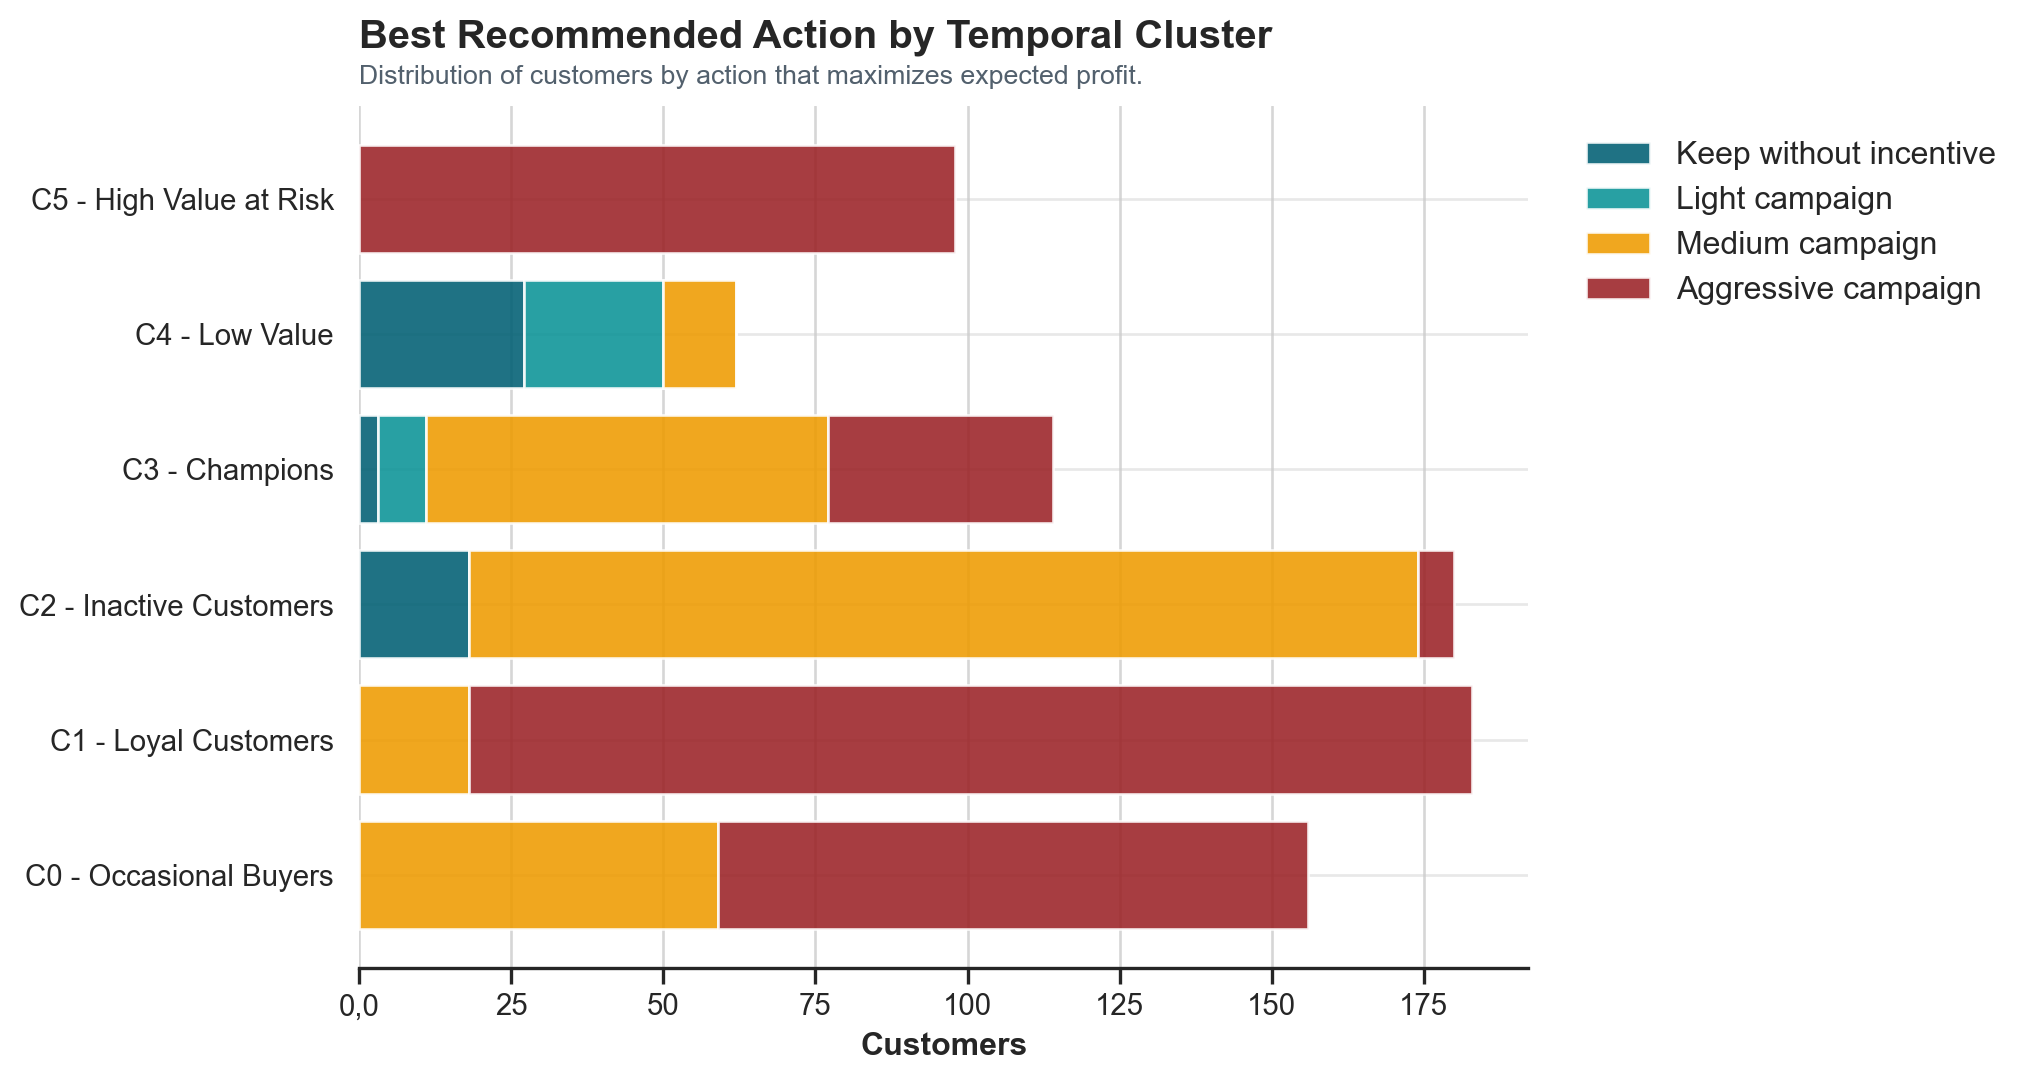

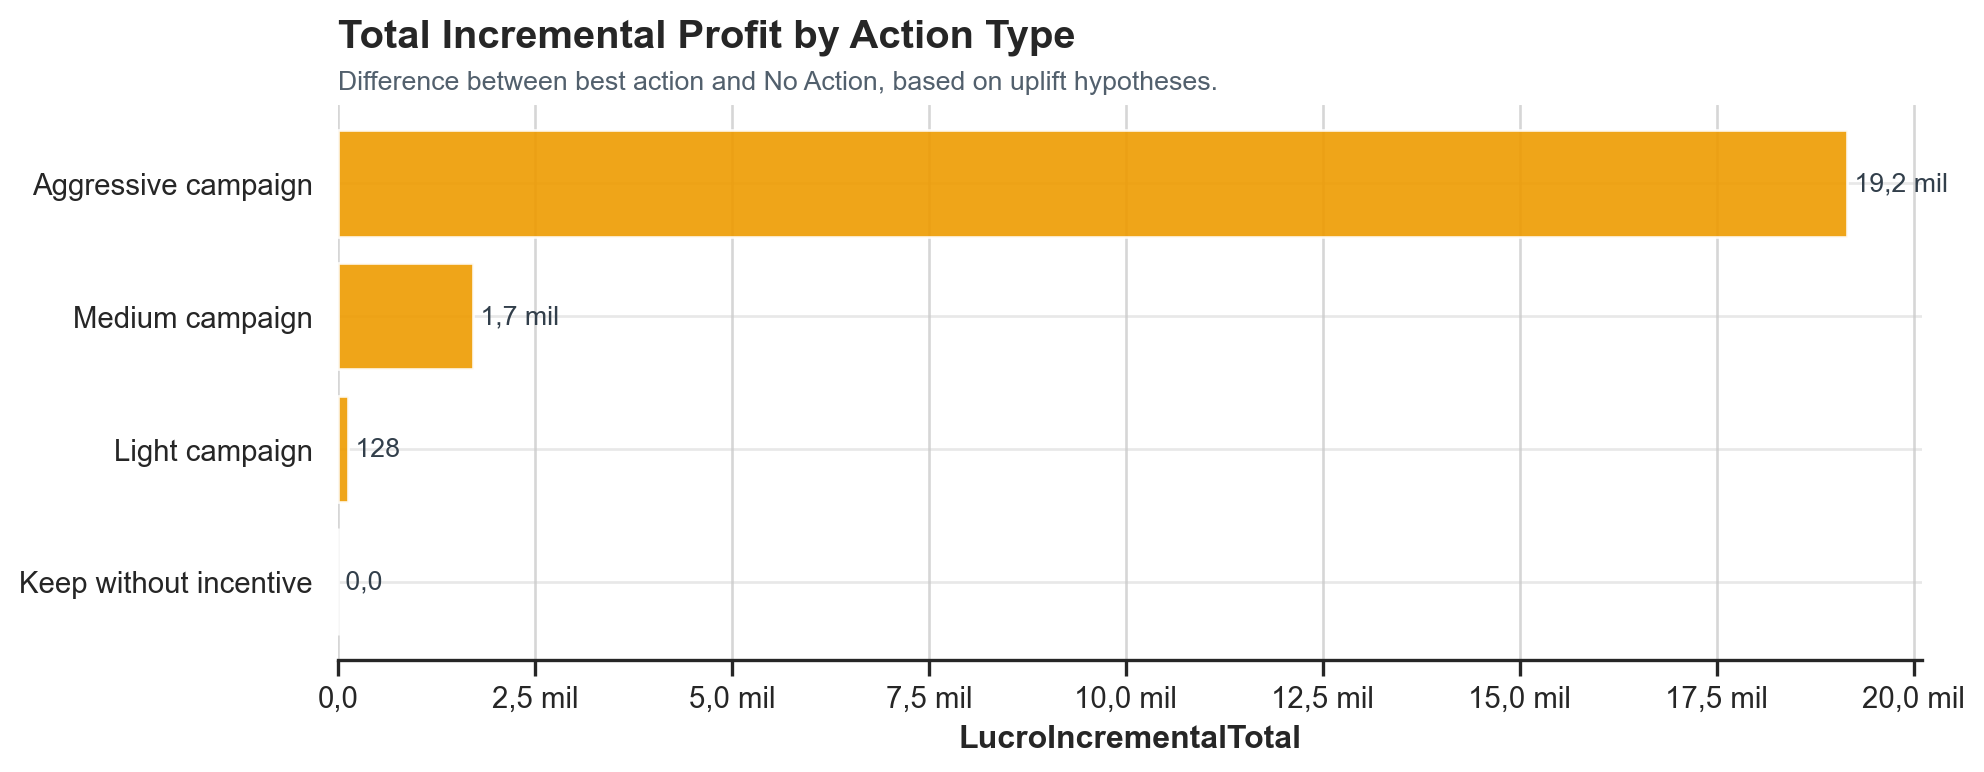

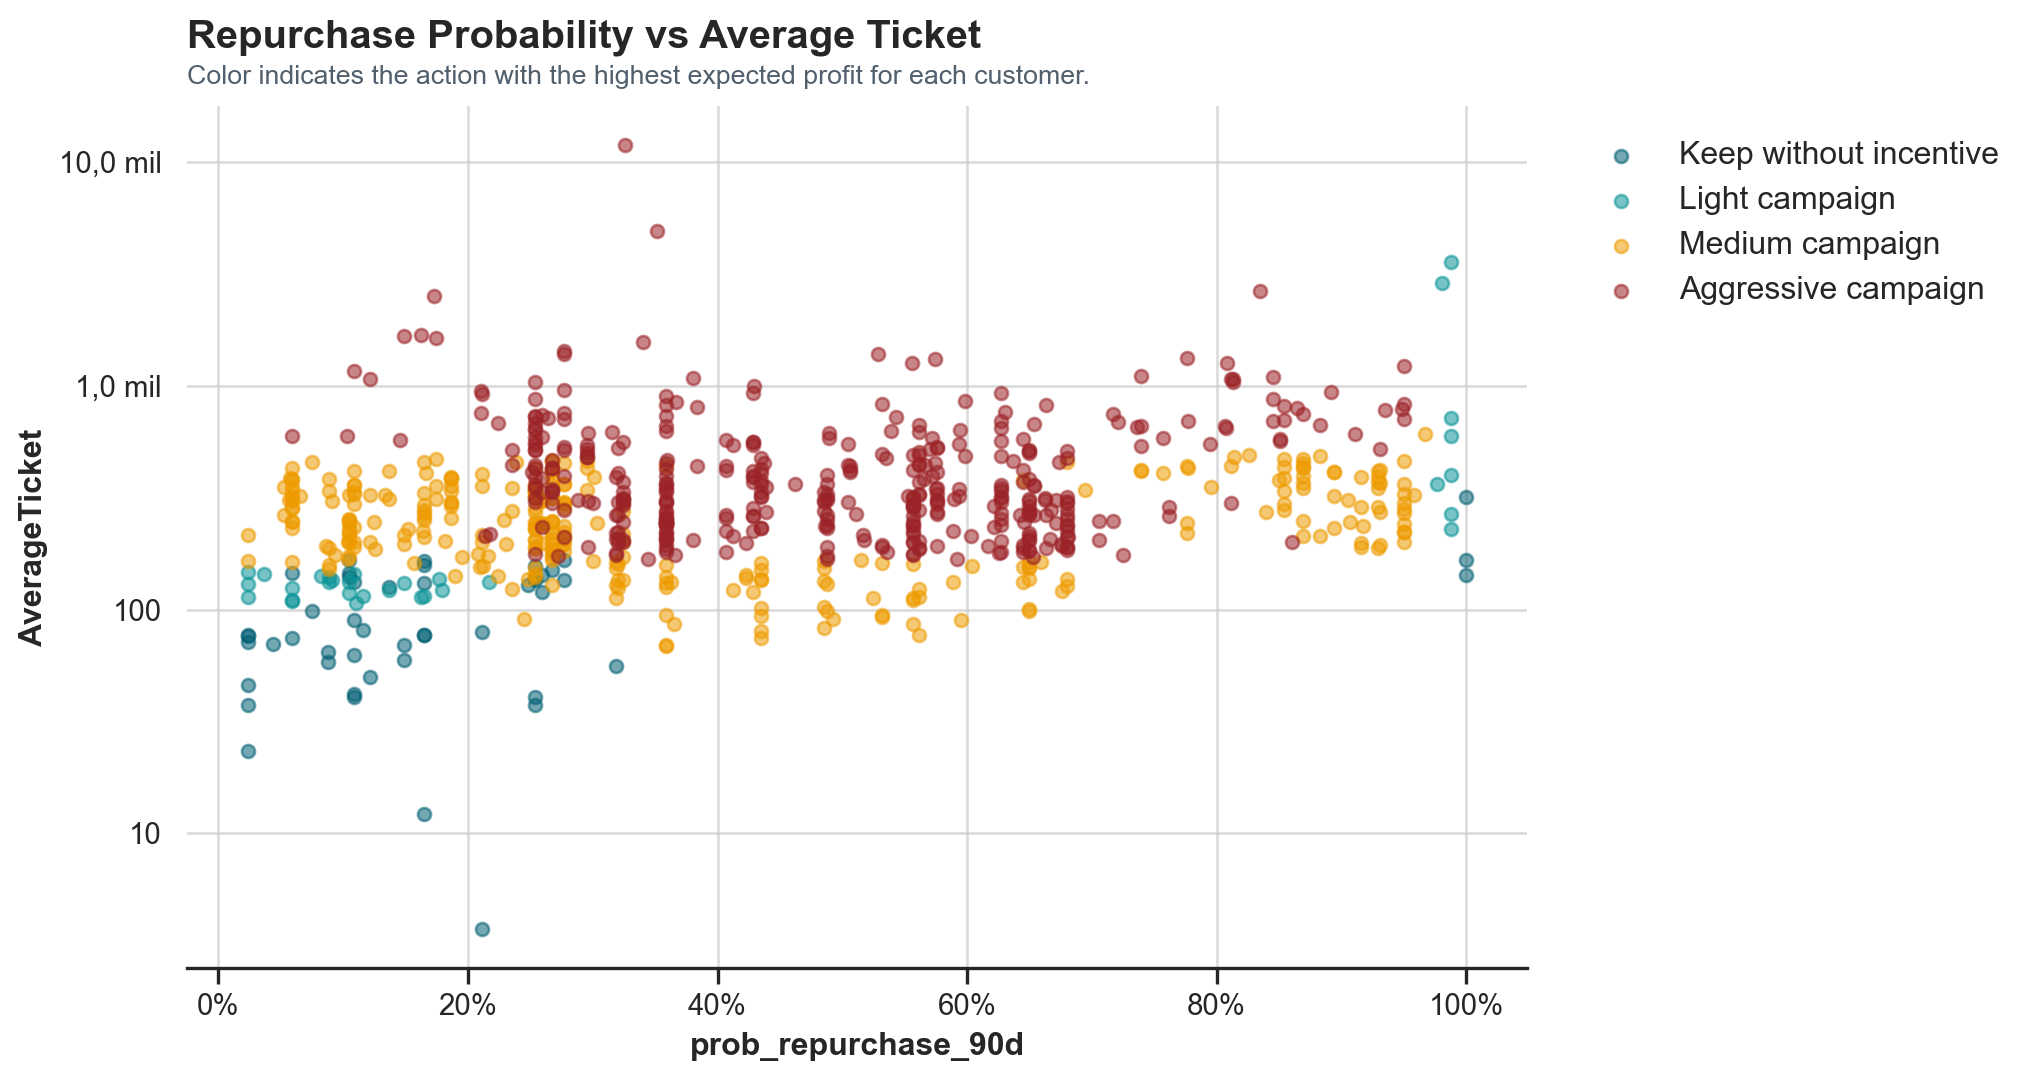

,BestAction,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,TicketMedio,ProbabilidadeMediaRecompra
0,High Incentive,Aggressive campaign,403,114445.95,19151.67,490.41,0.50
2,Medium Incentive,Medium campaign,311,34735.07,1708.29,257.50,0.40
1,Low Incentive,Light campaign,31,9302.76,128.41,384.79,0.33
3,No Action,Keep without incentive,48,1299.17,0.00,99.79,0.20


In [56]:
action_order = [
    "Keep without incentive",
    "Light campaign",
    "Medium campaign",
    "Aggressive campaign",
]
action_palette = {
    "Keep without incentive": PALETTE[0],
    "Light campaign": PALETTE[1],
    "Medium campaign": PALETTE[3],
    "Aggressive campaign": PALETTE[5],
}

hist(
    prescriptive_df["prob_repurchase_90d"],
    "Distribution of 90-Day Repurchase Probability",
    "Probabilities estimated by logistic regression with pre-cutoff features.",
    "Repurchase probability",
    PALETTE[0],
    bins=30,
)

prob_by_cluster = prescriptive_df.groupby(
    ["PredictiveCluster", "PredictiveSegment"],
    as_index=False,
).agg(
    ProbabilidadeMedia=("prob_repurchase_90d", "mean"),
    Clientes=("Customer ID", "count"),
)
prob_by_cluster["ClusterSegment"] = (
    "C"
    + prob_by_cluster["PredictiveCluster"].astype(str)
    + " - "
    + prob_by_cluster["PredictiveSegment"]
)
barh(
    prob_by_cluster.sort_values("ProbabilidadeMedia"),
    "ClusterSegment",
    "ProbabilidadeMedia",
    "Average Repurchase Probability by Temporal Cluster",
    "Clusters computed only from data before the cutoff.",
    PALETTE[1],
)

cluster_action_counts = pd.crosstab(
    prescriptive_df["ClusterSegment"],
    prescriptive_df["RecommendedAction"],
)
cluster_order = prob_by_cluster.sort_values("PredictiveCluster")[
    "ClusterSegment"
].tolist()
cluster_action_counts = cluster_action_counts.reindex(cluster_order).fillna(0)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
left = np.zeros(len(cluster_action_counts))
for action in action_order:
    if action not in cluster_action_counts.columns:
        continue
    values = cluster_action_counts[action].to_numpy()
    ax.barh(
        cluster_action_counts.index,
        values,
        left=left,
        color=action_palette[action],
        alpha=0.88,
        label=action,
    )
    left += values
add_titles(
    ax,
    "Best Recommended Action by Temporal Cluster",
    "Distribution of customers by action that maximizes expected profit.",
)
ax.set_xlabel("Customers")
ax.grid(axis="x", alpha=0.8)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
set_compact_axis(ax, "x")
plt.tight_layout()
plt.show()

barh(
    action_summary.sort_values("LucroIncrementalTotal"),
    "RecommendedAction",
    "LucroIncrementalTotal",
    "Total Incremental Profit by Action Type",
    "Difference between best action and No Action, based on uplift hypotheses.",
    PALETTE[3],
)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
for action in action_order:
    group = prescriptive_df.loc[prescriptive_df["RecommendedAction"] == action]
    if group.empty:
        continue
    ax.scatter(
        group["prob_repurchase_90d"],
        group["AverageTicket"],
        s=24,
        alpha=0.55,
        color=action_palette[action],
        label=action,
    )
add_titles(
    ax,
    "Repurchase Probability vs Average Ticket",
    "Color indicates the action with the highest expected profit for each customer.",
)
ax.set_xlabel("prob_repurchase_90d")
ax.set_ylabel("AverageTicket")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
set_compact_axis(ax, "y")
ax.grid(alpha=0.7)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(action_summary.round(4))


<span style="color:steelblue; text-align: left">

## Profit Function with Real Margin
</span>

The previous version optimized expected revenue. This section replaces `AverageTicket`
with `AverageTicket × MARGIN_RATE`, bringing the model closer to a real profit
objective function. In production, `MARGIN_RATE` should come from product accounting —
it can vary by category, channel or seasonality.

The comparison table shows how many customers would have a different action with the
corrected function. This delta is the cost of ignoring margin.


,Métrica,Valor
0,Customers evaluated,793.00
1,Customers with changed action,618.00
2,Percentage with changed action,77.93


,customer_id,best_action (revenue),expected_profit,best_action (margin),best_margin_profit,action changed?
0,12347,High Incentive,518.68,Medium Incentive,177.64,True
354,15169,Medium Incentive,82.32,No Action,27.57,True
505,16250,High Incentive,108.39,Medium Incentive,33.67,True
507,16258,High Incentive,678.28,Medium Incentive,233.28,True
508,16266,Medium Incentive,90.64,No Action,30.35,True
509,16273,Medium Incentive,17.45,No Action,6.09,True
510,16278,High Incentive,267.53,Medium Incentive,88.22,True
512,16284,Medium Incentive,56.27,No Action,19.28,True
513,16289,Low Incentive,24.84,No Action,8.44,True
515,16296,Medium Incentive,40.63,No Action,12.52,True


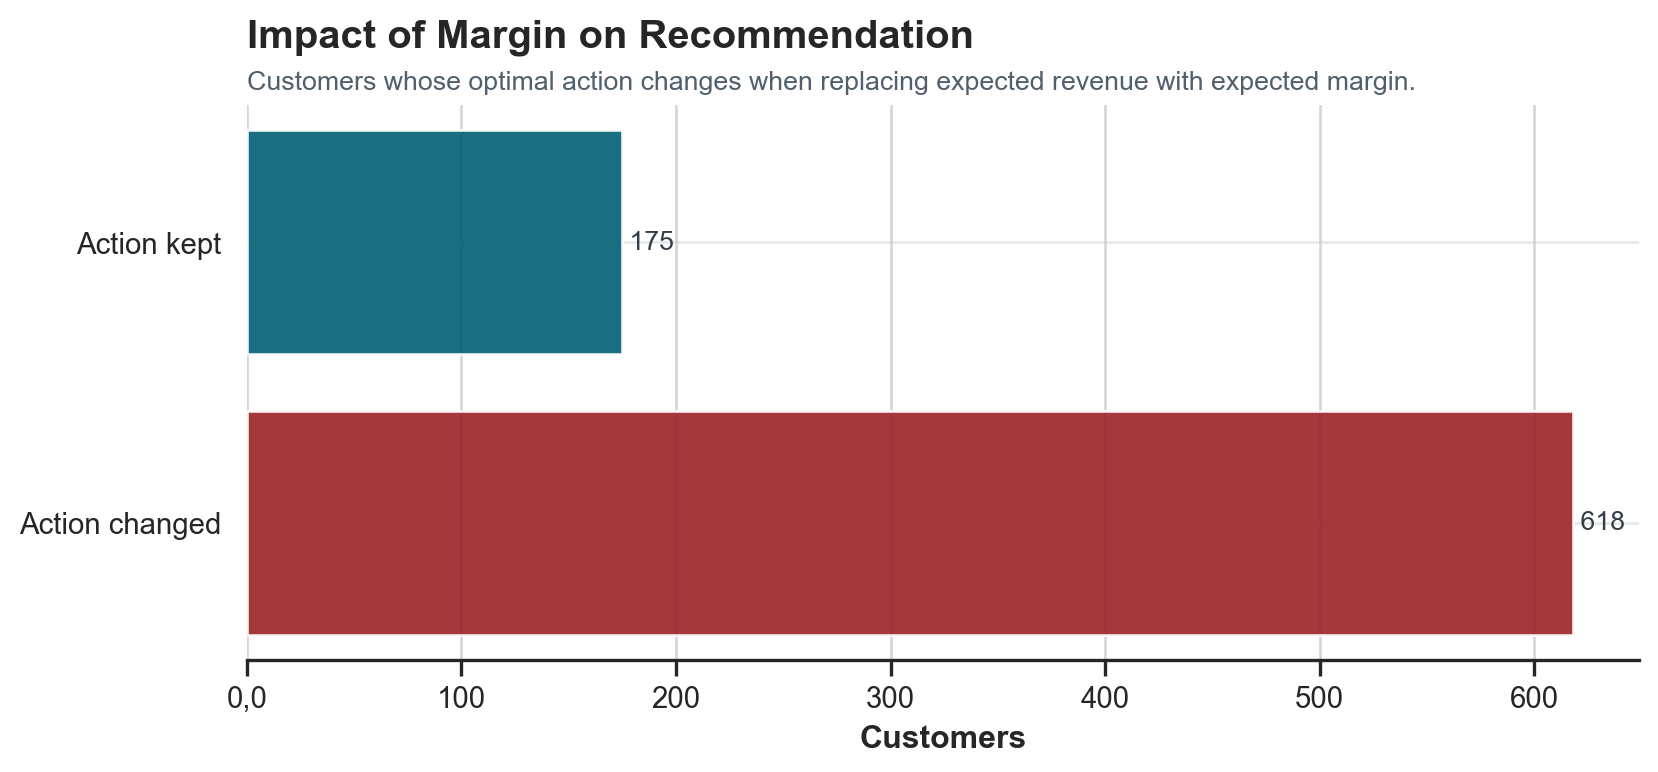

In [58]:
# INCREMENT 1: replace gross revenue with expected margin in the objective function.
# This changes what we are optimizing: from revenue to real profit.
decision_simulation["expected_margin"] = (
    decision_simulation["expected_probability"]
    * decision_simulation["AverageTicket"]
    * MARGIN_RATE
)
decision_simulation["expected_profit_margin"] = (
    decision_simulation["expected_margin"] - decision_simulation["incentive_cost"]
)

margin_no_action_profit = decision_simulation.loc[
    decision_simulation["Action"] == "No Action",
    ["Customer ID", "expected_profit_margin"],
].rename(columns={"expected_profit_margin": "ExpectedMarginProfit_NoAction"})

# Recalculate best action based on margin (not revenue).
best_action_margin_idx = decision_simulation.groupby("Customer ID")[
    "expected_profit_margin"
].idxmax()
prescriptive_margin_df = decision_simulation.loc[best_action_margin_idx].copy()
prescriptive_margin_df = prescriptive_margin_df.merge(
    margin_no_action_profit,
    on="Customer ID",
    how="left",
)
prescriptive_margin_df = prescriptive_margin_df.rename(
    columns={
        "Action": "BestActionMargin",
        "RecommendedAction": "RecommendedActionMargin",
        "expected_profit_margin": "BestMarginProfit",
    }
)
prescriptive_margin_df["IncrementalMarginProfit"] = (
    prescriptive_margin_df["BestMarginProfit"]
    - prescriptive_margin_df["ExpectedMarginProfit_NoAction"]
)

margin_action_comparison = prescriptive_df[[
    "Customer ID",
    "BestAction",
    "ExpectedProfit",
]].merge(
    prescriptive_margin_df[[
        "Customer ID",
        "BestActionMargin",
        "BestMarginProfit",
    ]],
    on="Customer ID",
    how="left",
).rename(columns={
    "Customer ID": "customer_id",
    "BestAction": "best_action (revenue)",
    "ExpectedProfit": "expected_profit",
    "BestActionMargin": "best_action (margin)",
    "BestMarginProfit": "best_margin_profit",
})
margin_action_comparison["action changed?"] = (
    margin_action_comparison["best_action (revenue)"]
    != margin_action_comparison["best_action (margin)"]
)

margin_decision_summary = pd.DataFrame({
    "Métrica": [
        "Customers evaluated",
        "Customers with changed action",
        "Percentage with changed action",
    ],
    "Valor": [
        len(margin_action_comparison),
        int(margin_action_comparison["action changed?"].sum()),
        margin_action_comparison["action changed?"].mean() * 100,
    ],
})

display(margin_decision_summary.round(2))
display(
    margin_action_comparison.sort_values(
        "action changed?",
        ascending=False,
    ).head(12).round(2)
)

margin_change_counts = (
    margin_action_comparison["action changed?"]
    .map({False: "Action kept", True: "Action changed"})
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Customers")
)
fig, ax = plt.subplots(figsize=(8.8, 4.2))
colors = margin_change_counts["Status"].map({
    "Action kept": PALETTE[0],
    "Action changed": PALETTE[5],
})
ax.barh(
    margin_change_counts["Status"],
    margin_change_counts["Customers"],
    color=colors,
    alpha=0.9,
)
add_titles(
    ax,
    "Impact of Margin on Recommendation",
    "Customers whose optimal action changes when replacing expected revenue with expected margin.",
)
ax.set_xlabel("Customers")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
for idx, value in enumerate(margin_change_counts["Customers"]):
    ax.text(value, idx, f" {compact(value)}", va="center", fontsize=10, color="#323F4B")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Scenario Analysis: Baseline vs Model vs Prescription
</span>

Three scenarios are compared on the same hold-out:

- **Scenario A** — no incentive: expected profit without any intervention.
- **Scenario B** — uniform campaign: same average incentive for all customers,
  without personalization.
- **Scenario C** — individual prescription: optimal action per customer based on the model.

The difference between C and A is the value of the model. The difference between C and B is the value
of personalization. These two numbers are the central arguments for any
executive presentation or investment justification in analytics.


,Scenario,TotalProfit,TotalCost,GainVsBaseline,ROI
0,A — No action,48578.10,0.00,0.00,NaN
1,B — Uniform campaign,51579.74,3965.00,3001.64,0.76
2,C — Prescription per customer,53385.39,2603.00,4807.28,1.85


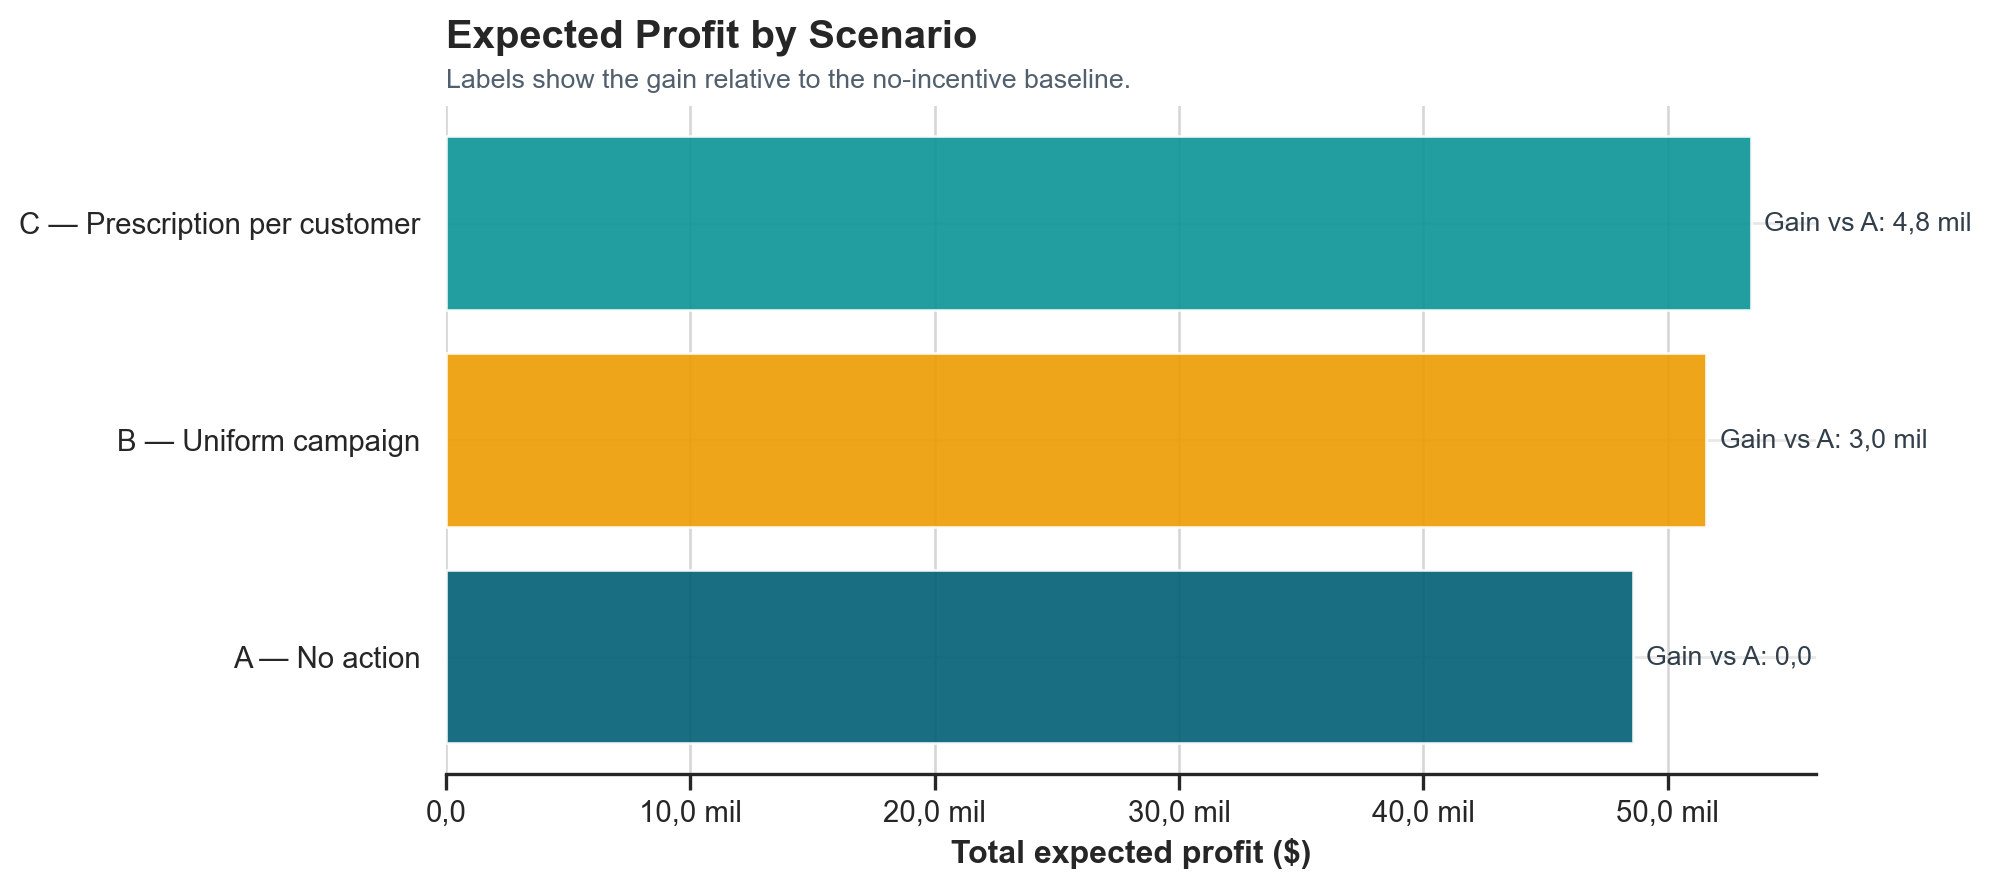

In [60]:
# INCREMENT 2: scenario comparison to justify model ROI.

# ── Scenario A: no model — no incentive for anyone ────────────────────
scenario_a = prescriptive_df.copy()
scenario_a["scenario"] = "A — No action"
scenario_a["scenario_profit"] = (
    scenario_a["prob_repurchase_90d"] * scenario_a["AverageTicket"] * MARGIN_RATE
)
scenario_a["scenario_cost"] = 0.0

# ── Scenario B: no model — uniform campaign for all (Medium Incentive) ──
scenario_b = prescriptive_df.copy()
scenario_b["scenario"] = "B — Uniform campaign (medium)"
scenario_b["scenario_prob"] = (
    scenario_b["prob_repurchase_90d"] + UNIFORM_UPLIFT
).clip(upper=1)
scenario_b["scenario_profit"] = (
    scenario_b["scenario_prob"] * scenario_b["AverageTicket"] * MARGIN_RATE
    - UNIFORM_COST
)
scenario_b["scenario_cost"] = UNIFORM_COST

# ── Scenario C: with prescription — optimal action per customer ───────────────────────
scenario_c = prescriptive_margin_df.copy()
scenario_c["scenario"] = "C — Prescription per customer"
scenario_c["scenario_profit"] = scenario_c["BestMarginProfit"]
scenario_c["scenario_cost"] = scenario_c["incentive_cost"]

# ── Consolidation ──────────────────────────────────────────────────────────────
scenario_summary = pd.DataFrame({
    "Scenario": [
        "A — No action",
        "B — Uniform campaign",
        "C — Prescription per customer",
    ],
    "TotalProfit": [
        scenario_a["scenario_profit"].sum(),
        scenario_b["scenario_profit"].sum(),
        scenario_c["scenario_profit"].sum(),
    ],
    "TotalCost": [
        scenario_a["scenario_cost"].sum(),
        scenario_b["scenario_cost"].sum(),
        scenario_c["scenario_cost"].sum(),
    ],
})
scenario_summary["GainVsBaseline"] = (
    scenario_summary["TotalProfit"] - scenario_summary.loc[0, "TotalProfit"]
)
scenario_summary["ROI"] = np.where(
    scenario_summary["TotalCost"] > 0,
    scenario_summary["GainVsBaseline"] / scenario_summary["TotalCost"],
    np.nan,
)

display(scenario_summary.round(2))

scenario_plot = scenario_summary.sort_values("TotalProfit").reset_index(drop=True)
scenario_colors = scenario_plot["Scenario"].map({
    "A — No action": PALETTE[0],
    "B — Uniform campaign": PALETTE[3],
    "C — Prescription per customer": PALETTE[1],
})

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.barh(
    scenario_plot["Scenario"],
    scenario_plot["TotalProfit"],
    color=scenario_colors,
    alpha=0.9,
)
add_titles(
    ax,
    "Expected Profit by Scenario",
    "Labels show the gain relative to the no-incentive baseline.",
)
ax.set_xlabel("Total expected profit ($)")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
offset = max(scenario_plot["TotalProfit"].abs().max() * 0.01, 1)
for idx, row in scenario_plot.iterrows():
    value = row["TotalProfit"]
    gain = row["GainVsBaseline"]
    x_pos = value + offset if value >= 0 else value - offset
    ha = "left" if value >= 0 else "right"
    ax.text(
        x_pos,
        idx,
        f"Gain vs A: {compact(gain)}",
        va="center",
        ha=ha,
        fontsize=10,
        color="#323F4B",
    )
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Sensitivity to Model Error
</span>

Predictive models are not perfect. This section simulates what happens to the
total expected profit when the real probabilities differ from the estimated ones by
up to ±15 percentage points.

A robust model should be profitable even under realistic perturbations. If the
expected profit enters negative territory with a shift of only -5pp,
the incentive policy is too fragile for production.

This analysis is the bridge between modeling and risk management — and what separates a
portfolio notebook from an analysis that a CFO would take seriously.


,Shift (pp),TotalExpectedProfit,TotalCost,ROI
0,-15,31033.48,2603.00,11.92
1,-10,35821.24,2603.00,13.76
2,-5,40833.41,2603.00,15.69
3,0,45975.10,2603.00,17.66
4,5,51001.20,2603.00,19.59
5,10,55796.55,2603.00,21.44
6,15,60440.13,2603.00,23.22


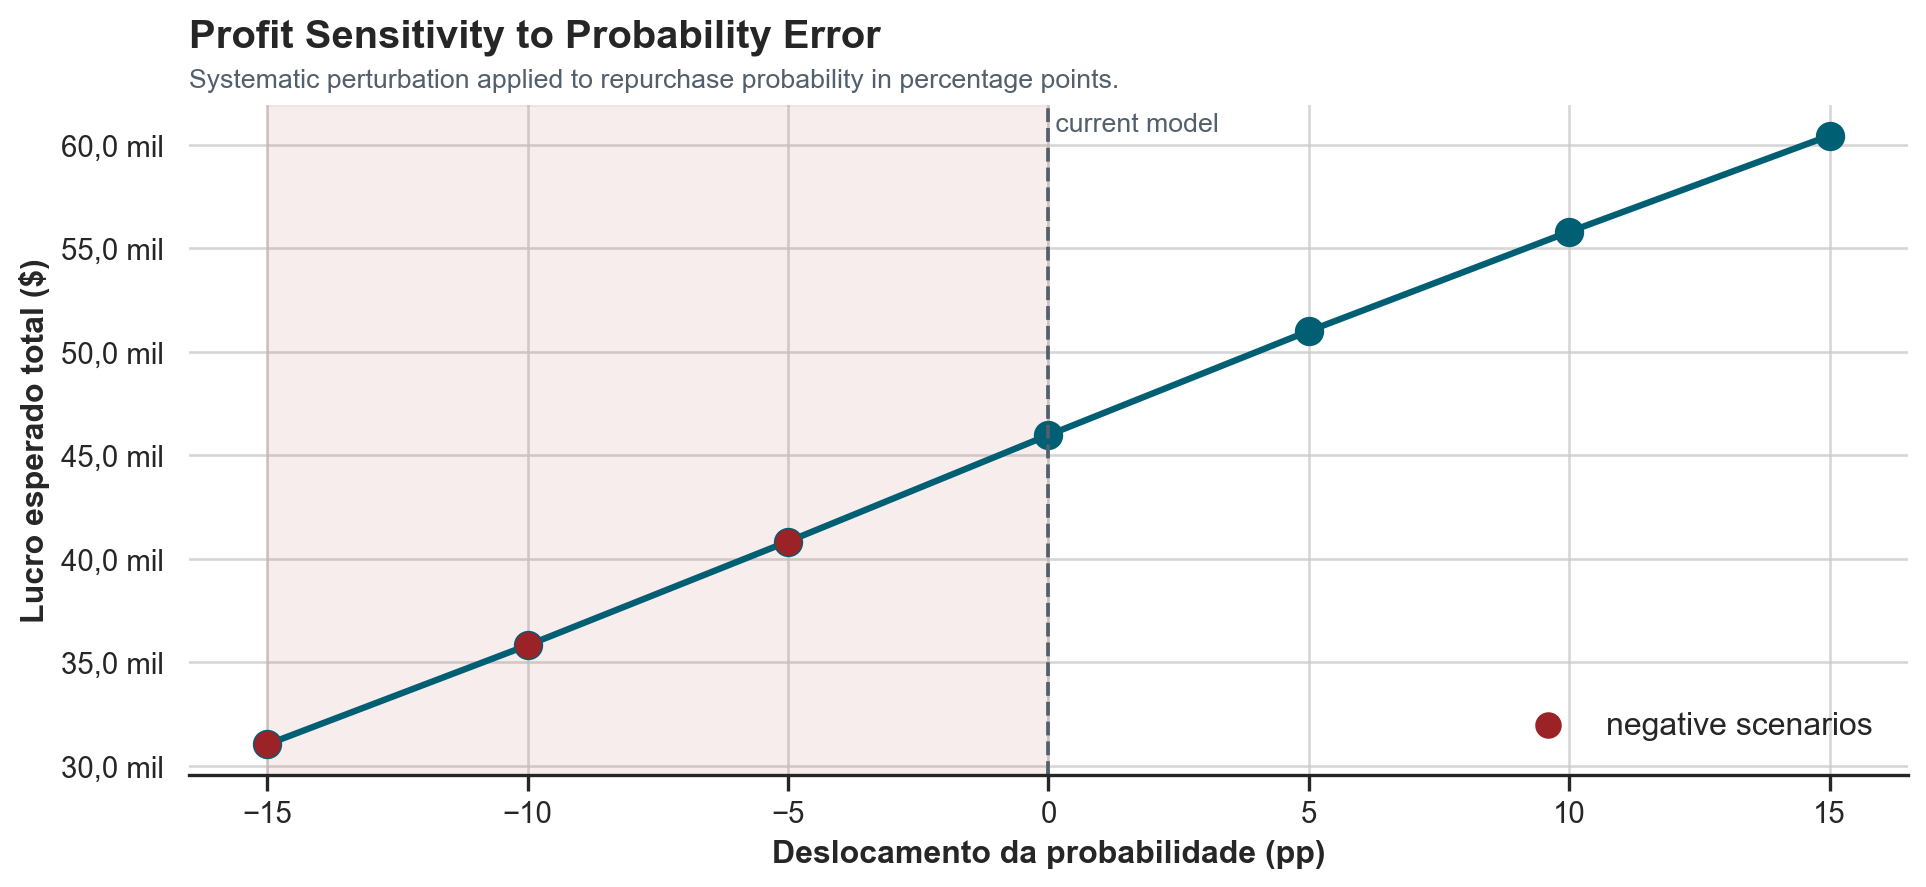

In [61]:
# INCREMENT 3: sensitivity analysis to model calibration error.
# Simulates the impact of systematically shifted probabilities on the financial outcome.

noise_levels = NOISE_LEVELS
# Interpretation: -0.10 means the real probabilities are 10pp lower than estimated.

sensitivity_rows = []
for noise in noise_levels:
    sim = prescriptive_margin_df.copy()
    sim["prob_perturbed"] = (sim["prob_repurchase_90d"] + noise).clip(0, 1)
    sim["expected_revenue_perturbed"] = (
        sim["prob_perturbed"] * sim["AverageTicket"] * MARGIN_RATE
    )
    sim["expected_profit_perturbed"] = (
        sim["expected_revenue_perturbed"] - sim["incentive_cost"]
    )
    total_profit = sim["expected_profit_perturbed"].sum()
    total_cost = sim["incentive_cost"].sum()
    sensitivity_rows.append({
        "Shift (pp)": int(noise * 100),
        "TotalExpectedProfit": total_profit,
        "TotalCost": total_cost,
        "ROI": total_profit / total_cost if total_cost > 0 else np.nan,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

display(sensitivity_df.round(2))

fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.plot(
    sensitivity_df["Shift (pp)"],
    sensitivity_df["TotalExpectedProfit"],
    marker="o",
    linewidth=2.4,
    color=PALETTE[0],
)
negative_sensitivity = sensitivity_df.loc[sensitivity_df["Shift (pp)"] < 0]
ax.scatter(
    negative_sensitivity["Shift (pp)"],
    negative_sensitivity["TotalExpectedProfit"],
    s=80,
    color=PALETTE[5],
    zorder=3,
    label="negative scenarios",
)
ax.axvspan(
    sensitivity_df["Shift (pp)"].min(),
    0,
    color=PALETTE[5],
    alpha=0.08,
)
ax.axvline(0, color="#52606D", linestyle="--", linewidth=1.4)
ax.text(
    0,
    sensitivity_df["TotalExpectedProfit"].max(),
    " current model",
    ha="left",
    va="bottom",
    fontsize=10,
    color="#52606D",
)
add_titles(
    ax,
    "Profit Sensitivity to Probability Error",
    "Systematic perturbation applied to repurchase probability in percentage points.",
)
ax.set_xlabel("Deslocamento da probabilidade (pp)")
ax.set_ylabel("Lucro esperado total ($)")
ax.grid(alpha=0.8)
set_compact_axis(ax, "y")
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## "Do Nothing" Decision: Business Maturity
</span>

Naive models send campaigns to everyone. Mature models know when
**not acting** is the best decision.

This section explicitly quantifies the customers for whom no incentive
generates a positive return, and how much budget is preserved by this decision. The
concentration of "do nothing" in low-value and highly inactive segments
is the most intuitive validation that the model is working correctly.

In an executive presentation, showing "we saved $ X by avoiding unnecessary incentives"
is just as powerful as "we generated $ Y with well-targeted campaigns".


,Group,Customers,PercentageOfBase,BudgetSaved,BudgetInvested,TotalIncrementalProfit
0,No incentive,48,6.05,240.00,0.00,0.00
1,With incentive,745,93.95,0.00,5647.00,20988.37


,PredictiveSegment,Customers,BudgetSaved
2,Low Value,27,135.00
1,Inactive Customers,18,90.00
0,Champions,3,15.00


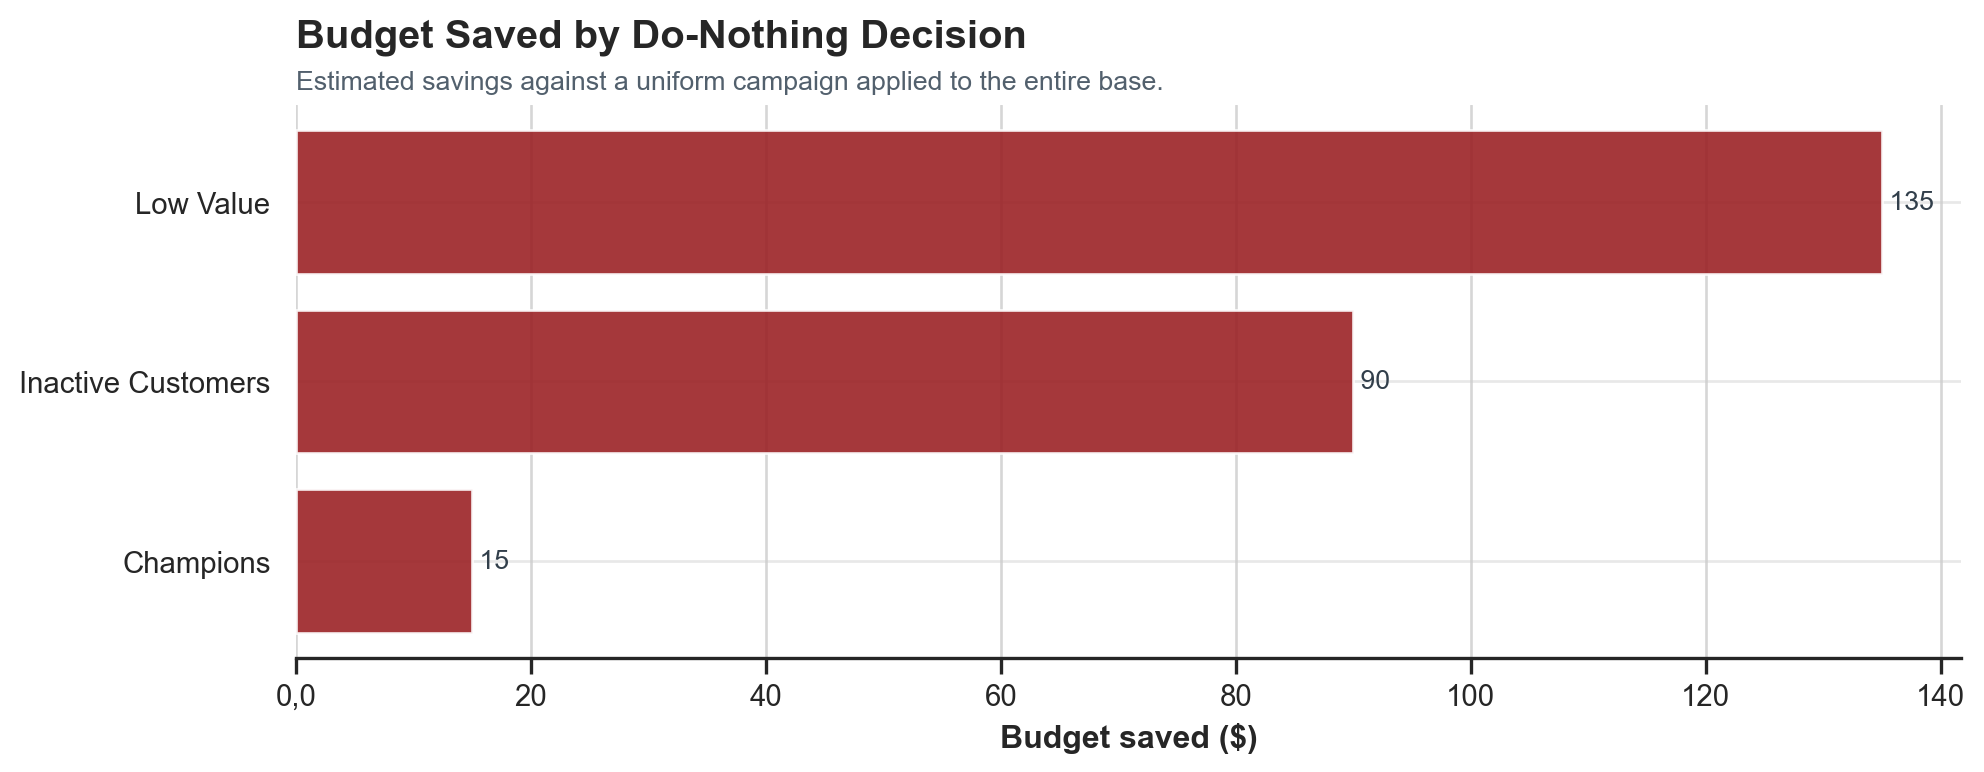

In [63]:
# INCREMENT 4: "do nothing" as an explicit and quantified decision.
# Show how many customers do not deserve an incentive and how much this saves.

no_action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] == "No Action")
    | (prescriptive_df["IncrementalProfit"] <= 0)
].copy()

action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action")
    & (prescriptive_df["IncrementalProfit"] > 0)
].copy()

# Savings measured against a naive policy of uniform campaign for the entire base.
no_action_clients["budget_avoided"] = UNIFORM_COST
action_clients["budget_avoided"] = 0.0

no_action_summary = pd.DataFrame({
    "Group": ["No incentive", "With incentive"],
    "Customers": [len(no_action_clients), len(action_clients)],
    "PercentageOfBase": [
        len(no_action_clients) / len(prescriptive_df) * 100,
        len(action_clients) / len(prescriptive_df) * 100,
    ],
    "BudgetSaved": [
        no_action_clients["budget_avoided"].sum(),
        action_clients["budget_avoided"].sum(),
    ],
    "BudgetInvested": [
        no_action_clients["incentive_cost"].sum(),
        action_clients["incentive_cost"].sum(),
    ],
    "TotalIncrementalProfit": [
        no_action_clients["IncrementalProfit"].sum(),
        action_clients["IncrementalProfit"].sum(),
    ],
})

# Distribution of "do nothing" customers by segment — where are they?
no_action_by_segment = (
    no_action_clients.groupby("PredictiveSegment", as_index=False)
    .agg(
        Customers=("Customer ID", "count"),
        BudgetSaved=("budget_avoided", "sum"),
    )
    .sort_values("Customers", ascending=False)
)

display(no_action_summary.round(2))
display(no_action_by_segment.round(2))

no_action_segment_plot = no_action_by_segment.sort_values("BudgetSaved")
fig_height = max(4.2, 0.42 * len(no_action_segment_plot) + 1.4)
fig, ax = plt.subplots(figsize=(10.5, fig_height))
ax.barh(
    no_action_segment_plot["PredictiveSegment"],
    no_action_segment_plot["BudgetSaved"],
    color=PALETTE[5],
    alpha=0.9,
)
add_titles(
    ax,
    "Budget Saved by Do-Nothing Decision",
    "Estimated savings against a uniform campaign applied to the entire base.",
)
ax.set_xlabel("Budget saved ($)")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
for idx, value in enumerate(no_action_segment_plot["BudgetSaved"]):
    ax.text(value, idx, f" {compact(value)}", va="center", fontsize=10, color="#323F4B")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Budget vs Incremental Profit Curve
</span>

This curve answers the question every CFO asks: *"What is the marginal return
of each additional dollar invested in campaigns?"*

The left chart shows the total accumulated incremental profit as the
budget grows. The right chart shows ROI — which starts high (customers
with higher returns are prioritized) and falls as customers with lower returns
are included.

The optimal investment point is where ROI starts to fall sharply. Investing
beyond that point still generates profit, but efficiency decreases. The dashed line
marks the current `BUDGET_TOTAL` — is it to the left or right of the optimal point?

This visualization transforms the notebook into a strategic planning tool:
the manager no longer needs to guess the right budget — they can read it from the chart.


,BudgetPercentile,Budget,IncrementalProfit,CustomersServed,ROI
0,25%,637.47,3127.29,65.00,4.91
1,50%,1274.94,4079.46,147.00,3.20
2,75%,1965.53,4641.84,284.00,2.36
3,100%,2603.00,4807.28,473.00,1.85


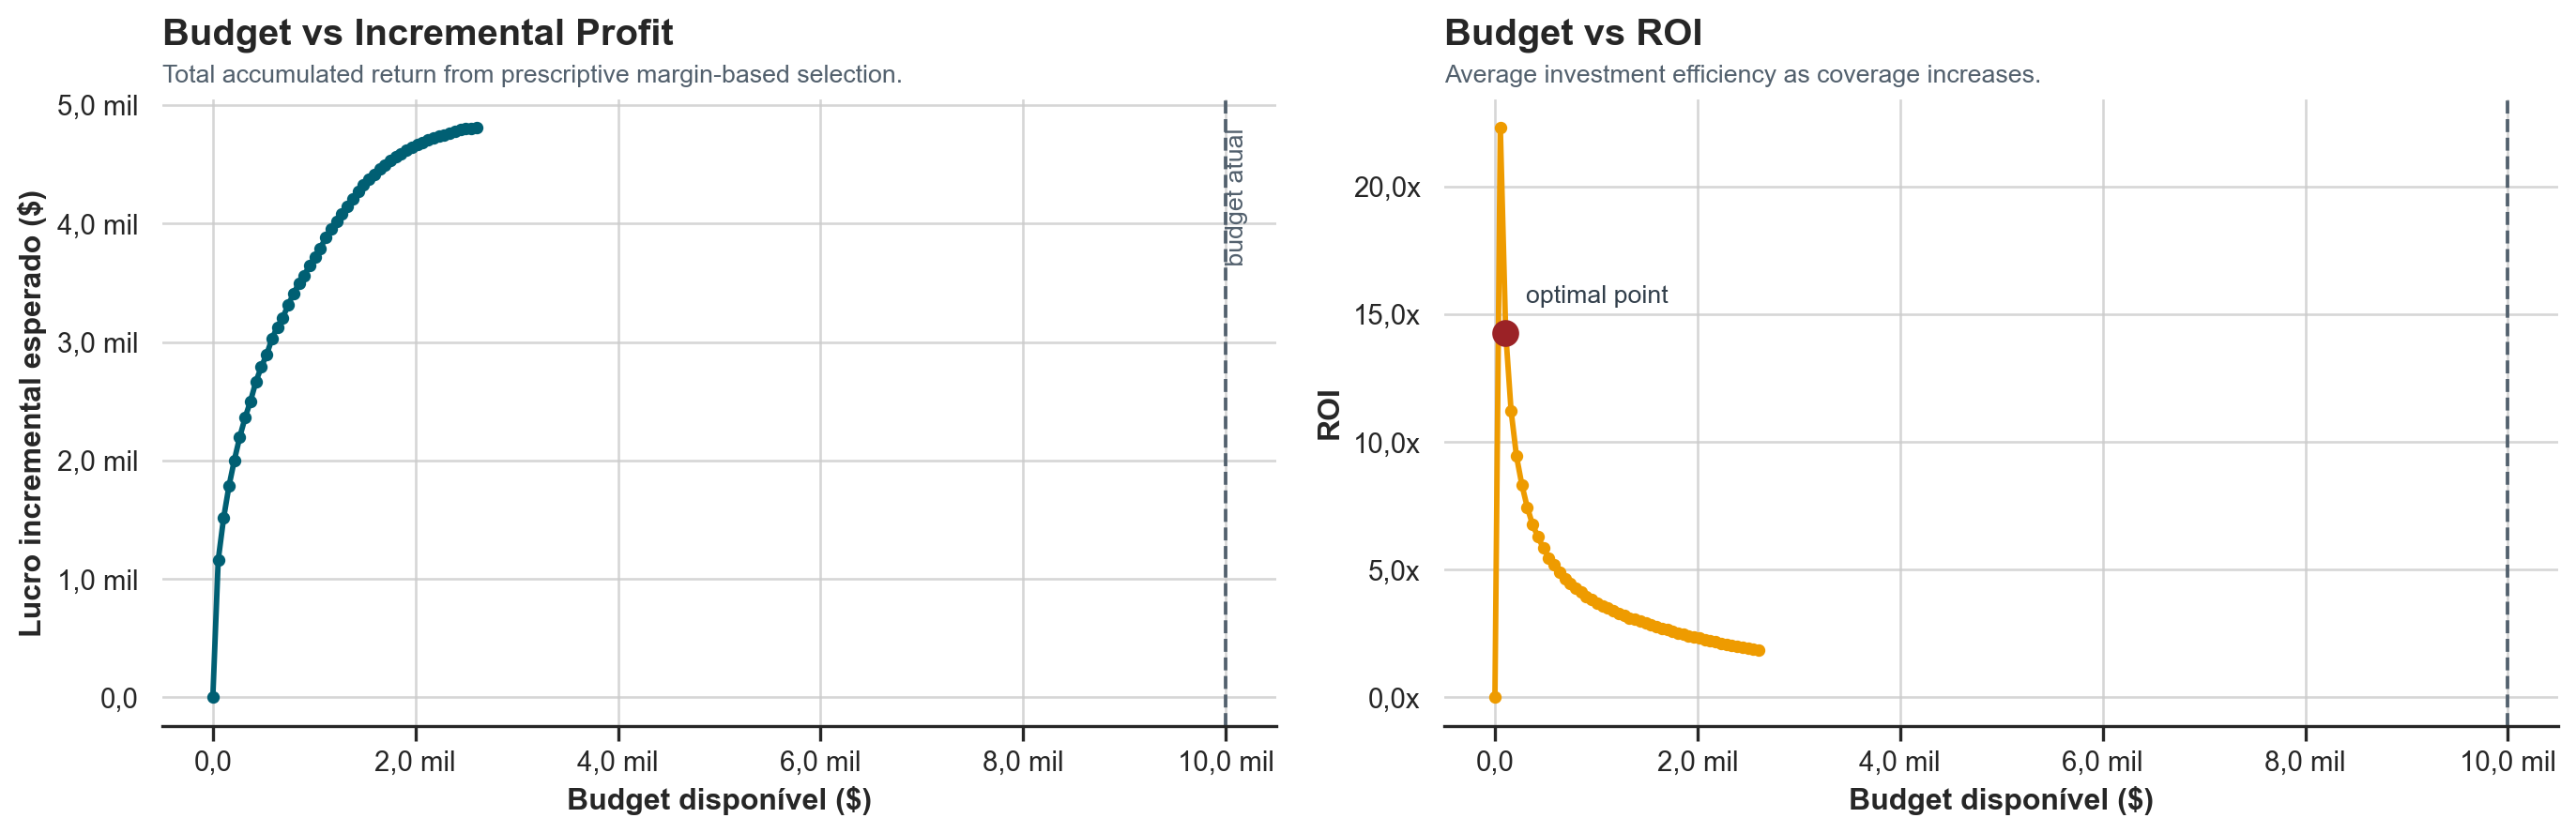

In [65]:
# INCREMENT 5: budget vs incremental profit curve — executive presentation.
# Shows the marginal return of each level of investment.

budget_candidates_curve = prescriptive_margin_df.loc[
    (prescriptive_margin_df["BestActionMargin"] != "No Action")
    & (prescriptive_margin_df["IncrementalMarginProfit"] > 0)
    & (prescriptive_margin_df["incentive_cost"] > 0)
].sort_values("IncrementalMarginProfit", ascending=False).copy()

# Sweep: from 0 to maximum possible budget, in parameterized points.
max_possible_budget = budget_candidates_curve["incentive_cost"].sum()
budget_points = np.linspace(0, max_possible_budget, BUDGET_CURVE_POINTS)

curve_rows = []
for b in budget_points:
    remaining = b
    selected_profit = 0.0
    selected_clients = 0
    selected_cost = 0.0
    for _, row in budget_candidates_curve.iterrows():
        if row["incentive_cost"] <= remaining:
            remaining -= row["incentive_cost"]
            selected_profit += row["IncrementalMarginProfit"]
            selected_cost += row["incentive_cost"]
            selected_clients += 1
    curve_rows.append({
        "Budget": b,
        "IncrementalProfit": selected_profit,
        "CustomersServed": selected_clients,
        "ActualCost": selected_cost,
        "ROI": selected_profit / selected_cost if selected_cost > 0 else 0,
    })

budget_curve_df = pd.DataFrame(curve_rows)

positive_curve = budget_curve_df.loc[budget_curve_df["ActualCost"] > 0].copy()
if positive_curve.empty:
    optimal_budget_point = budget_curve_df.iloc[[0]].copy()
else:
    positive_curve["ROI_Delta"] = positive_curve["ROI"].diff()
    if positive_curve["ROI_Delta"].notna().any():
        optimal_idx = positive_curve["ROI_Delta"].idxmin()
    else:
        optimal_idx = positive_curve["ROI"].idxmax()
    optimal_budget_point = budget_curve_df.loc[[optimal_idx]].copy()

breakpoint_rows = []
for percentile in [0.25, 0.50, 0.75, 1.00]:
    target_budget = max_possible_budget * percentile
    idx = (budget_curve_df["Budget"] - target_budget).abs().idxmin()
    row = budget_curve_df.loc[idx]
    breakpoint_rows.append({
        "BudgetPercentile": f"{int(percentile * 100)}%",
        "Budget": row["Budget"],
        "IncrementalProfit": row["IncrementalProfit"],
        "CustomersServed": row["CustomersServed"],
        "ROI": row["ROI"],
    })

budget_breakpoints = pd.DataFrame(breakpoint_rows)

display(budget_breakpoints.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

axes[0].plot(
    budget_curve_df["Budget"],
    budget_curve_df["IncrementalProfit"],
    marker="o",
    markersize=4,
    linewidth=2.2,
    color=PALETTE[0],
)
axes[0].axvline(BUDGET_TOTAL, color="#52606D", linestyle="--", linewidth=1.4)
axes[0].text(
    BUDGET_TOTAL,
    budget_curve_df["IncrementalProfit"].max(),
    " budget atual",
    rotation=90,
    va="top",
    ha="left",
    fontsize=10,
    color="#52606D",
)
add_titles(
    axes[0],
    "Budget vs Incremental Profit",
    "Total accumulated return from prescriptive margin-based selection.",
)
axes[0].set_xlabel("Budget disponível ($)")
axes[0].set_ylabel("Lucro incremental esperado ($)")
axes[0].grid(alpha=0.8)
set_compact_axis(axes[0], "x")
set_compact_axis(axes[0], "y")

axes[1].plot(
    budget_curve_df["Budget"],
    budget_curve_df["ROI"],
    marker="o",
    markersize=4,
    linewidth=2.2,
    color=PALETTE[3],
)
axes[1].axvline(BUDGET_TOTAL, color="#52606D", linestyle="--", linewidth=1.4)
if not optimal_budget_point.empty:
    opt = optimal_budget_point.iloc[0]
    axes[1].scatter(
        opt["Budget"],
        opt["ROI"],
        s=95,
        color=PALETTE[5],
        zorder=3,
    )
    axes[1].annotate(
        "optimal point",
        xy=(opt["Budget"], opt["ROI"]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=10,
        color="#323F4B",
    )
add_titles(
    axes[1],
    "Budget vs ROI",
    "Average investment efficiency as coverage increases.",
)
axes[1].set_xlabel("Budget disponível ($)")
axes[1].set_ylabel("ROI")
axes[1].grid(alpha=0.8)
set_compact_axis(axes[1], "x")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{fmt(value, 1)}x")
)

plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Implemented Improvements
</span>


- **Problem 1:** `PredictiveCluster` is now generated inside the `Pipeline`, with `KMeans.fit()` only on training and `predict()` for validation and hold-out.
- **Problem 2:** an independent 15% hold-out was created, and the financial simulation uses probabilities generated from data not seen by the model.
- **Problem 3:** uplift is no longer uniform and now varies by segment and incentive type.
- **Problem 4:** probabilities were calibrated with `CalibratedClassifierCV` and evaluated with a reliability diagram and Brier Score.
- **Problem 5:** a budget allocation with budget constraint and estimated ROI by segment was added.
- **Problem 6:** automatic segment naming now has sanity validations with `warnings.warn`.
- **Problem 7:** main functions received type hints and docstrings, `AverageTicket` was protected against division by zero and `best_k` was explicitly documented.
- **P1:** Index reset before splits; `check_is_fitted` in the transformer; alignment assertion.
- **P2:** Hold-out scope documented in budget simulation with production context.
- **P3:** Operational CSV export with `priority_rank` for direct use in CRM.
- **P4:** Operational parameters centralized in a single configuration cell.
- **I1:** profit function recalculated with `MARGIN_RATE`, comparing actions optimized by revenue versus margin.
- **I2:** executive scenario analysis compares no action, uniform campaign and individual prescription.
- **I3:** financial sensitivity simulates probability shifts from -15pp to +15pp.
- **I4:** `No Action` decision was quantified as budget savings against a uniform campaign.
- **I5:** budget curve shows incremental profit, ROI and executive investment breakpoints.


<span style="color:steelblue; text-align: left">

## Operational Export to CRM
</span>

The `crm_next_best_action.csv` file consolidates, for each hold-out customer,
the segment, the recommended action, the expected profit and the executive description of the
Next Best Action. The `priority_rank` column globally ranks customers by
incremental profit — rank 1 is the customer that generates the most return if they receive an incentive.

The file is ready for direct import into CRM tools, email marketing automation
or service queue prioritization.


In [69]:
## Operational Export to CRM

# FIX P3: transforms the notebook into a directly actionable CRM tool.
crm_export_cols = {
    "Customer ID": "customer_id",
    "SegmentName": "segment_name",
    "Recency": "recency_days",
    "Frequency": "frequency",
    "Monetary": "monetary_total",
    "AverageTicket": "average_ticket",
    "prob_repurchase_90d": "prob_repurchase_90d",
    "BestAction": "best_action_code",
    "RecommendedAction": "recommended_campaign",
    "ExpectedProfit": "expected_profit",
    "ExpectedProfit_NoAction": "expected_profit_no_action",
    "IncrementalProfit": "incremental_profit",
    "PrescriptiveNextBestAction": "crm_action_description",
}

crm_prescription_cols = [
    "Customer ID",
    "BestAction",
    "RecommendedAction",
    "ExpectedProfit",
    "ExpectedProfit_NoAction",
    "IncrementalProfit",
    "PrescriptiveNextBestAction",
]

# Base: all customers with available prescription (hold-out).
crm_base = rfm.drop(
    columns=[col for col in crm_prescription_cols if col != "Customer ID"],
    errors="ignore",
).merge(
    prescriptive_df[crm_prescription_cols],
    on="Customer ID",
    how="inner",
)

crm_output = (
    crm_base[list(crm_export_cols.keys())]
    .rename(columns=crm_export_cols)
    .sort_values(
        ["segment_name", "incremental_profit"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# Add service priority column: global rank by incremental_profit.
crm_output["priority_rank"] = crm_output["incremental_profit"].rank(
    ascending=False,
    method="first",
).astype(int)

output_path = EXPORT_PATH
crm_output.to_csv(output_path, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(f"Export generated: {output_path}")
print(f"Customers exported: {fmt(len(crm_output))}")
print(f"Segments covered: {crm_output['segment_name'].nunique()}")
display(crm_output.head(10))
display(
    crm_output.groupby("segment_name", as_index=False).agg(
        Customers=("customer_id", "count"),
        TotalIncrementalProfit=("incremental_profit", "sum"),
        MinPriority=("priority_rank", "min"),
        MaxPriority=("priority_rank", "max"),
    ).sort_values("TotalIncrementalProfit", ascending=False)
)


Export generated: crm_next_best_action.csv
Customers exported: 793
Segments covered: 6


,customer_id,segment_name,recency_days,frequency,monetary_total,average_ticket,prob_repurchase_90d,best_action_code,recommended_campaign,expected_profit,expected_profit_no_action,incremental_profit,crm_action_description,priority_rank
0,12477,Champions,23,9,20276.37,2252.93,0.83,High Incentive,Aggressive campaign,2332.63,2210.21,122.42,Maximum retention priority with aggressive campaign.,24
1,13329,Champions,32,8,5112.97,639.12,0.36,High Incentive,Aggressive campaign,326.27,237.10,89.18,Maximum retention priority with aggressive campaign.,45
2,18287,Champions,43,7,4182.99,597.57,0.56,High Incentive,Aggressive campaign,432.72,349.39,83.33,Maximum retention priority with aggressive campaign.,51
3,14936,Champions,34,12,12410.81,1034.23,0.78,High Incentive,Aggressive campaign,1093.62,1036.86,56.76,Maximum retention priority with aggressive campaign.,87
4,17511,Champions,3,60,175603.55,2926.73,0.98,Low Incentive,Light campaign,2876.34,2821.45,54.89,Prioritize relationship with light campaign.,91
5,13373,Champions,61,6,7587.19,1264.53,0.81,High Incentive,Aggressive campaign,1076.23,1022.92,53.31,Maximum retention priority with aggressive campaign.,95
6,16705,Champions,1,42,43515.05,1036.07,0.95,High Incentive,Aggressive campaign,1216.89,1165.61,51.28,Maximum retention priority with aggressive campaign.,102
7,16303,Champions,26,7,7928.27,1132.61,0.74,High Incentive,Aggressive campaign,859.04,814.00,45.03,Maximum retention priority with aggressive campaign.,112
8,16652,Champions,59,16,17550.39,1096.90,0.85,High Incentive,Aggressive campaign,968.78,924.13,44.65,Maximum retention priority with aggressive campaign.,115
9,13815,Champions,22,8,7475.74,934.47,0.81,High Incentive,Aggressive campaign,912.61,869.05,43.55,Maximum retention priority with aggressive campaign.,117


,segment_name,Customers,TotalIncrementalProfit,MinPriority,MaxPriority
1,High Value at Risk,84,10283.94,1,643
4,Loyal Customers,214,4383.02,12,788
0,Champions,124,2238.11,24,748
5,Occasional Buyers,123,2116.97,27,793
2,Inactive Customers,178,1839.77,32,762
3,Low Value,70,126.56,352,787


<span style="color:steelblue; text-align: left">

## Conclusion
</span>

This project evolved from a traditional customer segmentation analysis into a more advanced prescriptive analytics framework, capable of supporting data-driven marketing decisions.

Initially, the analysis focused on understanding customer purchase behavior through RFM metrics and K-Means clustering, enabling the identification of different customer profiles with distinct behavioral characteristics and commercial values. Although segmentation alone already provides relevant strategic insights, the project was expanded beyond descriptive analysis by incorporating a supervised prediction layer based on future repurchase probability.

Using a temporal validation approach, the model estimated the probability of repurchase within a future horizon, reducing the risk of data leakage and creating a scenario closer to business reality. This predictive layer transformed the project from a static segmentation exercise into a future-oriented analytical pipeline, capable of estimating future customer behavior.

Subsequently, the project was elevated to a prescriptive analytics perspective inspired by the framework proposed by Bertsimas and Kallus in *From Predictive to Prescriptive Analytics*. Instead of merely predicting outcomes, the notebook began simulating possible marketing actions and estimating their expected economic impacts through expected profit calculations.

By combining:

* customer behavioral variables,
* repurchase probability,
* simulated marketing incentives,
* expected revenue,
* campaign costs,
* and budget constraints,

the pipeline became capable of recommending the most economically advantageous action for each customer or segment.

One of the main contributions of the project is the transition from:

* "What is likely to happen?"
  to:
* "What decision should be made?"

This distinction represents the key difference between predictive and prescriptive analytics.

Additionally, the notebook incorporates a practical business-oriented layer through:

* ROI-based prioritization,
* budget allocation under constraint,
* and file exports prepared for integration with CRM and operational campaigns.

In this way, the project does not end at customer clustering. On the contrary, it demonstrates how Machine Learning techniques can support real decision-making processes by integrating prediction, simulation, optimization and action recommendation into a unified analytical workflow.

Although the uplift values used in the simulations are heuristic hypotheses and not real causal estimates, the framework built establishes a solid foundation for future developments involving:

* A/B testing,
* uplift modeling,
* causal inference,
* reinforcement learning,
* and optimization under uncertainty.

Overall, the project demonstrates how customer analytics can evolve from descriptive reports to actionable decision intelligence, capable of supporting strategic and operational marketing initiatives driven by expected economic value.


<span style="color:steelblue; text-align: left">

## References
</span>

- **[Bertsimas and Kallus, 2019]** Bertsimas, D., and Kallus, N. (2019). *From Predictive to Prescriptive Analytics*. Management Science. https://doi.org/10.1287/mnsc.2018.3253
- **[Chen, 2012]** Chen, D. (2012). *Online Retail II* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D
- **[Chen, Sain and Guo, 2012]** Chen, D., Sain, S. L., and Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19, 197-208. https://doi.org/10.1057/dbm.2012.17
- **[Fader, Hardie and Lee, 2005]** Fader, P. S., Hardie, B. G. S., and Lee, K. L. (2005). *RFM and CLV: Using Iso-Value Curves for Customer Base Analysis*. Journal of Marketing Research, 42(4), 415-430. https://doi.org/10.1509/jmkr.2005.42.4.415
- **[Hastie, Tibshirani and Friedman, 2009]** Hastie, T., Tibshirani, R., and Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
- **[Imbens and Rubin, 2015]** Imbens, G. W., and Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences: An Introduction*. Cambridge University Press. https://doi.org/10.1017/CBO9781139025751
- **[Jain, 2010]** Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651-666. https://doi.org/10.1016/j.patrec.2009.09.011
- **[Kuhn and Johnson, 2013]** Kuhn, M., and Johnson, K. (2013). *Applied Predictive Modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- **[Lloyd, 1982]** Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137. https://doi.org/10.1109/TIT.1982.1056489
- **[MacQueen, 1967]** MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1, 281-297. https://projecteuclid.org/euclid.bsmsp/1200512992
- **[Rousseeuw, 1987]** Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7
- **[Rust and Verhoef, 2005]** Rust, R. T., and Verhoef, P. C. (2005). *Optimizing the Marketing Interventions Mix in Intermediate-Term CRM*. Marketing Science, 24(3), 477-489. https://doi.org/10.1287/mksc.1040.0107
- **[Tukey, 1977]** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. https://openlibrary.org/works/OL9572429W/Exploratory_data_analysis
- **[Wedel and Kamakura, 2000]** Wedel, M., and Kamakura, W. A. (2000). *Market Segmentation: Conceptual and Methodological Foundations* (2nd ed.). Springer. https://doi.org/10.1007/978-1-4615-4651-1
